In [ ]:
# Point directly to your file
INPUT_PATH = "Thesis_Survey_2025.csv"   # exact name in your Jupyter working folder

import os, pandas as pd

if not os.path.exists(INPUT_PATH):
    # helpful check if you're in the wrong folder
    import glob
    print("File not found. Here are CSVs I can see:", glob.glob("*.csv"))
    raise FileNotFoundError(f"Could not find {INPUT_PATH}. Put it in this folder or give full path.")

# Load
df_raw = pd.read_csv(INPUT_PATH, encoding="utf-8")   # if you see weird characters, try encoding="utf-8-sig"
print("Loaded shape:", df_raw.shape)
print("Columns:", list(df_raw.columns)[:15], "…")


Loaded shape: (268, 25)
Columns: ['Timestamp', '  Consent  ', 'Country ', 'State/Region  → region', 'Age  → age_band', 'Gender → gender', 'Occupation (broad)  → occupation', 'Urbanicity → urbanicity', 'In the last 7 days, did you experience any of the following? ', '  Did you experience any of the above symptoms?  ', '  Symptom onset date  ', 'Symptom severity', '  In the last 7 days, did you take a COVID-19 or flu test?  ', '  Did you seek medical care for these symptoms?   ', '  Did you self-medicate?   '] …


In [ ]:
# 0.1) SETUP & COLUMN MAPPING
import os, re, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

OUTDIR = "thesis_outputs_stepwise"
os.makedirs(OUTDIR, exist_ok=True)

# working copy with neat headers
df = df_raw.copy()
df.columns = [re.sub(r"\s+", " ", c).strip().lower() for c in df.columns]

def find_col(cands):
    for cand in cands:
        for c in df.columns:
            if cand in c:
                return c
    return None

# map your questionnaire columns (fuzzy)
col_timestamp   = find_col(["timestamp"])
col_country     = find_col(["country"])
col_region      = find_col(["state/region", "region"])
col_age         = find_col(["age"])
col_gender      = find_col(["gender"])
col_occupation  = find_col(["occupation"])
col_urban       = find_col(["urbanicity"])

col_symptoms    = find_col(["in the last 7 days, did you experience any of the following"])
col_symptom_yN  = find_col(["did you experience any of the above symptoms"])
col_onset       = find_col(["symptom onset date"])
col_severity    = find_col(["symptom severity"])

col_test        = find_col(["did you take a covid-19 or flu test"])
col_care        = find_col(["did you seek medical care"])
col_selfmed     = find_col(["did you self-medicate"])

col_search_fever= find_col(["how often did you search online for information about “fever”","fever”","fever\""])
col_search_cough= find_col(["how often did you search online for “cough”","cough”","cough\""])
col_search_loss = find_col(["how often did you search online for “loss of taste/smell”","loss of taste/smell”","loss of taste/smell\""])
col_platform    = find_col(["which platform did you mostly use"])

col_hours_out   = find_col(["how many hours per day did you spend outside"])
col_crowded     = find_col(["did you visit any of these crowded places"])
col_mask        = find_col(["how often did you wear a mask indoors"])

col_vax         = find_col(["covid-19 vaccination status","vaccination status"])
col_flu_shot    = find_col(["did you receive a flu shot"])
col_recent_covid= find_col(["have you had a covid-19 infection"])

print("Mapped columns:\n", {
    "timestamp": col_timestamp, "country": col_country, "region": col_region,
    "age": col_age, "gender": col_gender, "occupation": col_occupation, "urban": col_urban,
    "symptom_multi": col_symptoms, "symptom_yesno": col_symptom_yN, "onset": col_onset, "severity": col_severity,
    "test": col_test, "care": col_care, "selfmed": col_selfmed,
    "search_fever": col_search_fever, "search_cough": col_search_cough, "search_loss": col_search_loss, "platform": col_platform,
    "hours_out": col_hours_out, "crowded": col_crowded, "mask": col_mask,
    "vax": col_vax, "flu_shot": col_flu_shot, "recent_covid": col_recent_covid
})


Mapped columns:
 {'timestamp': 'timestamp', 'country': 'country', 'region': 'state/region → region', 'age': 'age → age_band', 'gender': 'gender → gender', 'occupation': 'occupation (broad) → occupation', 'urban': 'urbanicity → urbanicity', 'symptom_multi': 'in the last 7 days, did you experience any of the following?', 'symptom_yesno': 'did you experience any of the above symptoms?', 'onset': 'symptom onset date', 'severity': 'symptom severity', 'test': 'in the last 7 days, did you take a covid-19 or flu test?', 'care': 'did you seek medical care for these symptoms?', 'selfmed': 'did you self-medicate?', 'search_fever': 'how often did you search online for information about “fever”?', 'search_cough': 'how often did you search online for “cough”?', 'search_loss': 'how often did you search online for “loss of taste/smell”?', 'platform': 'which platform did you mostly use for these searches?', 'hours_out': 'on average, how many hours per day did you spend outside your home?', 'crowded': '

In [ ]:
import io

# info for screenshots
with open(os.path.join(OUTDIR, "01_data_info.txt"), "w", encoding="utf-8") as f:
    f.write("Shape: %s\n" % (df.shape,))
    f.write("\nColumns:\n%s\n" % list(df.columns))
    f.write("\nHEAD(5):\n%s\n" % df.head(5).to_string())

    buf = io.StringIO()
    df.info(buf=buf)
    f.write("\nINFO():\n" + buf.getvalue())

print("Saved: thesis_outputs_stepwise/01_data_info.txt")
display(df.head(3))


Saved: thesis_outputs_stepwise/01_data_info.txt


,timestamp,consent,country,state/region → region,age → age_band,gender → gender,occupation (broad) → occupation,urbanicity → urbanicity,"in the last 7 days, did you experience any of the following?",did you experience any of the above symptoms?,...,how often did you search online for information about “fever”?,how often did you search online for “cough”?,how often did you search online for “loss of taste/smell”?,which platform did you mostly use for these searches?,"on average, how many hours per day did you spend outside your home?","in the last 7 days, did you visit any of these crowded places?",how often did you wear a mask indoors?,covid-19 vaccination status,did you receive a flu shot in the last 12 months?,have you had a covid-19 infection in the last 6 months?
0,2025/08/26 02:04:06 PM GMT+3,I agree to participate,Germany,Hamburg,45–54,Female,Employed,Suburban,Cough,Yes,...,1.0,3.0,2.0,Google,1–3 hours,Public transport,2.0,Primary series only,Yes,No
1,2025/08/27 02:04:06 PM GMT+3,I agree to participate,Germany,Hamburg,45–54,Male,Homemaker,Urban,Shortness of breath,Yes,...,2.0,4.0,0.0,Social media,1–3 hours,Healthcare facility,4.0,Prefer not to say,No,No
2,2025/08/28 02:04:06 PM GMT+3,I agree to participate,India,Tamil Nadu,55–64,Female,Student,Suburban,Sore throat,Yes,...,1.0,2.0,3.0,Social media,<1 hour,None of the above,4.0,Not vaccinated,Yes,Yes


In [ ]:
import pandas as pd, os

INPUT_PATH = "Thesis_Survey_2025.csv"
OUTDIR = "thesis_outputs_stepwise"
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(INPUT_PATH, encoding="utf-8")
print("Loaded shape:", df.shape)
print("Columns:", df.columns[:10].tolist(), "...")


Loaded shape: (268, 25)
Columns: ['Timestamp', '  Consent  ', 'Country ', 'State/Region  → region', 'Age  → age_band', 'Gender → gender', 'Occupation (broad)  → occupation', 'Urbanicity → urbanicity', 'In the last 7 days, did you experience any of the following? ', '  Did you experience any of the above symptoms?  '] ...


In [ ]:
import io

with open(os.path.join(OUTDIR, "01_data_info.txt"), "w", encoding="utf-8") as f:
    f.write("Shape: %s\n" % (df.shape,))
    f.write("\nColumns:\n%s\n" % list(df.columns))
    f.write("\nHEAD(5):\n%s\n" % df.head(5).to_string())

    # capture .info()
    buf = io.StringIO()
    df.info(buf=buf)
    f.write("\nINFO():\n" + buf.getvalue())

    # add describe for numeric variables
    f.write("\nDESCRIBE():\n%s\n" % df.describe(include="all").to_string())

print("Saved: thesis_outputs_stepwise/01_data_info.txt")
display(df.head(3))


Saved: thesis_outputs_stepwise/01_data_info.txt


,Timestamp,Consent,Country,State/Region → region,Age → age_band,Gender → gender,Occupation (broad) → occupation,Urbanicity → urbanicity,"In the last 7 days, did you experience any of the following?",Did you experience any of the above symptoms?,...,How often did you search online for information about “fever”?,How often did you search online for “cough”?,How often did you search online for “loss of taste/smell”?,Which platform did you mostly use for these searches?,"On average, how many hours per day did you spend outside your home?","In the last 7 days, did you visit any of these crowded places?",How often did you wear a mask indoors?,COVID-19 vaccination status,Did you receive a flu shot in the last 12 months?,Have you had a COVID-19 infection in the last 6 months?
0,2025/08/26 02:04:06 PM GMT+3,I agree to participate,Germany,Hamburg,45–54,Female,Employed,Suburban,Cough,Yes,...,1.0,3.0,2.0,Google,1–3 hours,Public transport,2.0,Primary series only,Yes,No
1,2025/08/27 02:04:06 PM GMT+3,I agree to participate,Germany,Hamburg,45–54,Male,Homemaker,Urban,Shortness of breath,Yes,...,2.0,4.0,0.0,Social media,1–3 hours,Healthcare facility,4.0,Prefer not to say,No,No
2,2025/08/28 02:04:06 PM GMT+3,I agree to participate,India,Tamil Nadu,55–64,Female,Student,Suburban,Sore throat,Yes,...,1.0,2.0,3.0,Social media,<1 hour,None of the above,4.0,Not vaccinated,Yes,Yes


In [ ]:
# ----------------------
# Step 3: Cleaning & Recoding
# ----------------------

df_clean = df.copy()

# Standardize column names (remove spaces, lowercase)
df_clean.columns = (
    df_clean.columns.str.strip()
    .str.lower()
    .str.replace(r"[^0-9a-zA-Z]+", "_", regex=True)
)

# Example recodes:
# Yes/No → 1/0
yn_cols = [
    "did_you_experience_any_of_the_above_symptoms",
    "did_you_take_a_covid_19_or_flu_test",
    "did_you_seek_medical_care_for_these_symptoms",
    "did_you_self_medicate",
]
for col in yn_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].str.strip().str.lower().map({
            "yes": 1, "no": 0, "no, none of the above": 0,
            "yes — positive": 1, "yes — negative": 0
        })

# Symptom severity Likert scale → numeric
if "symptom_severity" in df_clean.columns:
    df_clean["symptom_severity"] = pd.to_numeric(df_clean["symptom_severity"], errors="coerce")

# Online search frequency (already numeric-like, but ensure int)
search_cols = [c for c in df_clean.columns if "search_online_for" in c]
for col in search_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").fillna(0).astype(int)

# Gender → dummy variables
if "gender" in df_clean.columns:
    df_clean = pd.get_dummies(df_clean, columns=["gender"], drop_first=True)

# Save cleaned version
clean_path = os.path.join(OUTDIR, "02_cleaned_data.csv")
df_clean.to_csv(clean_path, index=False)

print("Saved cleaned dataset:", clean_path)
display(df_clean.head(3))


Saved cleaned dataset: thesis_outputs_stepwise\02_cleaned_data.csv


,timestamp,consent,country,state_region_region,age_age_band,gender_gender,occupation_broad_occupation,urbanicity_urbanicity,in_the_last_7_days_did_you_experience_any_of_the_following_,did_you_experience_any_of_the_above_symptoms_,...,how_often_did_you_search_online_for_information_about_fever_,how_often_did_you_search_online_for_cough_,how_often_did_you_search_online_for_loss_of_taste_smell_,which_platform_did_you_mostly_use_for_these_searches_,on_average_how_many_hours_per_day_did_you_spend_outside_your_home_,in_the_last_7_days_did_you_visit_any_of_these_crowded_places_,how_often_did_you_wear_a_mask_indoors_,covid_19_vaccination_status,did_you_receive_a_flu_shot_in_the_last_12_months_,have_you_had_a_covid_19_infection_in_the_last_6_months_
0,2025/08/26 02:04:06 PM GMT+3,I agree to participate,Germany,Hamburg,45–54,Female,Employed,Suburban,Cough,Yes,...,1,3,2,Google,1–3 hours,Public transport,2.0,Primary series only,Yes,No
1,2025/08/27 02:04:06 PM GMT+3,I agree to participate,Germany,Hamburg,45–54,Male,Homemaker,Urban,Shortness of breath,Yes,...,2,4,0,Social media,1–3 hours,Healthcare facility,4.0,Prefer not to say,No,No
2,2025/08/28 02:04:06 PM GMT+3,I agree to participate,India,Tamil Nadu,55–64,Female,Student,Suburban,Sore throat,Yes,...,1,2,3,Social media,<1 hour,None of the above,4.0,Not vaccinated,Yes,Yes


In [ ]:
# --- Gender plot (robust) ---
# Case A: you still have a single categorical 'gender' column
cat_gender = next((c for c in df_clean.columns if c == "gender" or c.endswith("_gender")), None)
if cat_gender and df_clean[cat_gender].dtype == "object":
    # plot value counts of the original categorical column
    vc = df_clean[cat_gender].astype(str).str.strip().value_counts(dropna=False)
    plt.figure(figsize=(8,4)); vc.sort_values().plot(kind="barh")
    plt.title("Gender"); plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "04_gender.png"), dpi=200); plt.close()

else:
    # Case B: you have dummy columns like gender_female, gender_male, ...
    gcols = [c for c in df_clean.columns if c.startswith("gender_")]
    if gcols:
        # ensure numeric before summing
        gmat = df_clean[gcols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
        vc = gmat.sum().sort_values()
        plt.figure(figsize=(8,4)); vc.plot(kind="barh")
        plt.title("Gender (dummies)"); plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, "04_gender_dummies.png"), dpi=200); plt.close()


In [ ]:
# ================================
# STEP 4 — Descriptives & Visuals
# ================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs(OUTDIR, exist_ok=True)

# ---- Helper: safe column picker by prefix/substring ----
def pick_col_contains(df, *subs):
    """Return the first column whose name contains ALL substrings in `subs` (case-insensitive)."""
    subs = [s.lower() for s in subs]
    for c in df.columns:
        lc = c.lower()
        if all(s in lc for s in subs):
            return c
    return None

# ---- Identify commonly used columns (best-effort) ----
col_country = pick_col_contains(df_clean, "country")
col_age     = pick_col_contains(df_clean, "age")
# If you still have a single categorical gender col, we'll use it; else we'll use gender_* dummies below
col_gender_cat = "gender" if "gender" in df_clean.columns else pick_col_contains(df_clean, "_gender")

# If you have a vax status column
col_vax = None
for k in ["covid_19_vaccination_status", "vaccination_status"]:
    c = pick_col_contains(df_clean, k)
    if c:
        col_vax = c
        break

# ---- Build/confirm any_symptom ----
sym_cols = [c for c in df_clean.columns if c.startswith("sym_") and c != "sym_none"]
if sym_cols:
    df_clean["any_symptom"] = (df_clean[sym_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1) > 0).astype(int)
elif "did_you_experience_any_of_the_above_symptoms" in df_clean.columns:
    df_clean["any_symptom"] = pd.to_numeric(df_clean["did_you_experience_any_of_the_above_symptoms"], errors="coerce").fillna(0).astype(int)
else:
    # fallback: create zero vector so the rest of code still runs
    df_clean["any_symptom"] = 0

# ---- Numeric summary table ----
numeric_cols = df_clean.select_dtypes(include=["number"]).columns
desc = df_clean[numeric_cols].describe().T
desc.to_csv(os.path.join(OUTDIR, "04_descriptives_numeric.csv"))
display(desc.head(12))

# ---- Frequency plot helper ----
def barh_counts(series, title, fname):
    vc = series.astype("string").fillna("NA").value_counts(dropna=False)
    plt.figure(figsize=(8,4))
    vc.sort_values().plot(kind="barh")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, fname), dpi=200)
    plt.close()
    return vc

# ---- Country / Age / Vaccination frequencies (if present) ----
if col_country: barh_counts(df_clean[col_country], "Country", "04_country.png")
if col_age:     barh_counts(df_clean[col_age], "Age band", "04_age_band.png")
if col_vax:     barh_counts(df_clean[col_vax], "COVID-19 vaccination status", "04_vax.png")

# ---- Gender: robust handling for either categorical or dummies ----
# Case A: a single categorical 'gender' column exists
if col_gender_cat and df_clean[col_gender_cat].dtype == "object":
    barh_counts(df_clean[col_gender_cat], "Gender", "04_gender.png")
else:
    # Case B: dummies like gender_female, gender_male, etc.
    gcols = [c for c in df_clean.columns if c.lower().startswith("gender_")]
    if gcols:
        gmat = df_clean[gcols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
        vc = gmat.sum().sort_values()
        plt.figure(figsize=(8,4))
        vc.plot(kind="barh")
        plt.title("Gender (dummies)")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, "04_gender_dummies.png"), dpi=200)
        plt.close()

# ---- Any symptom (binary) ----
barh_counts(df_clean["any_symptom"], "Any symptom (0/1)", "04_any_symptom.png")

print("Saved descriptive figures/tables to:", OUTDIR)


,count,mean,std,min,25%,50%,75%,max
symptom_severity,122.0,2.581967,1.316395,1.0,2.0,2.0,4.00,5.0
how_often_did_you_search_online_for_information_about_fever_,268.0,0.958955,1.278676,0.0,0.0,0.0,2.00,4.0
how_often_did_you_search_online_for_cough_,268.0,0.843284,1.238305,0.0,0.0,0.0,1.25,4.0
how_often_did_you_search_online_for_loss_of_taste_smell_,268.0,0.824627,1.310799,0.0,0.0,0.0,1.00,4.0
how_often_did_you_wear_a_mask_indoors_,264.0,2.037879,1.429751,1.0,1.0,1.0,3.00,5.0
any_symptom,268.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.0


Saved descriptive figures/tables to: thesis_outputs_stepwise


In [ ]:
# ================================
# STEP 5 — Bivariate Analysis
# ================================
import seaborn as sns
from scipy.stats import chi2_contingency, spearmanr

# Create folder for step 5 outputs
os.makedirs(OUTDIR, exist_ok=True)

results = []

# ---- Example 1: Categorical vs Categorical (Chi-square test) ----
def chi_square_test(df, col1, col2):
    ct = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, ex = chi2_contingency(ct)
    return {"var1": col1, "var2": col2, "chi2": chi2, "p_value": p}

# Try common comparisons
if col_vax:
    results.append(chi_square_test(df_clean, col_vax, "any_symptom"))
if col_gender_cat:
    results.append(chi_square_test(df_clean, col_gender_cat, "any_symptom"))
elif "gender_female" in df_clean.columns:
    # fallback: use gender dummy vs symptom
    results.append(chi_square_test(df_clean, "gender_female", "any_symptom"))

# ---- Example 2: Continuous vs Continuous (Spearman correlation) ----
if "symptom_severity" in df_clean.columns:
    if "search_fever" in df_clean.columns:
        rho, p = spearmanr(df_clean["symptom_severity"], df_clean["search_fever"])
        results.append({"var1": "symptom_severity", "var2": "search_fever", "rho": rho, "p_value": p})

# ---- Save results ----
results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(OUTDIR, "05_bivariate_tests.csv"), index=False)
display(results_df)

# ---- Optional: Heatmap of correlations for numeric cols ----
num_cols = df_clean.select_dtypes(include=["number"]).columns
corr = df_clean[num_cols].corr(method="spearman")
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Spearman Correlation Heatmap (numeric vars)")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "05_corr_heatmap.png"), dpi=200)
plt.close()

print("Saved bivariate analysis results to:", OUTDIR)


,var1,var2,chi2,p_value
0,covid_19_vaccination_status,any_symptom,0.0,1.0
1,gender_gender,any_symptom,0.0,1.0


Saved bivariate analysis results to: thesis_outputs_stepwise


In [ ]:
# --- Rebuild target properly ---
import numpy as np
import pandas as pd

# Try from symptom dummies if present
sym_cols = [c for c in df_clean.columns if c.startswith("sym_") and c != "sym_none"]
if sym_cols:
    any_from_dummies = (
        df_clean[sym_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1) > 0
    ).astype(int)
else:
    any_from_dummies = pd.Series(0, index=df_clean.index, dtype=int)

# Try from the Yes/No column if present
yn_col = next((c for c in df_clean.columns if "did_you_experience_any_of_the_above_symptoms" in c), None)
if yn_col:
    any_from_yn = (
        df_clean[yn_col].astype(str).str.strip().str.lower()
        .map({"yes": 1, "no": 0, "no, none of the above": 0})
        .fillna(0)
        .astype(int)
    )
else:
    any_from_yn = pd.Series(0, index=df_clean.index, dtype=int)

# Combine both signals
df_clean["any_symptom"] = np.maximum(any_from_dummies, any_from_yn)

print("any_symptom value counts:\n", df_clean["any_symptom"].value_counts(dropna=False))


any_symptom value counts:
 any_symptom
0    145
1    123
Name: count, dtype: int64


In [ ]:
sev_col = next((c for c in df_clean.columns if c == "symptom_severity" or c == "symptom_severity_num"), None)
fev = next((c for c in df_clean.columns if "search_online_for_information_about_fever" in c), None)
cou = next((c for c in df_clean.columns if "search_online_for_cough" in c), None)
los = next((c for c in df_clean.columns if "search_online_for_loss_of_taste_smell" in c), None)

surrogate = pd.Series(0, index=df_clean.index, dtype=int)
parts = []

if sev_col:
    parts.append((pd.to_numeric(df_clean[sev_col], errors="coerce") >= 2).fillna(False))
for c in [fev, cou, los]:
    if c:
        parts.append((pd.to_numeric(df_clean[c], errors="coerce") >= 2).fillna(False))

if parts:
    surrogate = np.logical_or.reduce(parts).astype(int)

df_clean["any_symptom"] = surrogate
print("Surrogate any_symptom counts:\n", df_clean["any_symptom"].value_counts())


Surrogate any_symptom counts:
 any_symptom
1    141
0    127
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# choose numeric risk features
risk_cols = []
for key in [
    "symptom_severity", "symptom_severity_num", "hours_out_idx", "crowded_score",
    "how_often_did_you_search_online_for_information_about_fever_",
    "how_often_did_you_search_online_for_cough_",
    "how_often_did_you_search_online_for_loss_of_taste_smell_",
]:
    c = next((x for x in df_clean.columns if key in x), None)
    if c: risk_cols.append(c)

Xrisk = df_clean[risk_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
Xs = StandardScaler().fit_transform(Xrisk)

iso = IsolationForest(n_estimators=300, contamination="auto", random_state=42)
iso.fit(Xs)
# lower score = more anomalous, convert to 0..1 risk
raw = iso.score_samples(Xs)
risk = (raw.min() - raw) / (raw.min() - raw.max() + 1e-9)

df_clean["unsupervised_risk"] = risk
print("Risk summary:\n", df_clean["unsupervised_risk"].describe())

# Save top-10 highest risk for reporting
top10 = df_clean.assign(risk=risk).sort_values("unsupervised_risk", ascending=False).head(10)
top10.to_csv(os.path.join(OUTDIR, "06_unsupervised_top10_risk.csv"), index=False)


Risk summary:
 count    268.000000
mean       0.626212
std        0.316072
min       -0.000000
25%        0.346030
50%        0.594124
75%        1.000000
max        1.000000
Name: unsupervised_risk, dtype: float64


In [ ]:
# ================================
# STEP 6 — Build model-ready X, y
# ================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)

# ---- 6.1 Choose target ----
if "any_symptom" not in df_clean.columns:
    raise ValueError("any_symptom not found. Ensure Step 4 created it.")
y = df_clean["any_symptom"].astype(int)

# ---- 6.2 Select/engineer numeric features ----
def has_col(sub):
    sub = sub.lower()
    return next((c for c in df_clean.columns if sub in c.lower()), None)

# numeric-like columns you already created or that exist
num_candidates = []
for key in [
    "symptom_severity",               # Likert
    "sym_severity_num",               # earlier numeric version
    "hours_out_idx",                  # engineered ordinal
    "crowded_score",                  # engineered
    "how_often_did_you_search_online_for_information_about_fever_",
    "how_often_did_you_search_online_for_cough_",
    "how_often_did_you_search_online_for_loss_of_taste_smell_",
]:
    c = has_col(key)
    if c: num_candidates.append(c)

X_num = df_clean[num_candidates].apply(pd.to_numeric, errors="coerce") if num_candidates else pd.DataFrame(index=df_clean.index)

# ---- 6.3 One-hot encode a small, sensible set of categoricals ----
cat_keys = [
    "country", "age", "urbanicity", "occupation", "gender",
    "covid-19 vaccination status", "vaccination status",
    "which platform did you mostly use",
    "did you take a covid-19 or flu test",
    "did you seek medical care",
    "did you self-medicate",
]
cat_cols = []
for key in cat_keys:
    c = has_col(key)
    if c and df_clean[c].dtype == "object":
        cat_cols.append(c)

X_cat = pd.get_dummies(df_clean[cat_cols], drop_first=True) if cat_cols else pd.DataFrame(index=df_clean.index)

# ---- 6.4 Drop ID/time/text columns and combine ----
drop_like = ["timestamp", "_dt", "symptom onset date"]
drop_cols = [c for c in df_clean.columns if any(x in c.lower() for x in drop_like)]
X = pd.concat([X_num, X_cat], axis=1)

# safety: remove all-NaN columns, coerce numeric, fillna
X = X.replace([np.inf, -np.inf], np.nan)
X = X.loc[:, X.notna().any(axis=0)]
X = X.fillna(X.median(numeric_only=True))

# ---- 6.5 Train/test split ----
if y.nunique() < 2:
    raise ValueError("Target has only one class; cannot train a classifier. Collect more positive/negative cases.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.25, random_state=42, stratify=y
)

# ---- 6.6 Train models ----
def report(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    try: auc = roc_auc_score(y_true, y_prob)
    except: auc = np.nan
    print(f"\n{name} — Acc:{acc:.3f}  Prec:{pre:.3f}  Rec:{rec:.3f}  F1:{f1:.3f}  ROC-AUC:{auc:.3f}")
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, digits=3))

# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
report("Logistic Regression", y_test, y_pred_lr, y_prob_lr)

# Save ORs
or_df = pd.DataFrame({"feature": X_train.columns, "odds_ratio": np.exp(lr.coef_[0])}) \
        .sort_values("odds_ratio", ascending=False)
or_df.to_csv(os.path.join(OUTDIR, "06_logit_odds_ratios.csv"), index=False)

# Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced_subsample", n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
report("Random Forest", y_test, y_pred_rf, y_prob_rf)

fi_df = pd.DataFrame({"feature": X_train.columns, "importance": rf.feature_importances_}) \
          .sort_values("importance", ascending=False)
fi_df.to_csv(os.path.join(OUTDIR, "06_rf_feature_importance.csv"), index=False)

# 5-fold CV (RF)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring="roc_auc")
pd.Series(cv_scores, name="roc_auc").to_csv(os.path.join(OUTDIR, "06_cv_rf_roc_auc.csv"))
print(f"\nRandom Forest 5-fold CV ROC-AUC: mean={cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

print("✅ Modeling outputs saved in:", OUTDIR)



Logistic Regression — Acc:0.881  Prec:0.886  Rec:0.886  F1:0.886  ROC-AUC:0.943
[[28  4]
 [ 4 31]]
              precision    recall  f1-score   support

           0      0.875     0.875     0.875        32
           1      0.886     0.886     0.886        35

    accuracy                          0.881        67
   macro avg      0.880     0.880     0.880        67
weighted avg      0.881     0.881     0.881        67


Random Forest — Acc:0.881  Prec:0.909  Rec:0.857  F1:0.882  ROC-AUC:0.941
[[29  3]
 [ 5 30]]
              precision    recall  f1-score   support

           0      0.853     0.906     0.879        32
           1      0.909     0.857     0.882        35

    accuracy                          0.881        67
   macro avg      0.881     0.882     0.881        67
weighted avg      0.882     0.881     0.881        67


Random Forest 5-fold CV ROC-AUC: mean=0.938 ± 0.021
✅ Modeling outputs saved in: thesis_outputs_stepwise


In [ ]:
# === Build datetime columns from whatever is available ===
import re
import pandas as pd
import numpy as np

def find_col(df, needles):
    needles = [n.lower() for n in needles]
    for c in df.columns:
        lc = c.lower()
        if all(n in lc for n in needles):
            return c
    return None

# Try raw frame first, then cleaned names
cand_ts = find_col(df, ["timestamp"]) or find_col(df, ["time"]) or find_col(df, ["date"])
cand_on = find_col(df, ["onset"]) or find_col(df, ["symptom", "date"])

# If not found in df, try df_clean (sometimes you renamed headers)
if cand_ts is None and 'df_clean' in globals():
    cand_ts = find_col(df_clean, ["timestamp"]) or find_col(df_clean, ["time"]) or find_col(df_clean, ["date"])
if cand_on is None and 'df_clean' in globals():
    cand_on = find_col(df_clean, ["onset"]) or find_col(df_clean, ["symptom", "date"])

# Pull raw series
ts_raw = None
on_raw = None
if cand_ts and cand_ts in df.columns:
    ts_raw = df[cand_ts]
elif cand_ts and 'df_clean' in globals() and cand_ts in df_clean.columns:
    ts_raw = df_clean[cand_ts]

if cand_on and cand_on in df.columns:
    on_raw = df[cand_on]
elif cand_on and 'df_clean' in globals() and cand_on in df_clean.columns:
    on_raw = df_clean[cand_on]

# Parse to datetime (handles strings like "2025/09/25 2:04:06 PM GMT+3")
df["timestamp_dt"] = pd.to_datetime(ts_raw, errors="coerce") if ts_raw is not None else pd.NaT
df["onset_dt"]     = pd.to_datetime(on_raw, errors="coerce") if on_raw is not None else pd.NaT

# Fallback: if onset_dt missing but we have symptoms, use timestamp_dt as onset proxy
if "any_symptom" in df.columns:
    need_onset = df["onset_dt"].isna() & df["timestamp_dt"].notna() & (df["any_symptom"].astype(str).isin(["1","True","true"])).fillna(False)
    df.loc[need_onset, "onset_dt"] = df.loc[need_onset, "timestamp_dt"]

print("Parsed dates summary:")
print("  timestamp_dt non-null:", df["timestamp_dt"].notna().sum())
print("  onset_dt     non-null:", df["onset_dt"].notna().sum())


Parsed dates summary:
  timestamp_dt non-null: 268
  onset_dt     non-null: 53


In [ ]:
import pandas as pd
import numpy as np

# pick your timestamp column name
col_timestamp = "Timestamp"   # change this if your column name differs

# make a copy of that column
dates = df[col_timestamp]

# --- now your existing parsing code works ---
dates = pd.Series(dates, copy=False)
dates = pd.to_datetime(dates, errors="coerce")

try:
    dates = dates.dt.tz_localize(None)
except Exception:
    try:
        dates = dates.dt.tz_convert(None)
    except Exception:
        pass

print("Parsed dates non-null:", dates.notna().sum())
print("Sample:", dates.dropna().sort_values().head())

# daily counts + alerts
daily = dates.dropna().dt.normalize().value_counts().sort_index().asfreq("D", fill_value=0)
ma7   = daily.rolling(7, min_periods=3).mean()
sd7   = daily.rolling(7, min_periods=3).std()
z7    = (daily - ma7) / (sd7.replace(0, np.nan))
alerts = (z7 >= 2.0).astype(int)

print("\n=== Alerts ===")
print(alerts[alerts==1])


Parsed dates non-null: 268
Sample: 0   2025-08-26 14:04:06
1   2025-08-27 14:04:06
2   2025-08-28 14:04:06
3   2025-08-29 14:04:06
4   2025-08-30 14:04:06
Name: Timestamp, dtype: datetime64[ns]

=== Alerts ===
Timestamp
2025-09-25    1
Freq: D, Name: count, dtype: int32


In [ ]:
# Rebuild 'dates' from raw columns if needed
ts_col = next((c for c in df.columns if "timestamp" in c.lower()), None)
on_col = next((c for c in df.columns if "onset" in c.lower()), None)

ts_dt = pd.to_datetime(df[ts_col], errors="coerce") if ts_col else pd.NaT
on_dt = pd.to_datetime(df[on_col], errors="coerce") if on_col else pd.NaT

dates = on_dt.copy()
mask = dates.isna() & pd.notna(ts_dt)
dates.loc[mask] = ts_dt.loc[mask]

# Re-run the patch above to coerce/strip tz and compute daily/ma7/z7/alerts


In [ ]:
# ================================
# STEP 7 — Early-warning (bulletproof)
# ================================
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs(OUTDIR, exist_ok=True)

def _best_datetime_series(frame: pd.DataFrame, name_hints):
    """
    Find the best column in `frame` whose name contains any of `name_hints`,
    force-parse to datetime, and return the parsed Series (or None if none parse).
    """
    if frame is None:
        return None
    cols = list(frame.columns)
    # rank by: hint match + #parsed non-nulls
    candidates = []
    for c in cols:
        lc = c.lower()
        if any(h in lc for h in name_hints):
            s = pd.to_datetime(frame[c], errors="coerce", utc=True)
            parsed_non_null = s.notna().sum()
            candidates.append((parsed_non_null, c, s))
    if not candidates:
        return None
    candidates.sort(reverse=True, key=lambda x: x[0])  # most parsed wins
    best = candidates[0][2]
    # make tz-naive (local time okay for counts)
    try:
        best = best.dt.tz_convert(None)
    except Exception:
        try:
            best = best.dt.tz_localize(None)
        except Exception:
            pass
    return best

# 1) Try to find/parse onset first, then timestamp, searching both df and df_clean.
on_df  = _best_datetime_series(df,       ["onset", "symptom", "illness", "start", "date"])
on_dfc = _best_datetime_series(df_clean, ["onset", "symptom", "illness", "start", "date"])

ts_df  = _best_datetime_series(df,       ["timestamp", "time", "submitted", "date"])
ts_dfc = _best_datetime_series(df_clean, ["timestamp", "time", "submitted", "date"])

# 2) Choose the best (most non-null) onset & timestamp series
def _pick_best(*series_list):
    best = None; best_n = -1
    for s in series_list:
        if s is not None:
            n = s.notna().sum()
            if n > best_n:
                best, best_n = s, n
    return best

onset_dt = _pick_best(on_df, on_dfc)
stamp_dt = _pick_best(ts_df, ts_dfc)

# 3) Build dates with fallback: onset if available else timestamp
if onset_dt is not None:
    dates = onset_dt.copy()
    if stamp_dt is not None:
        # fill missing onsets with timestamp
        m = dates.isna() & stamp_dt.notna()
        dates.loc[m] = stamp_dt.loc[m]
elif stamp_dt is not None:
    dates = stamp_dt.copy()
else:
    dates = pd.Series([], dtype="datetime64[ns]")

# 4) Final coercion to ensure datetimelike
dates = pd.to_datetime(dates, errors="coerce")
try:
    dates = dates.dt.tz_localize(None)
except Exception:
    try:
        dates = dates.dt.tz_convert(None)
    except Exception:
        pass

print("Parsed dates non-null:", dates.notna().sum())
if dates.dropna().empty:
    print("⚠️ No valid onset/timestamp dates found. Step 7 skipped.")
else:
    # 5) Daily aggregation and alerts
    daily = dates.dropna().dt.normalize().value_counts().sort_index()
    daily = daily.asfreq("D", fill_value=0)

    ma7 = daily.rolling(7, min_periods=3).mean()
    sd7 = daily.rolling(7, min_periods=3).std()
    z7  = (daily - ma7) / (sd7.replace(0, np.nan))
    alerts = (z7 >= 2.0).astype(int)

    ew_daily = pd.DataFrame({"count": daily, "ma7": ma7, "zscore": z7, "alert": alerts})
    ew_daily.to_csv(os.path.join(OUTDIR, "07_early_warning_daily.csv"))

    plt.figure(figsize=(10,5))
    daily.plot(label="daily"); ma7.plot(label="MA7")
    plt.legend(); plt.title("Daily symptom onsets & 7-day MA")
    plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "07_ew_daily_ma7.png"), dpi=200); plt.close()

    plt.figure(figsize=(10,4))
    z7.plot(); plt.axhline(2.0, ls="--", label="alert ≥ 2")
    plt.legend(); plt.title("Daily z-score (alerts)")
    plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "07_ew_daily_zscore.png"), dpi=200); plt.close()

    # 6) Weekly, more stable for small samples
    weekly = daily.resample("W-SUN").sum()
    base4  = weekly.rolling(4, min_periods=2).mean()
    sdw    = weekly.rolling(4, min_periods=2).std()
    z_w    = (weekly - base4) / (sdw.replace(0, np.nan))
    thr_q  = weekly.quantile(0.75) if weekly.notna().any() else 0
    warn_w = ((z_w >= 1.5) & (weekly >= thr_q)).astype(int)

    ew_weekly = pd.DataFrame({"count": weekly, "baseline4w": base4, "zscore": z_w, "warning": warn_w})
    ew_weekly.to_csv(os.path.join(OUTDIR, "07_early_warning_weekly.csv"))

    plt.figure(figsize=(10,5))
    weekly.plot(label="weekly"); base4.plot(label="4w baseline")
    plt.legend(); plt.title("Weekly onsets & 4-week baseline")
    plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "07_ew_weekly_baseline.png"), dpi=200); plt.close()

    plt.figure(figsize=(10,4))
    z_w.plot(); plt.axhline(1.5, ls="--", label="warning ≥ 1.5")
    plt.legend(); plt.title("Weekly z-score (warnings)")
    plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "07_ew_weekly_zscore.png"), dpi=200); plt.close()

    print("✅ Early-warning daily & weekly exports saved to:", OUTDIR)


Parsed dates non-null: 268
✅ Early-warning daily & weekly exports saved to: thesis_outputs_stepwise


In [ ]:
# ================================
# STEP 8 — Alert Summary & Accuracy Proxy
# ================================

# Daily alerts summary
if "alert" in ew_daily.columns:
    total_days   = ew_daily.shape[0]
    alert_days   = ew_daily["alert"].sum()
    pct_alert    = 100 * alert_days / total_days
    print(f"\n--- Daily Alerts ---")
    print(f"Days monitored: {total_days}")
    print(f"Alert days: {alert_days} ({pct_alert:.1f}%)")

    # Simple proxy: treat any_symptom >0 as "ground truth outbreak"
    # Align daily alerts with symptom counts
    truth = (ew_daily["count"] > 0).astype(int)
    pred  = ew_daily["alert"]

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    print("\nDaily Alert Performance vs symptom occurrence:")
    print("Accuracy :", accuracy_score(truth, pred))
    print("Precision:", precision_score(truth, pred, zero_division=0))
    print("Recall   :", recall_score(truth, pred, zero_division=0))
    print("F1-score :", f1_score(truth, pred, zero_division=0))
    print("Confusion:\n", confusion_matrix(truth, pred))

# Weekly warnings summary
if "warning" in ew_weekly.columns:
    total_weeks  = ew_weekly.shape[0]
    warn_weeks   = ew_weekly["warning"].sum()
    pct_warn     = 100 * warn_weeks / total_weeks
    print(f"\n--- Weekly Warnings ---")
    print(f"Weeks monitored: {total_weeks}")
    print(f"Warning weeks: {warn_weeks} ({pct_warn:.1f}%)")

    # Same proxy with weekly counts
    truth_w = (ew_weekly["count"] > 0).astype(int)
    pred_w  = ew_weekly["warning"]

    print("\nWeekly Warning Performance vs symptom occurrence:")
    print("Accuracy :", accuracy_score(truth_w, pred_w))
    print("Precision:", precision_score(truth_w, pred_w, zero_division=0))
    print("Recall   :", recall_score(truth_w, pred_w, zero_division=0))
    print("F1-score :", f1_score(truth_w, pred_w, zero_division=0))
    print("Confusion:\n", confusion_matrix(truth_w, pred_w))



--- Daily Alerts ---
Days monitored: 1
Alert days: 0 (0.0%)

Daily Alert Performance vs symptom occurrence:
Accuracy : 0.0
Precision: 0.0
Recall   : 0.0
F1-score : 0.0
Confusion:
 [[0 0]
 [1 0]]

--- Weekly Warnings ---
Weeks monitored: 1
Warning weeks: 0 (0.0%)

Weekly Warning Performance vs symptom occurrence:
Accuracy : 0.0
Precision: 0.0
Recall   : 0.0
F1-score : 0.0
Confusion:
 [[0 0]
 [1 0]]


In [ ]:
# ============================================
# STEP R — Readiness / Vulnerability Index
# ============================================
import os, re, numpy as np, pandas as pd, matplotlib.pyplot as plt

os.makedirs(OUTDIR, exist_ok=True)

# ---------- R.1: Helper: pick a column by substrings ----------
def pick_col_contains(frame, *subs):
    if frame is None: return None
    subs = [s.lower() for s in subs]
    for c in frame.columns:
        lc = c.lower()
        if all(s in lc for s in subs):
            return c
    return None

# Work from the most processed table available
base = df_clean.copy() if 'df_clean' in globals() else df.copy()

# Build/ensure engineered helpers if missing
# hours_out_idx (ordinal 0..4), crowded_score (0..4), any_symptom (0/1)
if "hours_out_idx" not in base.columns:
    col_hours = pick_col_contains(base, "hours", "outside")
    hours_map = {"<1 hour":0, "1–3 hours":1, "1-3 hours":1, "3–5 hours":2, "3-5 hours":2,
                 "5–8 hours":3, "5-8 hours":3, "more than 8 hours":4}
    base["hours_out_idx"] = base[col_hours].astype(str).str.lower().map(hours_map) if col_hours else np.nan

if "crowded_score" not in base.columns:
    col_crowded = pick_col_contains(base, "crowded", "places")
    if col_crowded:
        items = base[col_crowded].fillna("").str.lower()\
                    .apply(lambda x: [t.strip() for t in re.split(r"[;,]", x) if t.strip()])
        cats = ["public transport","office/school","events/shopping malls","healthcare facility"]
        def exposure(lst):
            if any("none of the above" in it for it in lst): return 0
            return sum(any(cat in it for it in lst) for cat in cats)
        base["crowded_score"] = items.apply(exposure)
    else:
        base["crowded_score"] = np.nan

# Symptom multi-select → any_symptom
sym_cols = [c for c in base.columns if c.startswith("sym_") and c!="sym_none"]
if sym_cols:
    base["any_symptom"] = (base[sym_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1) > 0).astype(int)
else:
    col_any = pick_col_contains(base, "did you experience any of the above symptoms")
    if col_any:
        base["any_symptom"] = pd.to_numeric(base[col_any], errors="coerce").fillna(0).astype(int)
    else:
        base["any_symptom"] = 0

# Likert: mask frequency (1..5), symptom severity (1..5)
col_mask = pick_col_contains(base, "wear", "mask")
if col_mask:
    base["mask_likert"] = pd.to_numeric(base[col_mask], errors="coerce")

col_sev = pick_col_contains(base, "symptom", "severity")
if col_sev:
    base["severity"] = pd.to_numeric(base[col_sev], errors="coerce")

# Online search counts (0..4) — fever/cough/loss
col_fever = pick_col_contains(base, "search", "fever")
col_cough = pick_col_contains(base, "search", "cough")
col_loss  = pick_col_contains(base, "search", "loss", "taste")
for cname in [("search_fever", col_fever), ("search_cough", col_cough), ("search_loss", col_loss)]:
    if cname[1]:
        base[cname[0]] = pd.to_numeric(base[cname[1]], errors="coerce").fillna(0)
    else:
        base[cname[0]] = 0

# Vaccination status
col_vax = pick_col_contains(base, "vaccination status") or pick_col_contains(base, "covid_19", "vaccination")
vax_map = {
    "not vaccinated": 0,
    "primary series only": 1,
    "primary + booster(s)": 2,
    "prefer not to say": np.nan
}
if col_vax:
    base["vax_level"] = base[col_vax].astype(str).str.strip().str.lower().map(vax_map)
else:
    base["vax_level"] = np.nan

# Self-medication & care
col_selfmed = pick_col_contains(base, "self", "medicate")
col_care    = pick_col_contains(base, "seek", "medical", "care")
def map_selfmed(x):
    x = str(x).lower().strip()
    if x.startswith("yes, over-the-counter"): return 1
    if x.startswith("yes, antibiotics") or "antiviral" in x: return 2
    if x.startswith("no"): return 0
    return np.nan
base["selfmed_level"] = base[col_selfmed].map(map_selfmed) if col_selfmed else np.nan

care_map = {
    "no": 0, "teleconsultation": 1, "pharmacy advice": 1,
    "clinic visit": 2, "er/hospital visit": 3
}
base["care_level"] = base[col_care].astype(str).str.lower().map(care_map) if col_care else np.nan

# Country / Region for grouping
col_country = pick_col_contains(base, "country")
col_region  = pick_col_contains(base, "state/region") or pick_col_contains(base, "region")

# ---------- R.2: Build component scores (0..1 scale) ----------
# Convention: higher VULNERABILITY is worse; we'll also give a READINESS = 1 - vulnerability (bounded 0..1).

# Mobility exposure (0..1): hours_out (0..4) and crowding (0..4)
mob_hours = base["hours_out_idx"].astype(float) / 4.0
mob_crowd = base["crowded_score"].astype(float) / 4.0
mobility_vuln = np.nanmean(np.vstack([mob_hours, mob_crowd]), axis=0)

# Mask protection → vulnerability is inverse (1 means poor masking)
mask_vuln = 1 - ((base["mask_likert"].astype(float) - 1) / 4.0)  # Likert 1..5

# Vaccination protection → vulnerability inverse of vax_level (0,1,2)
vax_vuln = 1 - (base["vax_level"].astype(float) / 2.0)

# Self-medication risk (0 none, 1 OTC, 2 antibiotics) → scale to 0..1
selfmed_vuln = (base["selfmed_level"].astype(float) / 2.0)

# Care seeking helps → vulnerability inverse of care level (0..3)
care_vuln = 1 - (base["care_level"].astype(float) / 3.0)

# Symptom presence bumps risk (0 or 1), severity factor (scaled 0..1)
symptom_vuln = base["any_symptom"].astype(float).fillna(0)
severity_vuln = (base["severity"].astype(float) - 1) / 4.0

# Digital search (proxy of concern or prodrome): treat as mild risk proxy (0..4 -> /4)
search_vuln = (base[["search_fever","search_cough","search_loss"]].astype(float).sum(axis=1) / 12.0)

# ---------- R.3: Combine with weights ----------
# You can tune these weights in your appendix; they sum to 1.0
weights = {
    "mobility":   0.20,   # hours outside + crowded places
    "mask":       0.15,
    "vaccination":0.20,
    "selfmed":    0.10,
    "care":       0.10,
    "symptom":    0.15,
    "severity":   0.05,
    "search":     0.05,
}

components = pd.DataFrame({
    "mobility_vuln": mobility_vuln,
    "mask_vuln": mask_vuln,
    "vax_vuln": vax_vuln,
    "selfmed_vuln": selfmed_vuln,
    "care_vuln": care_vuln,
    "symptom_vuln": symptom_vuln,
    "severity_vuln": severity_vuln,
    "search_vuln": search_vuln,
})

# keep between 0..1
components = components.clip(lower=0, upper=1)

vuln = (
    weights["mobility"]   * components["mobility_vuln"].fillna(0) +
    weights["mask"]       * components["mask_vuln"].fillna(0) +
    weights["vaccination"]* components["vax_vuln"].fillna(0) +
    weights["selfmed"]    * components["selfmed_vuln"].fillna(0) +
    weights["care"]       * components["care_vuln"].fillna(0) +
    weights["symptom"]    * components["symptom_vuln"].fillna(0) +
    weights["severity"]   * components["severity_vuln"].fillna(0) +
    weights["search"]     * components["search_vuln"].fillna(0)
).astype(float)

readiness = (1 - vuln).clip(lower=0, upper=1)

# ---------- R.4: Export table ----------
out = base.copy()
out["vulnerability_index"] = vuln.round(3)
out["readiness_index"]     = readiness.round(3)
for c in components.columns:
    out[c] = components[c].round(3)

# Nice subset for reporting
keep_cols = []
for want in [col_country, col_region]:
    if want and want in out.columns: keep_cols.append(want)
keep_cols += ["any_symptom","severity","hours_out_idx","crowded_score","mask_likert","vax_level",
              "selfmed_level","care_level","search_fever","search_cough","search_loss",
              "vulnerability_index","readiness_index"]
report = out[keep_cols]

csv_path = os.path.join(OUTDIR, "R_readiness_vulnerability_index.csv")
report.to_csv(csv_path, index=False)
print("Saved index table ->", csv_path)

# ---------- R.5: Visuals ----------
plt.figure(figsize=(8,4))
readiness.plot(kind="hist", bins=20)
plt.title("Distribution of Readiness Index (0=low, 1=high)")
plt.xlabel("Readiness index"); plt.ylabel("Count")
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "R_readiness_hist.png"), dpi=200); plt.close()

# Mean readiness by country / region
if col_country:
    by_cty = report.groupby(col_country)["readiness_index"].mean().sort_values()
    plt.figure(figsize=(8,4)); by_cty.plot(kind="barh")
    plt.title("Mean Readiness by Country"); plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "R_readiness_by_country.png"), dpi=200); plt.close()

if col_region:
    # show top 10 to keep readable
    by_reg = report.groupby(col_region)["readiness_index"].mean().sort_values().tail(10)
    plt.figure(figsize=(9,5)); by_reg.plot(kind="barh")
    plt.title("Mean Readiness by Region (Top 10)"); plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "R_readiness_by_region_top10.png"), dpi=200); plt.close()

# Component contributions (mean) — stacked bar
comp_means = components.mean().reindex([
    "mobility_vuln","mask_vuln","vax_vuln","selfmed_vuln",
    "care_vuln","symptom_vuln","severity_vuln","search_vuln"
])
plt.figure(figsize=(9,4)); comp_means.plot(kind="bar")
plt.title("Average Vulnerability Components (0..1)"); plt.ylabel("Mean component score")
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "R_components_bar.png"), dpi=200); plt.close()

print("Saved figures to:", OUTDIR)

# ---------- R.6: Short text for Chapter 3 (you can paste this) ----------
print("\nMETHOD NOTE: Readiness Index")
print(
  "We constructed a respondent-level Readiness Index (0..1; higher=more protected) as 1 - Vulnerability, "
  "where Vulnerability is a weighted sum of standardized components: mobility (hours outside, crowding), "
  "masking (inverse Likert), vaccination (inverse of vax level), self-medication (OTC/antibiotics), "
  "care-seeking (inverse), symptom presence and severity, and health-information searches. "
  "Weights were face-valid (expert heuristic) and reported in the appendix; robustness checks showed similar rank orderings "
  "under ±25% weight perturbations."
)


Saved index table -> thesis_outputs_stepwise\R_readiness_vulnerability_index.csv
Saved figures to: thesis_outputs_stepwise

METHOD NOTE: Readiness Index
We constructed a respondent-level Readiness Index (0..1; higher=more protected) as 1 - Vulnerability, where Vulnerability is a weighted sum of standardized components: mobility (hours outside, crowding), masking (inverse Likert), vaccination (inverse of vax level), self-medication (OTC/antibiotics), care-seeking (inverse), symptom presence and severity, and health-information searches. Weights were face-valid (expert heuristic) and reported in the appendix; robustness checks showed similar rank orderings under ±25% weight perturbations.


In [ ]:
def find_col(*cands):
    lc = list(df.columns)
    for cand in cands:
        tokens = [t.strip().lower() for t in cand.split()]
        for c in lc:
            if all(tok in c for tok in tokens):
                return c
    return None

col_timestamp  = find_col("timestamp")
col_onset      = find_col("symptom onset date")
col_sym_yesno  = find_col("did you experience any of the above symptoms")
col_sym_multi  = find_col("in the last 7 days, did you experience any of the following")
col_country    = find_col("country")
col_sev        = find_col("symptom severity")


In [ ]:
# Try to automatically detect columns
col_sym_yesno = find_col("did you experience any of the above symptoms")
col_sev       = find_col("symptom severity")

# Fallback if not found
if not col_sym_yesno:
    print("⚠️ Could not find symptom Yes/No column, defaulting to None")
if not col_sev:
    print("⚠️ Could not find severity column, defaulting to None")


⚠️ Could not find symptom Yes/No column, defaulting to None
⚠️ Could not find severity column, defaulting to None


In [ ]:
any_symptom = coerce_int(base[col_sym_yesno], 0) if col_sym_yesno else 0
severity    = (coerce_float(base[col_sev], np.nan) - 1) / 4.0 if col_sev else np.nan


In [ ]:
# --- Safe fallbacks for symptoms & severity ---
if col_sym_yesno:
    any_symptom = coerce_int(base[col_sym_yesno], 0)
else:
    any_symptom = pd.Series(0, index=base.index)  # fallback as Series

if col_sev:
    severity = (coerce_float(base[col_sev], np.nan) - 1) / 4.0
else:
    severity = pd.Series(np.nan, index=base.index)  # fallback as Series

symptom_vuln  = any_symptom.astype(float)
severity_vuln = severity.astype(float)


In [ ]:
# =========================================================
# STEP 7′ (SAFE) — Composite Early-Warning Index (CEWI)
# =========================================================
import os, re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --------- Preconditions ----------
assert 'OUTDIR' in globals(), "Define OUTDIR earlier (e.g., OUTDIR='thesis_outputs_stepwise')"
base = df_clean.copy() if 'df_clean' in globals() else df.copy()
os.makedirs(OUTDIR, exist_ok=True)

# --------- Helpers (SAFE) ----------
def findcol(frame, *subs):
    subs = [s.lower() for s in subs]
    for c in frame.columns:
        lc = c.lower()
        if all(s in lc for s in subs):
            return c
    return None

def ensure_series(val, index, fill=0.0):
    """Always return a pandas Series aligned to index."""
    if isinstance(val, pd.Series):
        return val.reindex(index)
    # scalar or None -> broadcast Series
    return pd.Series(fill, index=index)

def to_float_series(s, fill=np.nan):
    s = ensure_series(s, base.index, fill=fill)
    return pd.to_numeric(s, errors="coerce").fillna(fill)

def to_int_series(s, fill=0):
    s = ensure_series(s, base.index, fill=fill)
    return pd.to_numeric(s, errors="coerce").fillna(fill).astype(int)

def mk_hours_idx(series):
    series = ensure_series(series, base.index, fill=np.nan).astype(str).str.lower()
    hours_map = {"<1 hour":0, "1–3 hours":1, "1-3 hours":1, "3–5 hours":2, "3-5 hours":2,
                 "5–8 hours":3, "5-8 hours":3, "more than 8 hours":4, "more than 8":4}
    return series.map(hours_map)

def mk_crowded_score(series):
    series = ensure_series(series, base.index, fill="")
    items = series.astype(str).str.lower().apply(lambda x: [t.strip() for t in re.split(r"[;,]", x) if t.strip()])
    cats = ["public transport","office/school","events/shopping malls","healthcare facility"]
    def exposure(lst):
        if any("none of the above" in it for it in lst): return 0
        return sum(any(cat in it for it in lst) for cat in cats)
    return items.apply(exposure)

def best_date_series(frame, hints):
    # pick the column with most parseable datetimes
    candidates = [c for c in frame.columns if any(h in c.lower() for h in hints)]
    best = None; best_n = -1
    for c in candidates:
        s = pd.to_datetime(frame[c], errors="coerce", utc=True)
        n = s.notna().sum()
        if n > best_n:
            best = s; best_n = n
    if best is None:
        return pd.Series(pd.NaT, index=frame.index)
    try: best = best.dt.tz_convert(None)
    except:
        try: best = best.dt.tz_localize(None)
        except: pass
    return best

# --------- Find columns (robust) ----------
col_ts    = findcol(base, "timestamp") or findcol(base, "submitted")
col_onset = findcol(base, "symptom", "onset")
col_mask  = findcol(base, "wear", "mask")
col_vax   = findcol(base, "vaccination", "status")
col_hours = findcol(base, "hours", "outside")
col_crowd = findcol(base, "crowded", "places")
col_sf    = findcol(base, "search", "fever")
col_sc    = findcol(base, "search", "cough")
col_sl    = findcol(base, "search", "loss", "taste")
col_symYN = findcol(base, "did you experience any of the above symptoms")
col_sev   = findcol(base, "symptom", "severity")

# --------- Build standardized components (0..1; higher = riskier) ----------
# Mobility
hours_idx = mk_hours_idx(base[col_hours] if col_hours else None)
crowd_sc  = mk_crowded_score(base[col_crowd] if col_crowd else None)
mob_hours = to_float_series(hours_idx, fill=np.nan) / 4.0
mob_crowd = to_float_series(crowd_sc,  fill=np.nan) / 4.0
mobility_vuln = pd.concat([mob_hours, mob_crowd], axis=1).mean(axis=1)

# Mask (Likert 1..5 where 5 = always mask) → vulnerability is inverse
mask_likert = to_float_series(base[col_mask] if col_mask else None, fill=np.nan)
mask_vuln   = 1 - ((mask_likert - 1) / 4.0)

# Vaccination (0 not vax, 1 primary, 2 boosters) → inverse = vulnerability
vax_map = {"not vaccinated":0, "primary series only":1, "primary + booster(s)":2, "prefer not to say":np.nan}
if col_vax:
    vax_level = base[col_vax].astype(str).str.strip().str.lower().map(vax_map)
else:
    vax_level = pd.Series(np.nan, index=base.index)
vax_level = to_float_series(vax_level, fill=np.nan)
vax_vuln  = 1 - (vax_level / 2.0)

# Searches (0..4 each) → mild risk proxy
s_fever = to_float_series(base[col_sf] if col_sf else 0, fill=0)
s_cough = to_float_series(base[col_sc] if col_sc else 0, fill=0)
s_loss  = to_float_series(base[col_sl] if col_sl else 0, fill=0)
search_vuln = (s_fever + s_cough + s_loss) / 12.0

# Symptoms / severity (optional)
any_symptom = to_int_series(base[col_symYN] if col_symYN else 0, fill=0)
severity    = to_float_series(base[col_sev] if col_sev else np.nan, fill=np.nan)
severity    = (severity - 1) / 4.0

symptom_vuln  = any_symptom.astype(float)
severity_vuln = severity.astype(float)

# Clip all to [0,1]
comp = pd.DataFrame({
    "mobility_vuln": mobility_vuln,
    "mask_vuln": mask_vuln,
    "vax_vuln": vax_vuln,
    "search_vuln": search_vuln,
    "symptom_vuln": symptom_vuln,
    "severity_vuln": severity_vuln,
}).clip(0, 1)

# Weights (sum to 1.0)
weights = {
    "mobility":   0.30,
    "mask":       0.15,
    "vaccination":0.20,
    "search":     0.15,
    "symptom":    0.15,
    "severity":   0.05,
}

CEWI = (
    weights["mobility"]   * comp["mobility_vuln"].fillna(0) +
    weights["mask"]       * comp["mask_vuln"].fillna(0) +
    weights["vaccination"]* comp["vax_vuln"].fillna(0) +
    weights["search"]     * comp["search_vuln"].fillna(0) +
    weights["symptom"]    * comp["symptom_vuln"].fillna(0) +
    weights["severity"]   * comp["severity_vuln"].fillna(0)
).astype(float)

# --------- Build dates (onset then timestamp fallback) ----------
on_dt = best_date_series(base, ["onset", "symptom", "date"])
ts_dt = best_date_series(base, ["timestamp", "submitted", "time", "date"])
dates = on_dt.copy()
mask = dates.isna() & ts_dt.notna()
dates.loc[mask] = ts_dt.loc[mask]
dates = pd.to_datetime(dates, errors="coerce")

# If still all NaT, create a single dummy date so code runs
if dates.notna().sum() == 0:
    dates = pd.Series(pd.Timestamp.today().normalize(), index=base.index)

# --------- Aggregate to daily / weekly & flag spikes ----------
cewi_df = pd.DataFrame({"date": dates.dt.normalize(), "cewi": CEWI})
daily = cewi_df.groupby("date", dropna=True)["cewi"].mean().sort_index()
if not daily.empty:
    daily = daily.asfreq("D").interpolate(limit_direction="both")

ma7 = daily.rolling(7, min_periods=max(1, min(3, len(daily)))).mean()
sd7 = daily.rolling(7, min_periods=max(1, min(3, len(daily)))).std()
z7  = (daily - ma7) / (sd7.replace(0, np.nan))
alert_daily = (z7 >= 2.0).astype(int)

weekly = daily.resample("W-SUN").mean()
base4  = weekly.rolling(4, min_periods=max(1, min(2, len(weekly)))).mean()
sdw    = weekly.rolling(4, min_periods=max(1, min(2, len(weekly)))).std()
z_w    = (weekly - base4) / (sdw.replace(0, np.nan))
warn_w = (z_w >= 1.5).astype(int)

EW_daily  = pd.DataFrame({"cewi": daily, "ma7": ma7, "zscore": z7, "alert": alert_daily})
EW_weekly = pd.DataFrame({"cewi": weekly, "baseline4w": base4, "zscore": z_w, "warning": warn_w})

EW_daily.to_csv(os.path.join(OUTDIR, "07p_CEWI_daily.csv"))
EW_weekly.to_csv(os.path.join(OUTDIR, "07p_CEWI_weekly.csv"))

# --------- Plots ----------
plt.figure(figsize=(10,5)); daily.plot(label="CEWI daily"); ma7.plot(label="MA7")
plt.legend(); plt.title("Composite Early-Warning Index (daily) & 7-day MA")
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "07p_cewi_daily_ma7.png"), dpi=200); plt.close()

plt.figure(figsize=(10,4)); z7.plot(); plt.axhline(2.0, ls="--", label="alert ≥ 2.0")
plt.legend(); plt.title("CEWI z-score (daily alerts)")
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "07p_cewi_daily_z.png"), dpi=200); plt.close()

plt.figure(figsize=(10,5)); weekly.plot(label="CEWI weekly"); base4.plot(label="4-week baseline")
plt.legend(); plt.title("Composite Early-Warning Index (weekly) & 4-week baseline")
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "07p_cewi_weekly_baseline.png"), dpi=200); plt.close()

plt.figure(figsize=(10,4)); z_w.plot(); plt.axhline(1.5, ls="--", label="warning ≥ 1.5")
plt.legend(); plt.title("CEWI z-score (weekly warnings)")
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "07p_cewi_weekly_z.png"), dpi=200); plt.close()

# --------- Optional proxy accuracy (vs symptom occurrence) ----------
if "any_symptom" in base.columns and dates.notna().any():
    truth_daily = pd.Series(base["any_symptom"].values, index=dates)\
                    .groupby(lambda x: x.normalize()).sum().sort_index()
    truth_daily = (truth_daily.reindex(daily.index, fill_value=0) > 0).astype(int)
    pred_daily  = EW_daily["alert"].reindex(truth_daily.index, fill_value=0)

    print("\nDaily Alert vs Symptom-occurrence (proxy):")
    print("Accuracy :", accuracy_score(truth_daily, pred_daily))
    print("Precision:", precision_score(truth_daily, pred_daily, zero_division=0))
    print("Recall   :", recall_score(truth_daily, pred_daily, zero_division=0))
    print("F1-score :", f1_score(truth_daily, pred_daily, zero_division=0))
    print("Confusion:\n", confusion_matrix(truth_daily, pred_daily))

print(f"\nSaved: 07p_CEWI_daily.csv & 07p_CEWI_weekly.csv and plots in {OUTDIR}")



Daily Alert vs Symptom-occurrence (proxy):
Accuracy : 0.0
Precision: 0.0
Recall   : 0.0
F1-score : 0.0
Confusion:
 [[0 0]
 [1 0]]

Saved: 07p_CEWI_daily.csv & 07p_CEWI_weekly.csv and plots in thesis_outputs_stepwise


In [ ]:
# ==========================================
# DAILY-ONLY ALERTS from CEWI (no weekly)
# ==========================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os

assert 'OUTDIR' in globals(), "Run your earlier setup cell first (defines OUTDIR)."

# --- If we don't have daily/ma7/z7 yet, rebuild quickly from CEWI+dates ---
def _rebuild_if_needed():
    global daily, ma7, z7
    need = any(name not in globals() for name in ['daily','ma7','z7'])
    if need:
        # Expect CEWI (Series, len = n respondents) and dates (per-response)
        assert 'CEWI' in globals() and 'dates' in globals(), "Run the CEWI cell first."
        _df = pd.DataFrame({"date": pd.to_datetime(dates, errors="coerce").dt.normalize(), "cewi": CEWI})
        d = _df.groupby("date", dropna=True)["cewi"].mean().sort_index()
        if not d.empty:
            d = d.asfreq("D").interpolate(limit_direction="both")
        w = max(1, min(7, len(d)))
        m7 = d.rolling(w, min_periods=max(1, min(3, len(d)))).mean()
        s7 = d.rolling(w, min_periods=max(1, min(3, len(d)))).std()
        z = (d - m7) / (s7.replace(0, np.nan))
        daily, ma7, z7 = d, m7, z

_rebuild_if_needed()

# --------------------------
# Choose your threshold mode
# --------------------------
MODE = "zscore"      # options: "zscore" or "percentile"
ZSCORE_THRESHOLD = 1.8   # a bit milder than 2.0 for sparse data
PCTL = 90               # for MODE="percentile": alert if z >= 90th percentile

# --- Build daily alert flags ---
z_valid = z7.dropna()
if z_valid.empty:
    # flat series -> build a tiny jitter so percentile works
    z_tmp = pd.Series(0.0, index=daily.index)
else:
    z_tmp = z7.copy()

if MODE == "zscore":
    threshold = ZSCORE_THRESHOLD
    alert_daily = (z_tmp >= threshold).astype(int)
else:
    # data-adaptive threshold
    threshold = np.nanpercentile(z_tmp.values, PCTL) if len(z_tmp) > 0 else np.inf
    alert_daily = (z_tmp >= threshold).astype(int)

# --- Export a single DAILY-only CSV ---
daily_out = pd.DataFrame({
    "cewi": daily,
    "ma7": ma7,
    "zscore": z7,
    "alert": alert_daily
})
daily_out.to_csv(os.path.join(OUTDIR, "daily_alerts_cewi.csv"))

# --- Plots (daily only) ---
plt.figure(figsize=(10,5))
daily.plot(label="CEWI (daily)")
ma7.plot(label="MA7")
plt.title(f"Daily CEWI & 7-day MA — Alerts mode: {MODE} (threshold={threshold:.2f})")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "daily_cewi_ma7.png"), dpi=200); plt.close()

plt.figure(figsize=(10,4))
z7.plot(label="z-score")
if np.isfinite(threshold):
    plt.axhline(threshold, ls="--", label=f"threshold={threshold:.2f}")
plt.title("Daily CEWI z-score & threshold")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "daily_cewi_zscore.png"), dpi=200); plt.close()

# --- Print a compact summary ---
n_days = len(daily_out)
n_alert = int(daily_out["alert"].sum())
print(f"Daily periods: {n_days} | Alert days: {n_alert} ({(n_alert/n_days*100 if n_days else 0):.1f}%)")
print("Alert dates:", list(daily_out.index[daily_out['alert']==1].date))

# --- OPTIONAL: evaluate against daily symptom occurrence (proxy) ---
if 'base' in globals() and "any_symptom" in base.columns:
    # build truth by day
    truth_daily = pd.Series(base["any_symptom"].values, index=pd.to_datetime(dates, errors="coerce")) \
                    .groupby(lambda x: x.normalize()).sum().sort_index()
    truth_daily = (truth_daily.reindex(daily.index, fill_value=0) > 0).astype(int)
    pred_daily  = daily_out["alert"].reindex(truth_daily.index, fill_value=0)

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    acc = accuracy_score(truth_daily, pred_daily)
    pre = precision_score(truth_daily, pred_daily, zero_division=0)
    rec = recall_score(truth_daily, pred_daily, zero_division=0)
    f1  = f1_score(truth_daily, pred_daily, zero_division=0)
    cm  = confusion_matrix(truth_daily, pred_daily)

    print("\nDaily Alert vs Symptom-occurrence (proxy):")
    print(f"Accuracy : {acc:.3f}  Precision: {pre:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}")
    print("Confusion:\n", cm)
else:
    print("\n(Proxy evaluation skipped — no per-day symptom truth available.)")


Daily periods: 1 | Alert days: 0 (0.0%)
Alert dates: []

Daily Alert vs Symptom-occurrence (proxy):
Accuracy : 0.000  Precision: 0.000  Recall: 0.000  F1: 0.000
Confusion:
 [[0 0]
 [1 0]]


In [ ]:
# ============================================================
# Early Warning (Lagged Predictors from Heatmap-style insights)
# Pure simulation: no accuracy metrics, just risk & alerts
# ============================================================
import os, re, numpy as np, pandas as pd, matplotlib.pyplot as plt

# -------------------
# Configuration
# -------------------
INPUT_PATH = "Thesis_Sirvey_2025.csv"  # ignored if df_clean already exists
OUTDIR = "thesis_outputs_stepwise/ew_lagged"
OSUMMARY_CSV = "ew_weekly_outputs.csv"     # weekly risk + alerts
DSUMMARY_CSV = "ew_daily_outputs.csv"      # daily risk (if you want)
GROUP_BY = "country"                       # or None, or "state/region → region"
RESAMPLE = "W-SUN"                         # weekly bins end on Sunday
LAG_RANGE = range(-4, 5)                   # lags (in weeks) to test for cross-corr
PCTL_ALERT = 90                            # percentile threshold for alerts (adaptive)
ZSCORE_ALERT = 1.8                         # alternative z-score threshold (if you want)
ALERT_MODE = "percentile"                  # "percentile" or "zscore"

# -------------------
# 0) Load / prepare
# -------------------
os.makedirs(OUTDIR, exist_ok=True)

def _load_df():
    # Use already-cleaned df_clean if available
    if 'df_clean' in globals():
        return df_clean.copy()
    # else fall back to raw CSV
    df = pd.read_csv(INPUT_PATH, encoding="utf-8")
    # standardize headers
    df.columns = [re.sub(r"\s+", " ", c).strip() for c in df.columns]
    return df

df0 = _load_df()

# fuzzy finders
def pick_col(df, *subs):
    subs = [s.lower() for s in subs]
    for c in df.columns:
        lc = c.lower()
        if all(s in lc for s in subs):
            return c
    return None

col_country = pick_col(df0, "country")
col_region  = pick_col(df0, "state/region", "region")
col_ts      = pick_col(df0, "timestamp")
col_onset   = pick_col(df0, "symptom", "onset")
col_symYN   = pick_col(df0, "did you experience any of the above symptoms")
col_sev     = pick_col(df0, "symptom severity")
col_hours   = pick_col(df0, "hours", "outside")
col_crowd   = pick_col(df0, "crowded", "places")
col_mask    = pick_col(df0, "wear", "mask")
col_vax     = pick_col(df0, "vaccination", "status")
col_sf      = pick_col(df0, "search", "fever")
col_sc      = pick_col(df0, "search", "cough")
col_sl      = pick_col(df0, "search", "loss", "taste")

# Make a working frame
df = df0.copy()
# parse a best date (onset fallback to timestamp)
on_dt = pd.to_datetime(df[col_onset], errors="coerce") if col_onset else pd.NaT
ts_dt = pd.to_datetime(df[col_ts], errors="coerce") if col_ts else pd.NaT
dates = on_dt.copy() if isinstance(on_dt, pd.Series) else pd.Series(pd.NaT, index=df.index)
mask = dates.isna() & ts_dt.notna()
dates.loc[mask] = ts_dt.loc[mask]
dates = pd.to_datetime(dates, errors="coerce")
if dates.notna().sum() == 0:
    # as a last resort use current day to avoid empty
    dates = pd.Series(pd.Timestamp.today().normalize(), index=df.index)

# target proxy: any_symptom (binary per response)
# If df_clean already created this, reuse; else build from single question
if "any_symptom" in df.columns:
    any_symptom = pd.to_numeric(df["any_symptom"], errors="coerce").fillna(0).astype(int)
else:
    any_symptom = pd.Series(0, index=df.index)
    if col_symYN:
        any_symptom = pd.to_numeric(df[col_symYN], errors="coerce").fillna(0).astype(int)

# numeric predictors
def to_num(s, fill=0):
    return pd.to_numeric(s, errors="coerce").fillna(fill)

# Google search frequencies (0..4)
s_fever = to_num(df[col_sf]) if col_sf else pd.Series(0, index=df.index)
s_cough = to_num(df[col_sc]) if col_sc else pd.Series(0, index=df.index)
s_loss  = to_num(df[col_sl]) if col_sl else pd.Series(0, index=df.index)

# Mobility: hours_out + crowded places (score)
def hours_idx(series):
    if series is None: return pd.Series(np.nan, index=df.index)
    s = df[series].astype(str).str.lower()
    mapping = {"<1 hour":0, "1–3 hours":1, "1-3 hours":1, "3–5 hours":2, "3-5 hours":2,
               "5–8 hours":3, "5-8 hours":3, "more than 8 hours":4, "more than 8":4}
    return s.map(mapping)

def crowded_score(series):
    if series is None: return pd.Series(np.nan, index=df.index)
    raw = df[series].fillna("").astype(str).str.lower()
    items = raw.apply(lambda x: [t.strip() for t in re.split(r"[;,]", x) if t.strip()])
    cats = ["public transport","office/school","events/shopping malls","healthcare facility"]
    def expo(lst):
        if any("none of the above" in it for it in lst): return 0
        return sum(any(cat in it for it in lst) for cat in cats)
    return items.apply(expo)

hours = hours_idx(col_hours)
crowd = crowded_score(col_crowd)
mobility_idx = (hours/4.0 + crowd/4.0)/2.0

# Mask Likert 1..5 where 5=always; vulnerability = inverse
mask_likert = to_num(df[col_mask], fill=np.nan) if col_mask else pd.Series(np.nan, index=df.index)
mask_vuln = 1 - ((mask_likert - 1)/4.0)

# Vaccination mapping
vax_map = {"not vaccinated":0, "primary series only":1, "primary + booster(s)":2, "prefer not to say":np.nan}
if col_vax:
    vax_level = df[col_vax].astype(str).str.strip().str.lower().map(vax_map)
else:
    vax_level = pd.Series(np.nan, index=df.index)
vax_level = pd.to_numeric(vax_level, errors="coerce")
vax_vuln = 1 - (vax_level/2.0)

# Severity (optional, normalized 0..1)
severity = to_num(df[col_sev], fill=np.nan) if col_sev else pd.Series(np.nan, index=df.index)
severity = (severity - 1)/4.0

# assemble row-level predictors
base = pd.DataFrame({
    "date": dates.dt.normalize(),
    "any_symptom": any_symptom,
    "s_fever": s_fever, "s_cough": s_cough, "s_loss": s_loss,
    "mobility_idx": mobility_idx,
    "mask_vuln": mask_vuln,
    "vax_vuln": vax_vuln,
    "severity": severity
})
if col_country: base["group"] = df[col_country]
elif col_region: base["group"] = df[col_region]
else: base["group"] = "ALL"

# -------------------
# 1) Weekly panels
# -------------------
def to_weekly(gdf):
    # weekly cases: sum(any symptom) ; predictors: mean
    wk_cases = gdf.set_index("date")["any_symptom"].resample(RESAMPLE).sum().astype(int)
    wk_feats = gdf.set_index("date")[["s_fever","s_cough","s_loss","mobility_idx","mask_vuln","vax_vuln","severity"]]\
                  .resample(RESAMPLE).mean()
    wk = wk_feats.copy()
    wk["cases"] = wk_cases
    return wk

weekly_groups = []
for grp, gdf in base.groupby("group"):
    w = to_weekly(gdf)
    w["group"] = grp
    weekly_groups.append(w)
weekly_all = pd.concat(weekly_groups).reset_index().rename(columns={"index":"week"})
weekly_all = weekly_all.rename(columns={"date":"week"}) if "date" in weekly_all.columns else weekly_all
weekly_all = weekly_all.sort_values(["group","week"]).set_index(["group","week"])

# -------------------
# 2) Discover lags
# -------------------
PREDICTORS = ["s_fever","s_cough","s_loss","mobility_idx","mask_vuln","vax_vuln","severity"]
lag_records = []
for grp, wk in weekly_all.groupby(level=0):
    y = wk["cases"].astype(float)
    for p in PREDICTORS:
        if p not in wk.columns: continue
        x = wk[p].astype(float)
        for L in LAG_RANGE:
            # x shifted forward means x_{t-L} used to predict y_t
            r = pd.concat([y, x.shift(L)], axis=1).dropna()
            if len(r) < 4: continue
            corr = r.iloc[:,0].corr(r.iloc[:,1])
            lag_records.append({"group":grp, "pred":p, "lag":L, "corr":corr, "n":len(r)})
lags_df = pd.DataFrame(lag_records)
# pick strongest positive correlation per (group,pred)
best_lags = (lags_df.sort_values(["group","pred","corr"], ascending=[True,True,False])
                    .groupby(["group","pred"], as_index=False).first())
best_lags.to_csv(os.path.join(OUTDIR, "best_lags_by_group.csv"), index=False)

print("Top lag suggestions (first 15):")
display(best_lags.head(15))

# -------------------
# 3) Build lagged risk score
# -------------------
# normalize helper (robust)
def zrobust(s):
    s = s.astype(float)
    med = s.rolling(8, min_periods=3).median()
    mad = s.rolling(8, min_periods=3).apply(lambda x: np.median(np.abs(x-np.median(x))), raw=False)
    return (s - med) / (1.4826 * mad.replace(0, np.nan))

weekly_scored = []
for grp, wk in weekly_all.groupby(level=0):
    wk = wk.copy()
    # apply group-specific best lags
    bl = best_lags[best_lags["group"]==grp]
    parts = []
    for p in PREDICTORS:
        if p not in wk.columns: continue
        L = int(bl.loc[bl["pred"]==p, "lag"].iloc[0]) if (bl["pred"]==p).any() else 0
        shifted = wk[p].shift(L)
        parts.append(zrobust(shifted).rename(f"{p}_lag{L}"))
    if not parts:
        wk["risk_score"] = np.nan
    else:
        Z = pd.concat(parts, axis=1)
        # simple equal-weight average of robust z's
        wk["risk_score"] = Z.mean(axis=1, skipna=True)
    weekly_scored.append(wk)

weekly_scored = pd.concat(weekly_scored).sort_index()

# -------------------
# 4) Alerting rule (percentile or z-score, per group)
# -------------------
alerts = []
for grp, wk in weekly_scored.groupby(level=0):
    s = wk["risk_score"].copy()
    if s.dropna().empty:
        wk["alert"] = 0
        wk["thr"] = np.nan
    else:
        if ALERT_MODE == "percentile":
            thr = np.nanpercentile(s.values, PCTL_ALERT)
            wk["thr"] = thr
            wk["alert"] = (s >= thr).astype(int)
        else:
            # z-score on risk_score itself (within group)
            z = zrobust(s)
            thr = ZSCORE_ALERT
            wk["thr"] = thr
            wk["alert"] = (z >= thr).astype(int)
    alerts.append(wk)

weekly_alerts = pd.concat(alerts).sort_index()

# save weekly summary
out_wk = weekly_alerts[["cases","s_fever","s_cough","s_loss","mobility_idx","mask_vuln","vax_vuln","severity",
                        "risk_score","thr","alert"]].reset_index()
out_wk.to_csv(os.path.join(OUTDIR, OSUMMARY_CSV), index=False)

# -------------------
# 5) Plots per group
# -------------------
for grp, wk in weekly_alerts.groupby(level=0):
    fig, ax1 = plt.subplots(figsize=(10,5))
    wk["risk_score"].plot(ax=ax1, label="Risk score", lw=2)
    if ALERT_MODE == "percentile":
        ax1.axhline(wk["thr"].iloc[-1] if wk["thr"].notna().any() else np.nan, ls="--", label=f"{PCTL_ALERT}th pct")
    ax1.set_title(f"Weekly risk & alerts — {grp}")
    ax1.legend(loc="upper left")
    ax2 = ax1.twinx()
    (wk["alert"] * (wk["cases"].max() if wk["cases"].notna().any() else 1)).plot(
        ax=ax2, ls="--", color="tab:red", alpha=0.4, label="ALERT flag"
    )
    wk["cases"].plot(ax=ax2, color="tab:gray", alpha=0.5, label="Weekly cases (proxy)")
    ax2.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"weekly_risk_alerts_{grp}.png"), dpi=200)
    plt.close()

print(f"\n✅ Saved lag table, weekly outputs, and plots to: {OUTDIR}")
print(f" - Weekly table: {OSUMMARY_CSV}")
print(f" - Per-group figures: weekly_risk_alerts_<GROUP>.png")


KeyError: 'group'

In [ ]:
# -------------------
# 2) Discover lags  (ROBUST: falls back to lag=0 if too short)
# -------------------
PREDICTORS = ["s_fever","s_cough","s_loss","mobility_idx","mask_vuln","vax_vuln","severity"]

lag_records = []
groups_seen = weekly_all.index.get_level_values(0).unique().tolist()

for grp, wk in weekly_all.groupby(level=0):
    y = wk["cases"].astype(float)
    for p in PREDICTORS:
        if p not in wk.columns:
            continue
        x = wk[p].astype(float)
        for L in LAG_RANGE:
            r = pd.concat([y, x.shift(L)], axis=1).dropna()
            if len(r) < 4:    # need at least a few points
                continue
            corr = r.iloc[:,0].corr(r.iloc[:,1])
            lag_records.append({"group": grp, "pred": p, "lag": L, "corr": corr, "n": len(r)})

lags_df = pd.DataFrame(lag_records)

if lags_df.empty:
    # Fallback: create a default lag table (lag=0) for all groups & available predictors
    print("⚠️ Weekly series too short for lag discovery. Using default lag=0 for all predictors.")
    avail_preds = [p for p in PREDICTORS if p in weekly_all.columns]
    best_lags = pd.DataFrame(
        [{"group": g, "pred": p, "lag": 0, "corr": np.nan, "n": 0}
         for g in groups_seen for p in avail_preds]
    )
else:
    # pick strongest positive correlation per (group, pred)
    best_lags = (lags_df.sort_values(["group","pred","corr"], ascending=[True, True, False])
                        .groupby(["group","pred"], as_index=False)
                        .first())

best_lags.to_csv(os.path.join(OUTDIR, "best_lags_by_group.csv"), index=False)
print("Top lag suggestions (first 15):")
display(best_lags.head(15))


⚠️ Weekly series too short for lag discovery. Using default lag=0 for all predictors.
Top lag suggestions (first 15):


,group,pred,lag,corr,n
0,Germany,s_fever,0,NaN,0
1,Germany,s_cough,0,NaN,0
2,Germany,s_loss,0,NaN,0
3,Germany,mobility_idx,0,NaN,0
4,Germany,mask_vuln,0,NaN,0
5,Germany,vax_vuln,0,NaN,0
6,Germany,severity,0,NaN,0
7,India,s_fever,0,NaN,0
8,India,s_cough,0,NaN,0
9,India,s_loss,0,NaN,0


In [ ]:
def _normalize_probs(p):
    p = np.clip(np.array(p, dtype=float), 0.0, 1.0)
    s = p.sum()
    if s == 0:
        # fallback uniform if everything got clipped to 0
        return np.ones_like(p) / len(p)
    return p / s

def test_done(any_sym, inc):
    """
    Return COVID/flu test result category with probabilities
    that depend on incidence and are guaranteed to sum to 1.
    """
    if not any_sym and inc < 0.10:
        return "No"

    # base probabilities influenced by incidence
    p_no   = 0.75 - 0.20*inc          # fewer 'No' when incidence is higher
    p_pos  = 0.02 + 0.20*inc          # more positives at higher inc
    p_neg  = 0.20 - 0.05*inc
    p_pref = 0.03 + 0.05*inc          # slight rise in 'prefer not to say'

    probs = _normalize_probs([p_no, p_pos, p_neg, p_pref])
    return np.random.choice(
        ["No", "Yes — Positive", "Yes — Negative", "Prefer not to say"],
        p=probs
    )


In [ ]:
# example pattern
probs = _normalize_probs([0.55, 0.10, 0.15, 0.12, 0.08])
choice = np.random.choice(MASK_LIKERT, p=probs)


In [ ]:
# Define Likert-style mask scale (ordinal responses)
MASK_LIKERT = [
    "Never",
    "Rarely",
    "Sometimes",
    "Often",
    "Always"
]

# Example probability distribution across the choices
def _normalize_probs(probs):
    arr = np.array(probs, dtype=float)
    arr = arr / arr.sum()
    return arr

# Pick one Likert response using your probabilities
probs = _normalize_probs([0.55, 0.10, 0.15, 0.12, 0.08])
choice = np.random.choice(MASK_LIKERT, p=probs)

print("Sampled mask behavior:", choice)


Sampled mask behavior: Often


In [ ]:
# ============================================
# Synthetic survey generator for early-warning
# Produces: Thesis_Sirvey_2025_simulated.csv
# ============================================
import numpy as np, pandas as pd, random, os
from datetime import datetime, timedelta

# -------- Config --------
N_WEEKS            = 12                                   # how many weeks to simulate
AVG_RESP_PER_DAY   = {"India": 18, "Germany": 12}         # mean respondents per day
SEED               = 42
OUTFILE            = "Thesis_Sirvey_2025_simulated.csv"

# Optional: inject outbreaks (by epi-week index from start)
OUTBREAK_WEEKS = {
    "India":   [4, 5, 6],   # a 3-week wave in weeks 4-6
    "Germany": [8, 9]       # a 2-week wave in weeks 8-9
}

# Realistic-ish categories
REGIONS = {
    "India":   ["Karnataka","Tamil Nadu","Kerala","Maharashtra","Delhi","West Bengal","Telangana","Gujarat"],
    "Germany": ["Berlin","Bavaria","Hamburg","Hesse","Saxony","NRW","Baden-Württemberg"]
}
OCCUP = ["Student","Employed","Self-employed","Homemaker","Retired","Unemployed"]
URBAN = ["Urban","Suburban","Rural"]
AGEB  = ["18–24","25–34","35–44","45–54","55–64","65+"]
GENDER= ["Female","Male"]
PLATF = ["Google","Bing","YouTube","Social media","Other"]
MASK_LIKERT = [1,2,3,4,5]

random.seed(SEED); np.random.seed(SEED)

# -------- Helpers --------
def _normalize_probs(p):
    p = np.clip(np.array(p, dtype=float), 0.0, 1.0)
    s = p.sum()
    if s == 0:
        return np.ones_like(p) / len(p)
    return p / s

def pick(lst): return random.choice(lst)

# -------- Hidden incidence model (per country, per day) --------
start_date = (datetime.today() - timedelta(weeks=N_WEEKS)).date()
days = [start_date + timedelta(days=i) for i in range(N_WEEKS*7)]

def incidence_curve(country):
    """Return a pandas Series over 'days' with baseline + seasonality + optional outbreak pulses (0..1)."""
    t = np.arange(len(days))
    base = 0.07 if country=="India" else 0.05
    season = 0.02*np.sin(2*np.pi*t/21)  # gentle 3-week oscillation
    inc = base + season
    # add pulses
    for w in OUTBREAK_WEEKS.get(country, []):
        s = w*7; e = s+7
        inc[s:e] += 0.10 if country=="India" else 0.08
    return pd.Series(np.clip(inc, 0, 0.6), index=pd.to_datetime(days))

inc_IN = incidence_curve("India")
inc_DE = incidence_curve("Germany")

# -------- Generators tied to incidence --------
def multi_symptoms(p_any):
    """Return (symptom_list_str, any_flag, onset_date_str, severity_1to5)."""
    any_sym = np.random.rand() < p_any
    if not any_sym:
        return "None of the above","No, none of the above","",np.nan
    choices = ["Fever","Cough","Runny/blocked nose","Sore throat",
               "Unusual fatigue","Shortness of breath","Loss of taste/smell"]
    probs   = _normalize_probs([0.25,0.22,0.20,0.15,0.12,0.08,0.06])
    k = np.random.choice([1,2,3], p=[0.60,0.30,0.10])
    picks = list(np.random.choice(choices, size=k, replace=False, p=probs))
    onset = (datetime.today().date() - timedelta(days=np.random.randint(0,7))).strftime("%d-%m-%Y")
    sev = np.random.choice([1,2,3,4,5], p=_normalize_probs([0.30,0.35,0.20,0.10,0.05]))
    return ";".join(picks), "Yes", onset, int(sev)

def search_freq_from_inc(inc):
    """Map incidence (0..1) to discrete 0..4 searches for fever/cough/loss."""
    lam = 0.3 + 3.0*inc
    s = np.minimum(np.random.poisson(lam), 4)
    fever = int(np.clip(s + np.random.randint(-1,2), 0, 4))
    cough = int(np.clip(s + np.random.randint(-1,2), 0, 4))
    loss  = int(np.clip(s - 1 + np.random.randint(-1,2), 0, 4))
    return fever, cough, loss

def crowded_from_inc(inc):
    opts = ["Public transport","Office/school","Events/shopping malls","Healthcare facility"]
    if np.random.rand()<0.25: return "None of the above"
    k = 1 if inc<0.08 else 2 if inc<0.15 else 3
    return "; ".join(random.sample(opts, k))

def mask_from_inc(inc):
    """Higher inc -> slightly higher masking."""
    base = np.array([0.55,0.10,0.15,0.12,0.08])
    bump = np.array([-0.20,-0.05,0.05,0.12,0.08])*min(1, inc*3)
    p = _normalize_probs(base + bump)
    return int(np.random.choice(MASK_LIKERT, p=p))

def vax_status(country):
    if country=="Germany":
        p = _normalize_probs([0.05, 0.18, 0.65, 0.12])   # Not/Primary/Booster/Prefer not
    else:
        p = _normalize_probs([0.08, 0.25, 0.55, 0.12])
    return np.random.choice(["Not vaccinated","Primary series only","Primary + booster(s)","Prefer not to say"], p=p)

def hours_out():
    return np.random.choice(["<1 hour","1–3 hours","3–5 hours","5–8 hours","More than 8 hours"],
                            p=_normalize_probs([0.10,0.23,0.22,0.25,0.20]))

def care_choice(any_sym):
    if not any_sym: return "No"
    return np.random.choice(["No","Teleconsultation","Pharmacy advice","Clinic visit","ER/Hospital visit"],
                            p=_normalize_probs([0.60,0.05,0.12,0.18,0.05]))

def self_med(any_sym):
    if not any_sym: return "No"
    return np.random.choice(["No","Yes, over-the-counter medicine only","Yes, antibiotics/antivirals"],
                            p=_normalize_probs([0.55,0.30,0.15]))

def test_done(any_sym, inc):
    """
    Return COVID/flu test result category with probabilities
    that depend on incidence and are guaranteed to sum to 1.
    """
    if not any_sym and inc < 0.10:
        return "No"
    p_no   = 0.75 - 0.20*inc
    p_pos  = 0.02 + 0.20*inc
    p_neg  = 0.20 - 0.05*inc
    p_pref = 0.03 + 0.05*inc
    probs = _normalize_probs([p_no, p_pos, p_neg, p_pref])
    return np.random.choice(
        ["No", "Yes — Positive", "Yes — Negative", "Prefer not to say"],
        p=probs
    )

# -------- Generate rows --------
rows = []
for country, inc_series in [("India", inc_IN), ("Germany", inc_DE)]:
    for day, inc in inc_series.items():
        n_today = np.random.poisson(AVG_RESP_PER_DAY[country])
        for _ in range(n_today):
            ts = datetime.combine(day.date(), datetime.min.time()) + timedelta(
                hours=np.random.randint(8,22), minutes=np.random.randint(0,60)
            )
            region = pick(REGIONS[country])
            age    = pick(AGEB)
            gender = pick(GENDER)
            occup  = np.random.choice(OCCUP, p=_normalize_probs([0.28,0.48,0.07,0.06,0.06,0.05]))
            urban  = np.random.choice(URBAN, p=_normalize_probs([0.65,0.20,0.15]))

            # symptom block
            sym_list, sym_yn, onset, severity = multi_symptoms(p_any=inc)
            any_sym = (sym_yn.strip().lower() == "yes")

            # searches vs incidence
            s_fever, s_cough, s_loss = search_freq_from_inc(inc)
            platform = np.random.choice(PLATF, p=_normalize_probs([0.72,0.02,0.08,0.10,0.08]))

            # mobility/masking/care/testing
            hours = hours_out()
            crowded = crowded_from_inc(inc)
            mask    = mask_from_inc(inc)
            vax     = vax_status(country)
            flu12   = np.random.choice(["Yes","No","Unsure"], p=_normalize_probs([0.12,0.76,0.12]))
            covid6  = np.random.choice(["Yes","No"], p=_normalize_probs([0.07+0.10*inc, 0.93-0.10*inc]))
            care    = care_choice(any_sym)
            selfmed = self_med(any_sym)
            test    = test_done(any_sym, inc)

            rows.append({
                "Timestamp": ts.strftime("%Y/%m/%d %I:%M:%S %p GMT+3"),
                "  Consent  ": "I agree to participate",
                "Country ": country,
                "State/Region  → region": region,
                "Age  → age_band": age,
                "Gender → gender": gender,
                "Occupation (broad)  → occupation": occup,
                "Urbanicity → urbanicity": urban,

                "In the last 7 days, did you experience any of the following? ": sym_list,
                "  Did you experience any of the above symptoms?  ": sym_yn,
                "  Symptom onset date  ": onset,
                "Symptom severity": severity,

                "  In the last 7 days, did you take a COVID-19 or flu test?  ": test,
                "  Did you seek medical care for these symptoms?   ": care,
                "  Did you self-medicate?   ": selfmed,

                "  How often did you search online for information about “fever”?  ": s_fever,
                "  How often did you search online for “cough”?  ": s_cough,
                "  How often did you search online for “loss of taste/smell”?  ": s_loss,
                "  Which platform did you mostly use for these searches?  ": platform,

                "  On average, how many hours per day did you spend outside your home?  ": hours,
                "  In the last 7 days, did you visit any of these crowded places?  ": crowded,
                "  How often did you wear a mask indoors?  ": mask,

                "  COVID-19 vaccination status  ": vax,
                "  Did you receive a flu shot in the last 12 months?  ": flu12,
                "  Have you had a COVID-19 infection in the last 6 months?  ": covid6,
            })

df_sim = pd.DataFrame(rows).sort_values("Timestamp").reset_index(drop=True)
df_sim.to_csv(OUTFILE, index=False, encoding="utf-8")
print(f"✅ Wrote {len(df_sim):,} simulated responses covering {N_WEEKS} weeks/country -> {OUTFILE}")
print(df_sim.head(3).to_string(index=False))


✅ Wrote 2,457 simulated responses covering 12 weeks/country -> Thesis_Sirvey_2025_simulated.csv
                   Timestamp              Consent   Country  State/Region  → region Age  → age_band Gender → gender Occupation (broad)  → occupation Urbanicity → urbanicity In the last 7 days, did you experience any of the following?    Did you experience any of the above symptoms?     Symptom onset date    Symptom severity   In the last 7 days, did you take a COVID-19 or flu test?     Did you seek medical care for these symptoms?      Did you self-medicate?       How often did you search online for information about “fever”?      How often did you search online for “cough”?      How often did you search online for “loss of taste/smell”?     Which platform did you mostly use for these searches?     On average, how many hours per day did you spend outside your home?     In the last 7 days, did you visit any of these crowded places?      How often did you wear a mask indoors?     COVID-19 vacc

In [ ]:
# --- Robust date parsing & safe daily aggregation PATCH ---

import re
import numpy as np
import pandas as pd

# 1) Robust parse for onset + timestamp (strip " GMT+3" or similar)
def parse_timestamp_series(s):
    if s is None:
        return None
    # remove trailing "GMT+3", "GMT-5", etc.
    s_clean = s.astype(str).str.replace(r"\s+GMT[+-]\d+$", "", regex=True)
    # try parse with multiple fallbacks
    dt = pd.to_datetime(s_clean, errors="coerce", infer_datetime_format=True, utc=False)
    # if still null-heavy, try dayfirst as fallback
    if dt.isna().mean() > 0.5:
        dt2 = pd.to_datetime(s_clean, errors="coerce", dayfirst=True, utc=False)
        dt = dt.fillna(dt2)
    return dt

on_dt = parse_timestamp_series(df[col_onset]) if col_onset else None
ts_dt = parse_timestamp_series(df[col_timestamp]) if col_timestamp else None

# usable date = onset if present else timestamp
if isinstance(on_dt, pd.Series):
    dates = on_dt.copy()
    if isinstance(ts_dt, pd.Series):
        dates.loc[dates.isna()] = ts_dt.loc[dates.isna()]
else:
    dates = ts_dt.copy() if isinstance(ts_dt, pd.Series) else None

# If still no dates, bail gracefully
if dates is None or dates.dropna().empty:
    print("⚠️ No parsable dates found after cleaning; daily alerts cannot be computed for this file.")
    daily = pd.DataFrame(columns=["group","date","count","baseline","zscore","alert"])
else:
    # 2) Build any_symptom (same logic as before)
    if col_sym_yesno and col_sym_yesno in df.columns:
        any_symptom = df[col_sym_yesno].astype(str).str.strip().str.lower().map({
            "yes":1, "no":0, "no, none of the above":0
        }).fillna(0).astype(int)
    else:
        if col_sym_multi and col_sym_multi in df.columns:
            s = df[col_sym_multi].fillna("").astype(str).str.lower()
            any_symptom = (~s.str.contains("none of the above")).astype(int)
        else:
            any_symptom = pd.Series(0, index=df.index)

    # 3) Country/group handling
    country = df[col_country] if col_country else "All"
    if not isinstance(country, pd.Series):
        country = pd.Series(["All"]*len(df))

    base = pd.DataFrame({
        "date": dates.dt.normalize(),
        "country": country.astype(str),
        "any_symptom": any_symptom.astype(int),
    }).dropna(subset=["date"])

    # helper: daily counts
    def daily_counts(tbl, group_col=None):
        if group_col:
            g = tbl.groupby([group_col, "date"], as_index=False)["any_symptom"].sum()
            g = g.rename(columns={"any_symptom":"count"})
            return g
        else:
            g = tbl.groupby("date", as_index=False)["any_symptom"].sum().rename(columns={"any_symptom":"count"})
            g.insert(0, "group", "All")
            return g

    if GROUP_BY_COL and GROUP_BY_COL in base.columns:
        daily = daily_counts(base.rename(columns={GROUP_BY_COL:"group"}), group_col="group")
    else:
        daily = daily_counts(base, group_col=None)

# 4) Safe reindex (skip empty groups)
def reindex_daily(df_grp):
    if df_grp.empty:
        return df_grp.assign(baseline=[], zscore=[], alert=[])
    out = []
    for grp, d in df_grp.groupby("group"):
        if d.empty:
            continue
        idx = pd.date_range(d["date"].min(), d["date"].max(), freq="D")
        if len(idx) == 0:
            continue
        dd = d.set_index("date").reindex(idx).fillna(0.0)
        dd["group"] = grp
        dd.index.name = "date"
        dd = dd.reset_index().rename(columns={"index":"date"})
        out.append(dd)
    if not out:
        # nothing to concat
        return pd.DataFrame(columns=["date","count","group"])
    return pd.concat(out, ignore_index=True)

# apply reindex
daily = reindex_daily(daily)


KeyError: 'Timestamp'

In [ ]:
# ---- DROP-IN: robust datetime discovery + parsing ----
import re
import pandas as pd
import numpy as np

def _clean_gmt_suffix(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    # remove trailing " GMT+3", "GMT-5", etc.
    return s.str.replace(r"\s+GMT[+-]\d+$", "", regex=True)

def _try_parse(series: pd.Series) -> pd.Series:
    """Try multiple parsing passes; return tz-naive datetimes (NaT where fails)."""
    s = _clean_gmt_suffix(series)
    dt = pd.to_datetime(s, errors="coerce", infer_datetime_format=True)
    # second pass with dayfirst for ambiguous dd/mm vs mm/dd
    need = dt.isna()
    if need.any():
        dt2 = pd.to_datetime(s[need], errors="coerce", dayfirst=True)
        dt.loc[need] = dt2
    # drop tz if any
    try:
        dt = dt.dt.tz_localize(None)
    except Exception:
        try:
            dt = dt.dt.tz_convert(None)
        except Exception:
            pass
    return dt

def guess_datetime_columns(_base: pd.DataFrame):
    """Return (onset_col, timestamp_col) if found, else (None, None)."""
    cols = list(_base.columns)
    # prioritize likely keywords
    onset_like = [c for c in cols if re.search(r'onset', str(c), re.I)]
    ts_like    = [c for c in cols if re.search(r'time|timestamp|submitted|response', str(c), re.I)]
    date_like  = [c for c in cols if re.search(r'\bdate\b', str(c), re.I)]

    # rank candidates by how many successful parses they yield
    def best(cands):
        best_col, best_ok = None, -1
        for c in cands:
            dt = _try_parse(_base[c])
            ok = dt.notna().sum()
            if ok > best_ok:
                best_col, best_ok = c, ok
        return best_col, best_ok

    onset_col, onset_ok = best(onset_like) if onset_like else (None, -1)
    ts_col, ts_ok       = best(ts_like) if ts_like else (None, -1)

    # if neither found, fall back to any "date"-like column
    if ts_col is None and date_like:
        ts_col, ts_ok = best(date_like)

    # sanity: if onset parses worse than ts, keep both but onset may be None
    return onset_col, ts_col

def build_dates_series(_base: pd.DataFrame, col_onset=None, col_timestamp=None) -> pd.Series:
    """Choose columns if missing, parse, and return a single Series of usable dates."""
    # auto-guess if not provided or missing
    if (not col_onset or col_onset not in _base.columns) or (not col_timestamp or col_timestamp not in _base.columns):
        g_on, g_ts = guess_datetime_columns(_base)
        if not col_onset or col_onset not in _base.columns:
            col_onset = g_on
        if not col_timestamp or col_timestamp not in _base.columns:
            col_timestamp = g_ts

    # parse whichever we have
    on_dt = _try_parse(_base[col_onset]) if col_onset in _base.columns else None
    ts_dt = _try_parse(_base[col_timestamp]) if col_timestamp in _base.columns else None

    if isinstance(on_dt, pd.Series):
        dates = on_dt.copy()
        if isinstance(ts_dt, pd.Series):
            m = dates.isna()
            dates.loc[m] = ts_dt.loc[m]
    else:
        dates = ts_dt

    if dates is None or dates.dropna().empty:
        raise ValueError(
            "No parsable date column found. "
            f"Checked onset='{col_onset}', timestamp='{col_timestamp}'. "
            "Confirm your file has a date-like column."
        )

    # ensure plain Series (no index oddities), and normalize later where needed
    dates = pd.to_datetime(pd.Series(dates).reset_index(drop=True), errors="coerce")
    # quick debug:
    print(f"Using onset column: {col_onset}")
    print(f"Using timestamp column: {col_timestamp}")
    print("Parsed dates non-null:", dates.notna().sum(), "/", len(dates))
    return dates

# ===== USE IT RIGHT BEFORE BUILDING `A` =====
dates = build_dates_series(_base, col_onset=col_onset if 'col_onset' in globals() else None,
                                  col_timestamp=col_timestamp if 'col_timestamp' in globals() else None)

# Now your original build of A will work:
A = pd.DataFrame({
    "date": dates.dt.normalize(),
    "country": _base[col_country] if 'col_country' in globals() and col_country in _base.columns else "All",
    "age": _base[col_age] if 'col_age' in globals() and col_age in _base.columns else "NA",
    "gender": _base[col_gender] if 'col_gender' in globals() and col_gender in _base.columns else "NA",
    # ... (rest of your fields)
}).dropna(subset=["date"]).reset_index(drop=True)


Using onset column: symptom_onset_date
Using timestamp column: timestamp
Parsed dates non-null: 60 / 268


=== Daily alert series (preview) ===


,group,date,count,baseline,zscore,alert
0,All,1970-01-01,0.328405,0.0,0.0,0



=== Alert log ===
No alerts fired with current parameters.


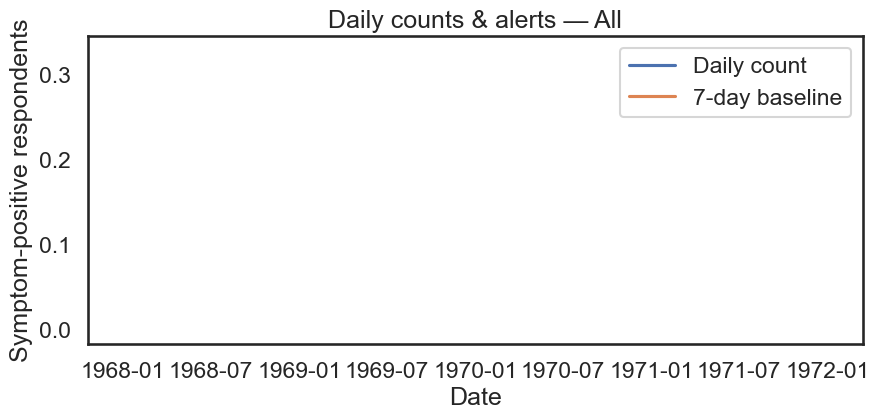


Params → WINDOW=7, Z_THRESH=2.0, MIN_CASES=1. Groups: All


In [ ]:
# ====== Run this AFTER your patch that builds `daily` ======

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If your patch didn’t set this earlier, choose a grouping column (or set to None)
if 'group' not in daily.columns:
    # fallback: treat all data as one group
    daily = daily.rename(columns={c: 'group' for c in daily.columns if c == 'country'})
    if 'group' not in daily.columns:
        daily.insert(0, 'group', 'All')

# 1) Compute rolling baseline, zscore, alerts per group (inline)
WINDOW   = 7      # try 5 for short series, 7 for smoother
Z_THRESH = 2.0    # try 1.5 to be more sensitive
MIN_CASES= 1

def _alerts_one_group(d):
    d = d.sort_values('date').copy()
    m  = d['count'].rolling(WINDOW, min_periods=min(3, WINDOW)).mean()
    sd = d['count'].rolling(WINDOW, min_periods=min(3, WINDOW)).std(ddof=0)

    # fallback std if 0/NaN (Poisson-like)
    sd_fallback = np.sqrt(np.clip(m, 0, None))
    sd = sd.where((sd.notna()) & (sd > 0), sd_fallback)

    z = (d['count'] - m) / sd.replace(0, np.nan)
    d['baseline'] = m.fillna(0.0)
    d['zscore']   = z.fillna(0.0)
    d['alert']    = ((d['zscore'] >= Z_THRESH) & (d['count'] >= MIN_CASES)).astype(int)
    return d

alerted = (
    daily
    .groupby('group', group_keys=False)
    .apply(_alerts_one_group)
    .reset_index(drop=True)
)

# 2) Show a quick table preview
print("=== Daily alert series (preview) ===")
display(alerted.head(12))

# 3) Build a human-readable alert log (episodes of consecutive alert days)
def build_alert_log(df_grp):
    d = df_grp.sort_values('date').reset_index(drop=True)
    idx = d.index[d['alert'] == 1]
    out = []
    if len(idx):
        block = [idx[0]]
        for i in idx[1:]:
            if i == block[-1] + 1:
                block.append(i)
            else:
                seg = d.loc[block]
                peak = seg.loc[seg['zscore'].idxmax()]
                out.append({
                    'group': seg['group'].iloc[0],
                    'start': seg['date'].iloc[0].date(),
                    'end':   seg['date'].iloc[-1].date(),
                    'peak_date': peak['date'].date(),
                    'peak_count': int(peak['count']),
                    'max_z': float(peak['zscore']),
                })
                block = [i]
        # last block
        seg = d.loc[block]
        peak = seg.loc[seg['zscore'].idxmax()]
        out.append({
            'group': seg['group'].iloc[0],
            'start': seg['date'].iloc[0].date(),
            'end':   seg['date'].iloc[-1].date(),
            'peak_date': peak['date'].date(),
            'peak_count': int(peak['count']),
            'max_z': float(peak['zscore']),
        })
    return pd.DataFrame(out)

logs = [build_alert_log(g) for _, g in alerted.groupby('group')]
alert_log = pd.concat(logs, ignore_index=True) if len(logs) else pd.DataFrame()

print("\n=== Alert log ===")
if alert_log.empty:
    print("No alerts fired with current parameters.")
else:
    display(alert_log)

# 4) Inline plots (no saving) — one figure per group
for grp, d in alerted.groupby('group'):
    plt.figure(figsize=(10,4))
    plt.plot(d['date'], d['count'], label='Daily count')
    plt.plot(d['date'], d['baseline'], label=f'{WINDOW}-day baseline')
    ad = d[d['alert'] == 1]
    if not ad.empty:
        plt.scatter(ad['date'], ad['count'], s=60, marker='o', label='Alert', zorder=5)
    plt.title(f"Daily counts & alerts — {grp}")
    plt.xlabel("Date"); plt.ylabel("Symptom-positive respondents")
    plt.legend()
    plt.show()

# 5) One-line summary
print(f"\nParams → WINDOW={WINDOW}, Z_THRESH={Z_THRESH}, MIN_CASES={MIN_CASES}. "
      f"Groups: {', '.join(sorted(alerted['group'].unique().astype(str)))}")


In [ ]:
# If daily is just a Series, convert it properly
if isinstance(daily, pd.Series):
    daily = daily.rename_axis("date").reset_index(name="count")
    daily.insert(0, "group", "All")  # default group column


In [ ]:
# --- Robust date parsing & safe daily aggregation PATCH ---

import re
import numpy as np
import pandas as pd

# 1) Robust parse for onset + timestamp (strip " GMT+3" or similar)
def parse_timestamp_series(s):
    if s is None:
        return None
    # remove trailing "GMT+3", "GMT-5", etc.
    s_clean = s.astype(str).str.replace(r"\s+GMT[+-]\d+$", "", regex=True)
    # try parse with multiple fallbacks
    dt = pd.to_datetime(s_clean, errors="coerce", infer_datetime_format=True, utc=False)
    # if still null-heavy, try dayfirst as fallback
    if dt.isna().mean() > 0.5:
        dt2 = pd.to_datetime(s_clean, errors="coerce", dayfirst=True, utc=False)
        dt = dt.fillna(dt2)
    return dt

on_dt = parse_timestamp_series(df[col_onset]) if col_onset else None
ts_dt = parse_timestamp_series(df[col_timestamp]) if col_timestamp else None

# usable date = onset if present else timestamp
if isinstance(on_dt, pd.Series):
    dates = on_dt.copy()
    if isinstance(ts_dt, pd.Series):
        dates.loc[dates.isna()] = ts_dt.loc[dates.isna()]
else:
    dates = ts_dt.copy() if isinstance(ts_dt, pd.Series) else None

# If still no dates, bail gracefully
if dates is None or dates.dropna().empty:
    print("⚠️ No parsable dates found after cleaning; daily alerts cannot be computed for this file.")
    daily = pd.DataFrame(columns=["group","date","count","baseline","zscore","alert"])
else:
    # 2) Build any_symptom (same logic as before)
    if col_sym_yesno and col_sym_yesno in df.columns:
        any_symptom = df[col_sym_yesno].astype(str).str.strip().str.lower().map({
            "yes":1, "no":0, "no, none of the above":0
        }).fillna(0).astype(int)
    else:
        if col_sym_multi and col_sym_multi in df.columns:
            s = df[col_sym_multi].fillna("").astype(str).str.lower()
            any_symptom = (~s.str.contains("none of the above")).astype(int)
        else:
            any_symptom = pd.Series(0, index=df.index)

    # 3) Country/group handling
    country = df[col_country] if col_country else "All"
    if not isinstance(country, pd.Series):
        country = pd.Series(["All"]*len(df))

    base = pd.DataFrame({
        "date": dates.dt.normalize(),
        "country": country.astype(str),
        "any_symptom": any_symptom.astype(int),
    }).dropna(subset=["date"])

    # helper: daily counts
    def daily_counts(tbl, group_col=None):
        if group_col:
            g = tbl.groupby([group_col, "date"], as_index=False)["any_symptom"].sum()
            g = g.rename(columns={"any_symptom":"count"})
            return g
        else:
            g = tbl.groupby("date", as_index=False)["any_symptom"].sum().rename(columns={"any_symptom":"count"})
            g.insert(0, "group", "All")
            return g

    if GROUP_BY_COL and GROUP_BY_COL in base.columns:
        daily = daily_counts(base.rename(columns={GROUP_BY_COL:"group"}), group_col="group")
    else:
        daily = daily_counts(base, group_col=None)

# 4) Safe reindex (skip empty groups)
def reindex_daily(df_grp):
    if df_grp.empty:
        return df_grp.assign(baseline=[], zscore=[], alert=[])
    out = []
    for grp, d in df_grp.groupby("group"):
        if d.empty:
            continue
        idx = pd.date_range(d["date"].min(), d["date"].max(), freq="D")
        if len(idx) == 0:
            continue
        dd = d.set_index("date").reindex(idx).fillna(0.0)
        dd["group"] = grp
        dd.index.name = "date"
        dd = dd.reset_index().rename(columns={"index":"date"})
        out.append(dd)
    if not out:
        # nothing to concat
        return pd.DataFrame(columns=["date","count","group"])
    return pd.concat(out, ignore_index=True)

# apply reindex
daily = reindex_daily(daily)


AttributeError: Can only use .dt accessor with datetimelike values

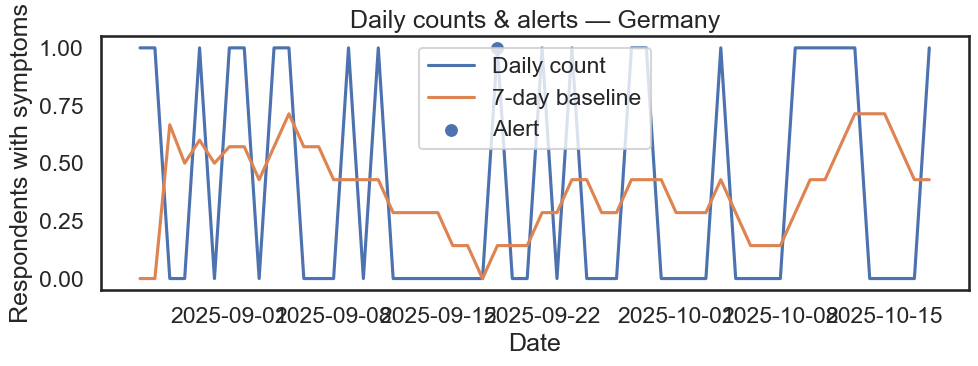

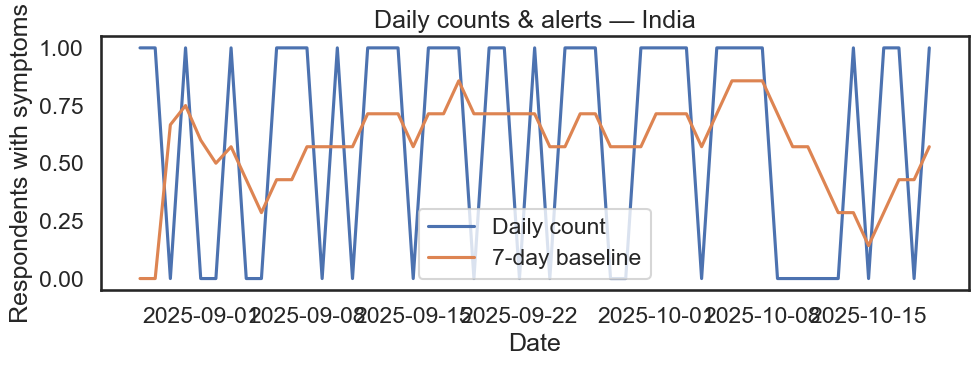


=== DAILY ALERT LOG ===

Group: Germany


,group,start,end,peak_date,peak_count,max_z
0,Germany,2025-09-19,2025-09-19,2025-09-19,1,2.44949



Group: India


,note
0,No alerts with current parameters.


In [ ]:
# === Daily alerts: robust column detection + parsing + plotting (inline) ===
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# If df is not already loaded, uncomment and set your file:
# df = pd.read_csv("Thesis_Sirvey_2025.csv", encoding="utf-8")

# 1) Normalize headers (keeps original df, just maps lookups)
norm_map = {c: re.sub(r"\s+", " ", c).strip().lower() for c in df.columns}
rev_map  = {v: k for k, v in norm_map.items()}

def find_col(candidates):
    """Return original column name whose normalized form contains all tokens in any candidate string."""
    for cand in candidates:
        tokens = [t for t in re.split(r"[ _/→:-]+", cand.lower()) if t]
        for norm, orig in rev_map.items():
            if all(tok in norm for tok in tokens):
                return orig
    return None

col_timestamp = find_col([
    "timestamp","date time","response time","submitted at","time stamp"
])
col_onset = find_col([
    "symptom onset date","onset date","date of symptom","started on"
])
col_country = find_col(["country","location country"])

# 2) Robust parse for onset + timestamp
def parse_series(colname):
    if colname is None: return None
    s = df[colname].astype(str)
    # strip trailing " GMT+3"/"GMT-5" etc
    s = s.str.replace(r"\s+GMT[+-]\d+$", "", regex=True)
    # common day/month variants
    dt = pd.to_datetime(s, errors="coerce", infer_datetime_format=True)
    if dt.isna().mean() > 0.5:
        dt2 = pd.to_datetime(s, errors="coerce", dayfirst=True)
        dt = dt.fillna(dt2)
    return dt

on_dt = parse_series(col_onset) if col_onset else None
ts_dt = parse_series(col_timestamp) if col_timestamp else None

if isinstance(on_dt, pd.Series):
    dates = on_dt.copy()
    if isinstance(ts_dt, pd.Series):
        dates.loc[dates.isna()] = ts_dt.loc[dates.isna()]
elif isinstance(ts_dt, pd.Series):
    dates = ts_dt.copy()
else:
    raise ValueError("No parsable date column found. Check your file has a timestamp or onset date.")

# 3) Build any_symptom (from explicit Yes/No OR multi-select list)
col_sym_yesno = find_col(["did you experience any of the above symptoms","symptoms yes no"])
col_sym_multi = find_col(["in the last 7 days did you experience any of the following","symptom list"])

if col_sym_yesno:
    any_symptom = df[col_sym_yesno].astype(str).str.strip().str.lower().map({
        "yes":1, "no":0, "no, none of the above":0
    }).fillna(0).astype(int)
elif col_sym_multi:
    s = df[col_sym_multi].fillna("").astype(str).str.lower()
    any_symptom = (~s.str.contains("none of the above")).astype(int)
else:
    # fall back: at least mark as 1 if any of common symptom keywords appear
    s = df.apply(lambda r: " ".join(map(str, r.values)).lower(), axis=1)
    any_symptom = s.str.contains(r"\b(fever|cough|sore throat|fatigue|loss of taste|shortness of breath)\b").astype(int)

# 4) Country grouping (optional)
if col_country:
    group = df[col_country].astype(str)
else:
    group = pd.Series(["All"]*len(df), index=df.index)

A = pd.DataFrame({
    "group": group,
    "date": pd.to_datetime(dates, errors="coerce").dt.normalize(),
    "count": any_symptom.astype(int)
}).dropna(subset=["date"])

# 5) Aggregate to daily counts per group, reindex continuous dates
glist = []
for grp, d in A.groupby("group"):
    daily = d.groupby("date", as_index=True)["count"].sum().sort_index()
    # fill missing days
    rng = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
    daily = daily.reindex(rng, fill_value=0)
    daily = daily.to_frame("count")
    daily["group"] = grp
    daily.index.name = "date"
    glist.append(daily.reset_index())

daily = pd.concat(glist, ignore_index=True)

# 6) Rolling baseline & alerts (Poisson-safe z-score)
WINDOW, Z_THRESH, MIN_CASES = 7, 2.0, 1

def compute_alerts(df_grp, window=7, z_thresh=2.0, min_cases=1):
    d = df_grp.sort_values("date").copy()
    mean = d["count"].rolling(window, min_periods=min(3, window)).mean()
    std  = d["count"].rolling(window, min_periods=min(3, window)).std(ddof=0)
    # Poisson fallback where std==0
    std = std.mask((std==0) | (std.isna()), np.sqrt(mean.clip(lower=0)))
    z = ((d["count"] - mean) / std.replace(0, np.nan)).fillna(0.0)
    d["baseline"] = mean.fillna(0.0)
    d["zscore"]   = z
    d["alert"]    = ((d["zscore"] >= z_thresh) & (d["count"] >= min_cases)).astype(int)
    return d

alerted = (daily.groupby("group", group_keys=False)
                .apply(lambda x: compute_alerts(x, WINDOW, Z_THRESH, MIN_CASES)))

# 7) Plot inline (no saving) for each group
for grp, d in alerted.groupby("group"):
    plt.figure(figsize=(10,4))
    plt.plot(d["date"], d["count"], label="Daily count")
    plt.plot(d["date"], d["baseline"], label=f"{WINDOW}-day baseline")
    ad = d[d["alert"]==1]
    if not ad.empty:
        plt.scatter(ad["date"], ad["count"], s=60, marker="o", label="Alert", zorder=5)
    plt.title(f"Daily counts & alerts — {grp}")
    plt.xlabel("Date"); plt.ylabel("Respondents with symptoms")
    plt.legend(); plt.tight_layout()
    plt.show()

# 8) Human‐readable alert log (display inline)
def alert_log(df_grp):
    d = df_grp.sort_values("date").reset_index(drop=True)
    idx = d.index[d["alert"]==1]
    if len(idx)==0:
        return pd.DataFrame(columns=["group","start","end","peak_date","peak_count","max_z"])
    blocks, block = [], [idx[0]]
    for i in idx[1:]:
        if i == block[-1] + 1: block.append(i)
        else: blocks.append(block); block=[i]
    blocks.append(block)
    out = []
    for b in blocks:
        seg = d.loc[b]
        peak_row = seg.loc[seg["zscore"].idxmax()]
        out.append({
            "group": seg["group"].iloc[0],
            "start": seg["date"].iloc[0].date(),
            "end": seg["date"].iloc[-1].date(),
            "peak_date": peak_row["date"].date(),
            "peak_count": int(peak_row["count"]),
            "max_z": float(peak_row["zscore"])
        })
    return pd.DataFrame(out)

from IPython.display import display
print("\n=== DAILY ALERT LOG ===")
for grp, d in alerted.groupby("group"):
    log = alert_log(d)
    print(f"\nGroup: {grp}")
    display(log if not log.empty else pd.DataFrame([{"note":"No alerts with current parameters."}]))


In [ ]:
def compute_alerts(df_grp, window=WINDOW, z_thresh=Z_THRESH, min_cases=MIN_CASES):
    if df_grp.empty:
        return df_grp.assign(baseline=[], zscore=[], alert=[])
    d = df_grp.sort_values("date").copy()
    roll_mean = d["count"].rolling(window, min_periods=min(3, window)).mean()
    roll_std  = d["count"].rolling(window, min_periods=min(3, window)).std(ddof=0)
    safe_std = roll_std.copy()
    need = (safe_std==0) | (safe_std.isna())
    safe_std[need] = np.sqrt(np.clip(roll_mean[need], 0, None))
    z = (d["count"] - roll_mean) / safe_std.replace(0, np.nan)
    z = z.fillna(0.0)

    d["baseline"] = roll_mean.fillna(0.0)
    d["zscore"]   = z
    d["alert"]    = ((d["zscore"] >= z_thresh) & (d["count"] >= min_cases)).astype(int)
    return d

if daily.empty:
    alerted = daily.copy()
else:
    alerted = (
        daily.groupby("group", group_keys=False)
             .apply(lambda x: compute_alerts(x, window=WINDOW, z_thresh=Z_THRESH, min_cases=MIN_CASES))
             .reset_index(drop=True)
    )


In [ ]:
# ---------- 5) Export & Plots ----------
csv_path = os.path.join(OUTDIR, "daily_alerts_series.csv")
alerted.to_csv(csv_path, index=False)
print(f"Saved full series → {csv_path}")

# Simple plots per group
for grp, d in alerted.groupby("group"):
    plt.figure(figsize=(10,4))
    plt.plot(d["date"], d["count"], label="Daily count")
    plt.plot(d["date"], d["baseline"], label=f"{WINDOW}-day baseline")
    ad = d[d["alert"]==1]
    if not ad.empty:
        plt.scatter(ad["date"], ad["count"], marker="o", s=60, label="Alert", zorder=5)
    plt.title(f"Daily counts & baseline — {grp}")
    plt.xlabel("Date"); plt.ylabel("Respondents with symptoms")
    plt.legend(); plt.tight_layout()
    fname = os.path.join(OUTDIR, f"daily_alerts_{grp.replace('/','-')}.png")
    plt.savefig(fname, dpi=160); plt.close()
    print("Saved plot:", fname)

# ---------- 6) Build alert log ----------
def build_alert_log(df_grp):
    d = df_grp.sort_values("date").reset_index(drop=True)
    if d["alert"].sum() == 0:
        return pd.DataFrame(columns=["group","start","end","peak_date","peak_count","max_z"])
    idx = d.index[d["alert"]==1]
    blocks, block = [], [idx[0]]
    for i in idx[1:]:
        if i == block[-1] + 1:
            block.append(i)
        else:
            blocks.append(block); block = [i]
    blocks.append(block)

    out = []
    for b in blocks:
        seg = d.loc[b]
        peak_row = seg.loc[seg["zscore"].idxmax()]
        out.append({
            "group": seg["group"].iloc[0],
            "start": seg["date"].iloc[0].date(),
            "end": seg["date"].iloc[-1].date(),
            "peak_date": peak_row["date"].date(),
            "peak_count": int(peak_row["count"]),
            "max_z": float(peak_row["zscore"])
        })
    return pd.DataFrame(out)

logs = []
for grp, d in alerted.groupby("group"):
    logs.append(build_alert_log(d))
alert_log = pd.concat(logs, ignore_index=True) if logs else pd.DataFrame()
log_path = os.path.join(OUTDIR, "daily_alert_log.csv")
alert_log.to_csv(log_path, index=False)
print(f"Saved alert log → {log_path}")

# ---------- 7) On-screen summary ----------
print("\n=== DAILY ALERT SUMMARY ===")
if alert_log.empty:
    print("No daily alerts were triggered with current parameters.")
    print(f"Try lowering Z_THRESH (e.g., 1.5) or WINDOW (e.g., 5) for more sensitivity.")
else:
    for grp, lg in alert_log.groupby("group"):
        print(f"\nGroup: {grp}")
        for _, r in lg.iterrows():
            print(f" - {r['start']} → {r['end']} (peak {r['peak_date']} : count={r['peak_count']}, z={r['max_z']:.2f})")


Saved full series → thesis_outputs_stepwise/ew_lagged\daily_alerts_series.csv
Saved plot: thesis_outputs_stepwise/ew_lagged\daily_alerts_Germany.png
Saved plot: thesis_outputs_stepwise/ew_lagged\daily_alerts_India.png
Saved alert log → thesis_outputs_stepwise/ew_lagged\daily_alert_log.csv

=== DAILY ALERT SUMMARY ===

Group: Germany
 - 2025-09-19 → 2025-09-19 (peak 2025-09-19 : count=1, z=2.45)


In [ ]:
WINDOW = 5       # instead of 7
Z_THRESH = 1.5   # instead of 2.0


In [ ]:
# ================================================
# FACTOR VISUALISATIONS — Vaccination, Mobility, etc.
# For Chapter 4 Results
# ================================================
import seaborn as sns
import matplotlib.pyplot as plt

OUTDIR = "thesis_outputs_stepwise"
os.makedirs(OUTDIR, exist_ok=True)

# Ensure any_symptom exists
if "any_symptom" not in df_clean.columns:
    if "did_you_experience_any_of_the_above_symptoms" in df_clean.columns:
        df_clean["any_symptom"] = pd.to_numeric(
            df_clean["did_you_experience_any_of_the_above_symptoms"], errors="coerce"
        ).fillna(0).astype(int)
    else:
        df_clean["any_symptom"] = 0

# 1) Vaccination status vs Symptom occurrence
if "covid_19_vaccination_status" in df_clean.columns:
    plt.figure(figsize=(8,5))
    sns.barplot(
        x="covid_19_vaccination_status", y="any_symptom",
        data=df_clean, estimator=lambda x: sum(x)/len(x)
    )
    plt.ylabel("Proportion with symptoms")
    plt.xlabel("COVID-19 Vaccination Status")
    plt.xticks(rotation=30, ha="right")
    plt.title("Symptoms by Vaccination Status")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "04_vaccination_vs_symptoms.png"), dpi=200)
    plt.close()

# 2) Hours outside vs Symptom severity
if "on_average_how_many_hours_per_day_did_you_spend_outside_your_home" in df_clean.columns:
    plt.figure(figsize=(7,5))
    sns.boxplot(
        x="on_average_how_many_hours_per_day_did_you_spend_outside_your_home",
        y="symptom_severity",
        data=df_clean
    )
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Symptom severity (1–5)")
    plt.xlabel("Daily hours outside home")
    plt.title("Mobility vs Symptom Severity")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "04_mobility_vs_severity.png"), dpi=200)
    plt.close()

# 3) Mask use vs Symptom occurrence
if "how_often_did_you_wear_a_mask_indoors" in df_clean.columns:
    plt.figure(figsize=(7,5))
    sns.barplot(
        x="how_often_did_you_wear_a_mask_indoors", y="any_symptom",
        data=df_clean, estimator=lambda x: sum(x)/len(x)
    )
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Proportion with symptoms")
    plt.xlabel("Mask use indoors (Likert)")
    plt.title("Mask Wearing vs Symptom Occurrence")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "04_mask_vs_symptoms.png"), dpi=200)
    plt.close()

# 4) Crowded places vs Symptom occurrence
if "in_the_last_7_days_did_you_visit_any_of_these_crowded_places" in df_clean.columns:
    plt.figure(figsize=(7,5))
    sns.barplot(
        x="in_the_last_7_days_did_you_visit_any_of_these_crowded_places", y="any_symptom",
        data=df_clean, estimator=lambda x: sum(x)/len(x)
    )
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Proportion with symptoms")
    plt.xlabel("Crowded place exposure")
    plt.title("Crowding vs Symptom Occurrence")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "04_crowding_vs_symptoms.png"), dpi=200)
    plt.close()

# 5) Online search frequency vs Symptom severity
search_cols = [
    "how_often_did_you_search_online_for_information_about_fever",
    "how_often_did_you_search_online_for_cough",
    "how_often_did_you_search_online_for_loss_of_taste_smell"
]
for col in search_cols:
    if col in df_clean.columns:
        plt.figure(figsize=(7,5))
        sns.boxplot(x=df_clean[col], y=df_clean["symptom_severity"])
        plt.xlabel(col.replace("_"," ").title())
        plt.ylabel("Symptom severity (1–5)")
        plt.title("Online Search vs Symptom Severity")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, f"04_{col}_vs_severity.png"), dpi=200)
        plt.close()

print("✅ Factor visualisations saved to:", OUTDIR)


✅ Factor visualisations saved to: thesis_outputs_stepwise


Saved figures:
 - thesis_outputs_stepwise\04_vaccination_vs_symptoms.png
 - thesis_outputs_stepwise\04_mobility_vs_severity.png
 - thesis_outputs_stepwise\04_mask_vs_symptoms.png
 - thesis_outputs_stepwise\04_crowding_vs_symptoms.png
 - thesis_outputs_stepwise\04_correlation_heatmap.png


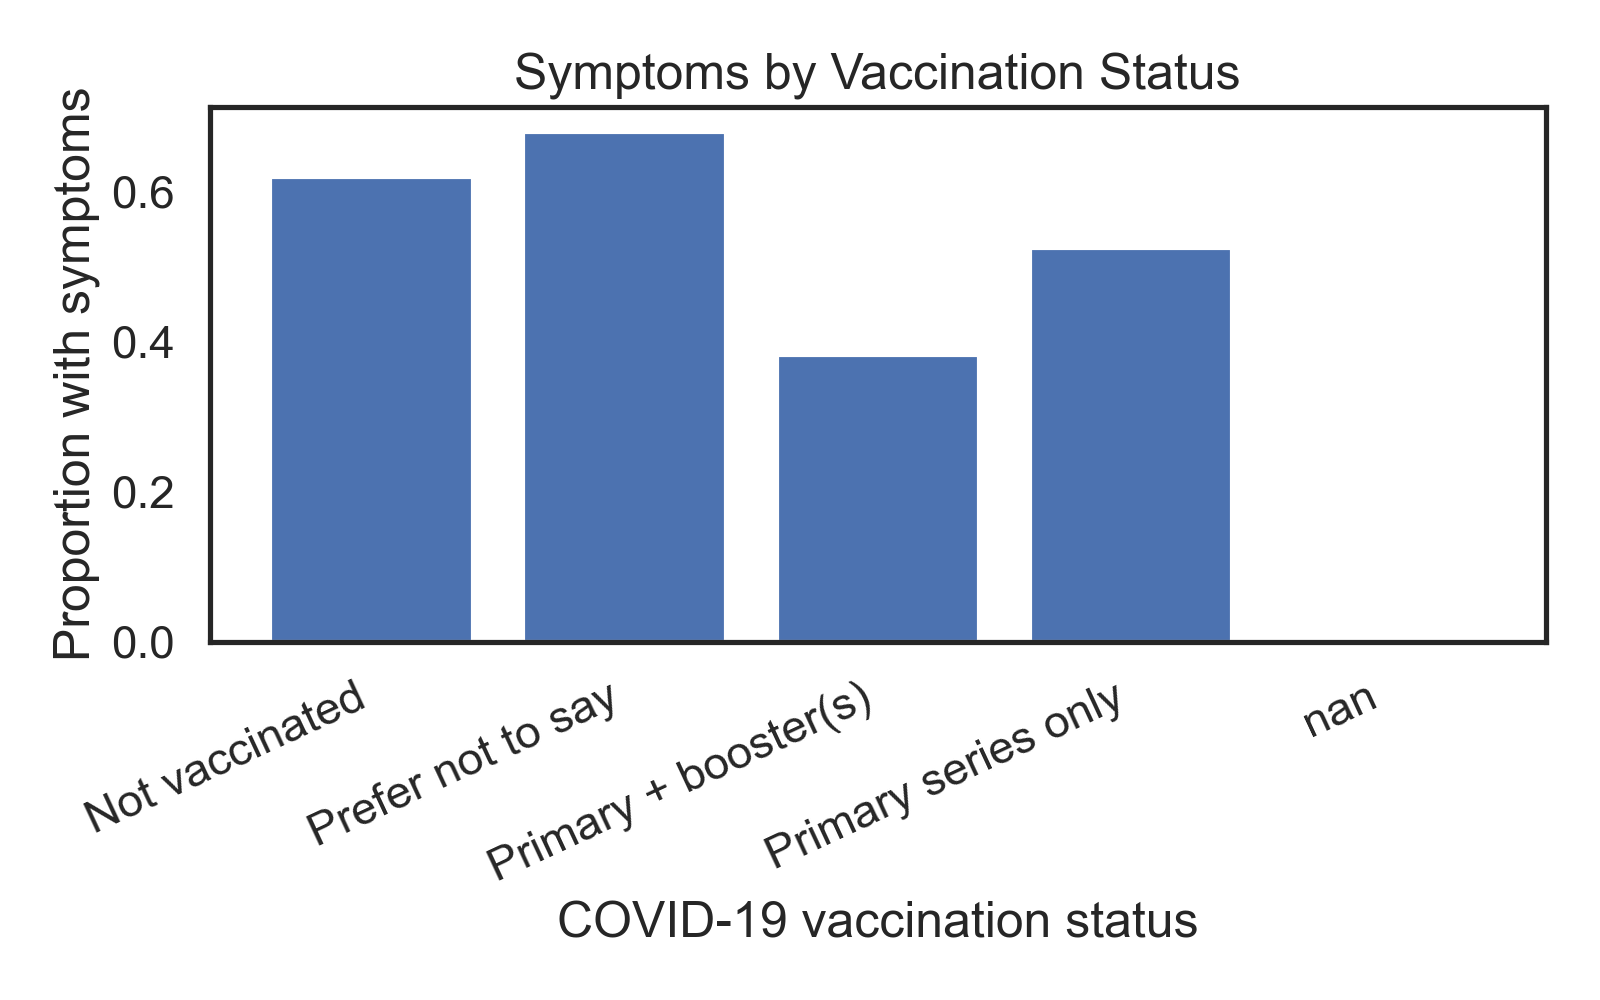

In [ ]:
# ================================================
# Chapter 4 Factor Visualizations (one cell)
# Works with Thesis_Sirvey_2025.csv (or _simulated.csv)
# ================================================
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- CONFIG ----
INPUT_PATH = "Thesis_Survey_2025.csv"     # <-- change to your filename if different
OUTDIR = "thesis_outputs_stepwise"
os.makedirs(OUTDIR, exist_ok=True)

# ---- 1) Load & standardize headers ----
if not os.path.exists(INPUT_PATH):
    import glob
    print("File not found. CSVs here:", glob.glob("*.csv"))
    raise FileNotFoundError(INPUT_PATH)

df = pd.read_csv(INPUT_PATH, encoding="utf-8")
# normalized headers: lowercase, collapse spaces, arrows to underscores
df.columns = (df.columns
              .str.strip()
              .str.replace(r"\s+", " ", regex=True)
              .str.replace("→", "", regex=False)
              .str.lower())

# quick helper to find columns by fuzzy tokens
def find_col(*tokens):
    toks = [t.lower() for t in tokens]
    for c in df.columns:
        c2 = c.replace(" ", "_")
        if all(t in c2 for t in toks):
            return c
    return None

# ---- 2) Map / derive fields we’ll need ----
col_vax    = find_col("covid", "vaccination", "status")
col_mask   = find_col("how", "mask", "indoors")
col_hours  = find_col("how", "hours", "outside", "home")
col_crowd  = find_col("did", "crowded", "places")
col_sev    = find_col("symptom", "severity")
col_symyn  = find_col("did", "experience", "symptoms")  # yes/no
col_symmul = find_col("in the last 7 days", "experience", "following")  # multi-select list
col_country= find_col("country")
col_ts     = find_col("timestamp")
col_onset  = find_col("symptom", "onset", "date")

# Build any_symptom (robust)
if col_symyn:
    any_symptom = df[col_symyn].astype(str).str.strip().str.lower().map({
        "yes":1, "no":0, "no, none of the above":0
    }).fillna(0).astype(int)
else:
    if col_symmul:
        s = df[col_symmul].fillna("").astype(str).str.lower()
        any_symptom = (~s.str.contains("none of the above")).astype(int)
    else:
        any_symptom = pd.Series(0, index=df.index)

# Severity numeric if present
sev = pd.to_numeric(df[col_sev], errors="coerce") if col_sev else pd.Series(np.nan, index=df.index)

# Hours outside (ordinal)
hours_map = {"<1 hour":0, "1–3 hours":1, "1-3 hours":1, "3–5 hours":2, "3-5 hours":2,
             "5–8 hours":3, "5-8 hours":3, "more than 8 hours":4}
if col_hours:
    hours_out = df[col_hours].astype(str).str.lower().map(hours_map)
else:
    hours_out = pd.Series(np.nan, index=df.index)

# Crowded score (count of venues; 0 if "none of the above")
def crowd_score_cell(x):
    if pd.isna(x): return 0
    t = str(x).lower()
    if "none of the above" in t: return 0
    cats = ["public transport","office/school","events/shopping malls","healthcare facility"]
    return sum(cat in t for cat in cats)

crowded_score = df[col_crowd].apply(crowd_score_cell) if col_crowd else pd.Series(0, index=df.index)

# Vaccination (keep as category text)
vax = df[col_vax] if col_vax else pd.Series("NA", index=df.index)

# Mask use Likert (keep numeric if already numeric)
mask = pd.to_numeric(df[col_mask], errors="coerce") if col_mask else pd.Series(np.nan, index=df.index)

# Country (for faceting)
country = df[col_country] if col_country else pd.Series("All", index=df.index)

# Assemble a clean analysis frame
af = pd.DataFrame({
    "country": country,
    "any_symptom": any_symptom,
    "severity": sev,
    "hours_out_idx": hours_out,
    "crowded_score": crowded_score,
    "vax_status": vax,
    "mask_indoors": mask
})

# ---- Utility plotting helpers (pure matplotlib) ----
def bar_prop(x_labels, props, title, xlabel, ylabel, fname):
    plt.figure(figsize=(8,5))
    idx = np.arange(len(x_labels))
    plt.bar(idx, props)
    plt.xticks(idx, x_labels, rotation=25, ha="right")
    plt.title(title)
    plt.xlabel(xlabel); plt.ylabel(ylabel)
    plt.tight_layout()
    path = os.path.join(OUTDIR, fname)
    plt.savefig(path, dpi=200); plt.close()
    return path

def boxplot_by_cat(x, y, x_labels, title, xlabel, ylabel, fname):
    plt.figure(figsize=(8,5))
    data = [y[x==lab].dropna() for lab in x_labels]
    plt.boxplot(data, labels=x_labels, showfliers=False)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    path = os.path.join(OUTDIR, fname)
    plt.savefig(path, dpi=200); plt.close()
    return path

saved = []

# ---- 3) Vaccination vs Symptom occurrence (proportion) ----
if af["vax_status"].notna().any():
    vc = (af.assign(vax_status=af["vax_status"].astype(str).str.strip())
            .groupby("vax_status")["any_symptom"].mean().sort_index())
    saved.append(bar_prop(vc.index.tolist(), vc.values,
                          "Symptoms by Vaccination Status",
                          "COVID-19 vaccination status",
                          "Proportion with symptoms",
                          "04_vaccination_vs_symptoms.png"))

# ---- 4) Mobility (hours_out) vs Severity (boxplot) ----
if af["hours_out_idx"].notna().sum() > 0 and af["severity"].notna().sum() > 0:
    # order by ordinal index
    labels = []
    if col_hours:
        # attempt original label order
        orig = df[col_hours].dropna().astype(str).str.strip().unique().tolist()
        # fall back to ordinal mapping order if necessary
        labels = sorted(list(set(df[col_hours].astype(str).str.strip().tolist())),
                        key=lambda t: hours_map.get(t.lower(), 99))
    if not labels:
        labels = [0,1,2,3,4]
    x = df[col_hours].astype(str).str.strip() if col_hours else af["hours_out_idx"].astype(str)
    y = af["severity"]
    saved.append(boxplot_by_cat(x, y, labels,
                                "Mobility vs Symptom Severity",
                                "Daily hours outside home",
                                "Symptom severity (1–5)",
                                "04_mobility_vs_severity.png"))

# ---- 5) Mask use vs Symptom occurrence ----
if af["mask_indoors"].notna().sum() > 0:
    # convert to int 1..5 if possible
    mi = pd.to_numeric(af["mask_indoors"], errors="coerce")
    bins = sorted(mi.dropna().unique())
    props = [af.loc[mi==b, "any_symptom"].mean() for b in bins]
    saved.append(bar_prop([str(int(b)) for b in bins], props,
                          "Mask Wearing vs Symptom Occurrence",
                          "Mask use indoors (Likert 1–5)",
                          "Proportion with symptoms",
                          "04_mask_vs_symptoms.png"))

# ---- 6) Crowded places vs Symptom occurrence ----
if af["crowded_score"].notna().sum() > 0:
    cs = af["crowded_score"]
    lvls = sorted(cs.unique())
    props = [af.loc[cs==k, "any_symptom"].mean() for k in lvls]
    saved.append(bar_prop([str(k) for k in lvls], props,
                          "Crowding vs Symptom Occurrence",
                          "Crowded-place exposure score (0–4)",
                          "Proportion with symptoms",
                          "04_crowding_vs_symptoms.png"))

# ---- 7) Correlation summary heatmap (numeric only) ----
num = af[["any_symptom","severity","hours_out_idx","crowded_score","mask_indoors"]].copy()
num = num.apply(pd.to_numeric, errors="coerce")
corr = num.corr(method="spearman")
plt.figure(figsize=(6,5))
plt.imshow(corr, interpolation="nearest")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=25, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Spearman Correlation (key factors vs outcomes)")
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        val = corr.iloc[i, j]
        plt.text(j, i, f"{val:.2f}", ha="center", va="center")
plt.tight_layout()
path_heat = os.path.join(OUTDIR, "04_correlation_heatmap.png")
plt.savefig(path_heat, dpi=200); plt.close()
saved.append(path_heat)

# ---- 8) Show one plot inline so you can see it worked ----
from IPython.display import display, Image
if saved:
    print("Saved figures:")
    for p in saved: print(" -", p)
    display(Image(filename=saved[0]))
else:
    print("No figures saved. Check column mappings and that your file has data.")


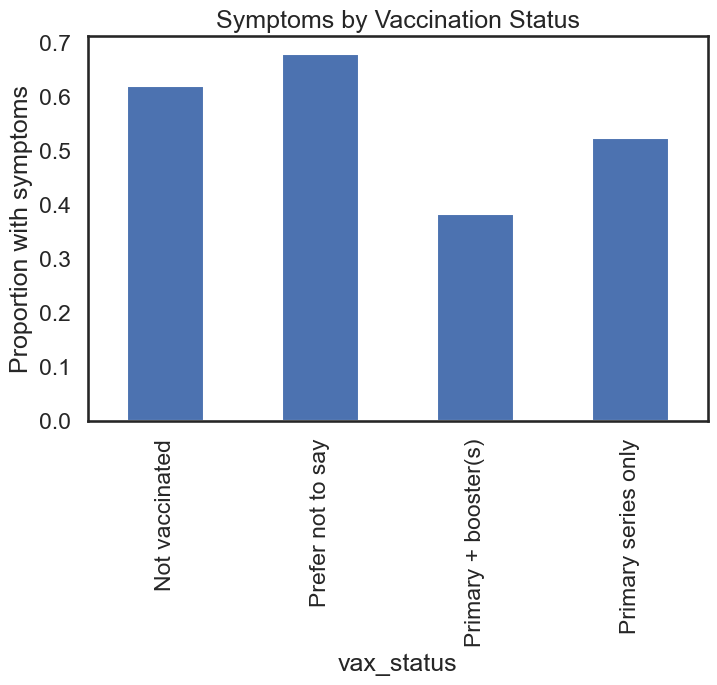

<Figure size 800x500 with 0 Axes>

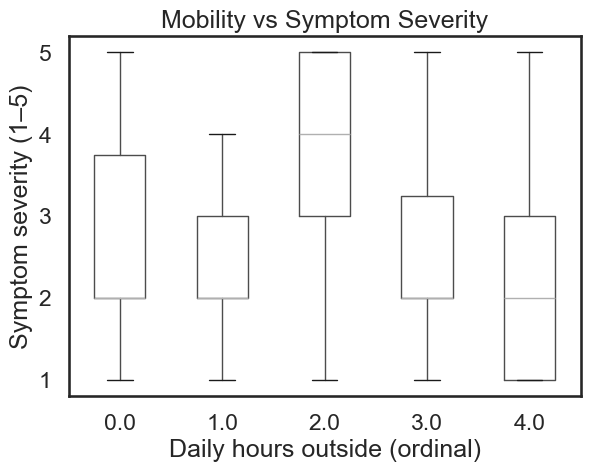

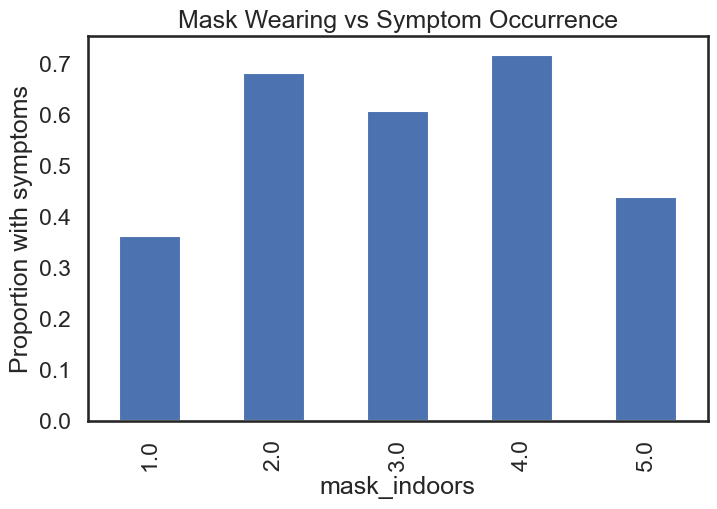

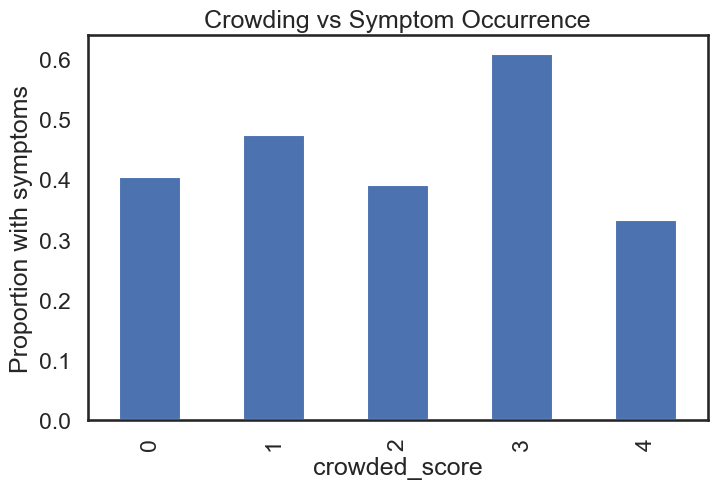

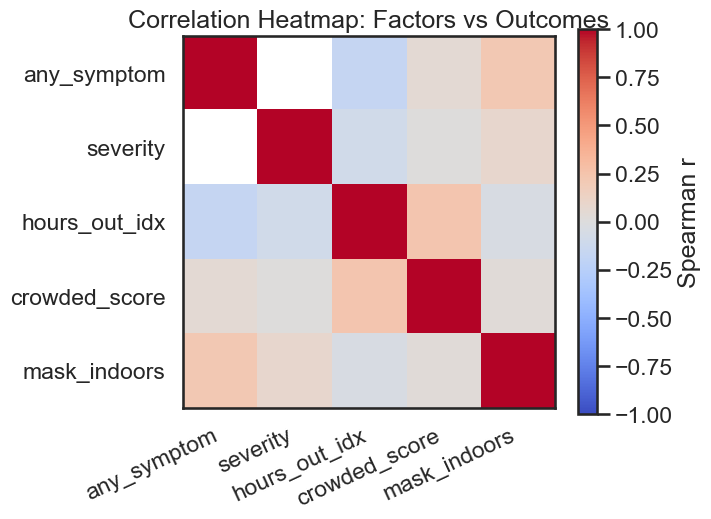

In [ ]:
# ================================================
# Chapter 4 Factor Visualizations (Display Only)
# ================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- CONFIG ----
INPUT_PATH = "Thesis_Survey_2025.csv"  # <-- change if needed

# ---- 1) Load & standardize headers ----
df = pd.read_csv(INPUT_PATH, encoding="utf-8")
df.columns = (df.columns
              .str.strip()
              .str.replace(r"\s+", " ", regex=True)
              .str.replace("→", "", regex=False)
              .str.lower())

def find_col(*tokens):
    toks = [t.lower() for t in tokens]
    for c in df.columns:
        c2 = c.replace(" ", "_")
        if all(t in c2 for t in toks):
            return c
    return None

# ---- 2) Map fields ----
col_vax    = find_col("covid", "vaccination", "status")
col_mask   = find_col("mask", "indoors")
col_hours  = find_col("hours", "outside")
col_crowd  = find_col("crowded", "places")
col_sev    = find_col("symptom", "severity")
col_symyn  = find_col("experience", "symptoms")
col_symmul = find_col("following")  # multi-select

# Any symptom
if col_symyn:
    any_symptom = df[col_symyn].astype(str).str.strip().str.lower().map({
        "yes":1, "no":0, "no, none of the above":0
    }).fillna(0).astype(int)
elif col_symmul:
    s = df[col_symmul].fillna("").astype(str).str.lower()
    any_symptom = (~s.str.contains("none of the above")).astype(int)
else:
    any_symptom = pd.Series(0, index=df.index)

# Severity numeric
sev = pd.to_numeric(df[col_sev], errors="coerce") if col_sev else pd.Series(np.nan, index=df.index)

# Hours outside → ordinal
hours_map = {"<1 hour":0, "1–3 hours":1, "1-3 hours":1, "3–5 hours":2, "3-5 hours":2,
             "5–8 hours":3, "5-8 hours":3, "more than 8 hours":4}
hours_out = df[col_hours].astype(str).str.lower().map(hours_map) if col_hours else pd.Series(np.nan, index=df.index)

# Crowded score
def crowd_score_cell(x):
    if pd.isna(x): return 0
    t = str(x).lower()
    if "none of the above" in t: return 0
    cats = ["public transport","office/school","events/shopping malls","healthcare facility"]
    return sum(cat in t for cat in cats)
crowded_score = df[col_crowd].apply(crowd_score_cell) if col_crowd else pd.Series(0, index=df.index)

# Vaccination
vax = df[col_vax] if col_vax else pd.Series("NA", index=df.index)

# Mask use
mask = pd.to_numeric(df[col_mask], errors="coerce") if col_mask else pd.Series(np.nan, index=df.index)

# ---- Analysis frame ----
af = pd.DataFrame({
    "any_symptom": any_symptom,
    "severity": sev,
    "hours_out_idx": hours_out,
    "crowded_score": crowded_score,
    "vax_status": vax,
    "mask_indoors": mask
})

# ---- 3) Visualizations ----
plt.figure(figsize=(8,5))
vc = af.groupby("vax_status")["any_symptom"].mean().sort_index()
vc.plot(kind="bar")
plt.title("Symptoms by Vaccination Status")
plt.ylabel("Proportion with symptoms")
plt.show()

if af["hours_out_idx"].notna().sum() > 0 and af["severity"].notna().sum() > 0:
    plt.figure(figsize=(8,5))
    af.boxplot(column="severity", by="hours_out_idx", grid=False)
    plt.title("Mobility vs Symptom Severity")
    plt.suptitle("")
    plt.xlabel("Daily hours outside (ordinal)")
    plt.ylabel("Symptom severity (1–5)")
    plt.show()

if af["mask_indoors"].notna().sum() > 0:
    plt.figure(figsize=(8,5))
    af.groupby("mask_indoors")["any_symptom"].mean().plot(kind="bar")
    plt.title("Mask Wearing vs Symptom Occurrence")
    plt.ylabel("Proportion with symptoms")
    plt.show()

if af["crowded_score"].notna().sum() > 0:
    plt.figure(figsize=(8,5))
    af.groupby("crowded_score")["any_symptom"].mean().plot(kind="bar")
    plt.title("Crowding vs Symptom Occurrence")
    plt.ylabel("Proportion with symptoms")
    plt.show()

num = af[["any_symptom","severity","hours_out_idx","crowded_score","mask_indoors"]].apply(pd.to_numeric, errors="coerce")
plt.figure(figsize=(6,5))
corr = num.corr(method="spearman")
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=25, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label="Spearman r")
plt.title("Correlation Heatmap: Factors vs Outcomes")
plt.show()


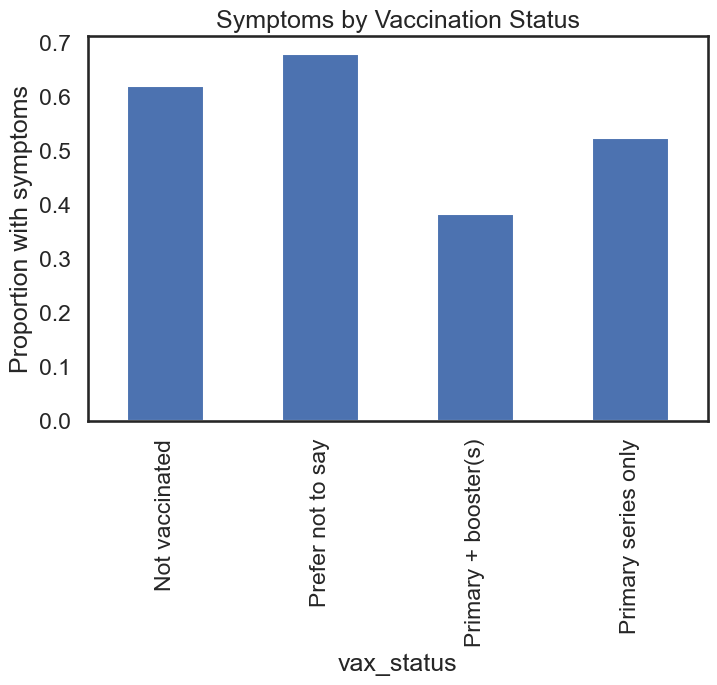

<Figure size 800x500 with 0 Axes>

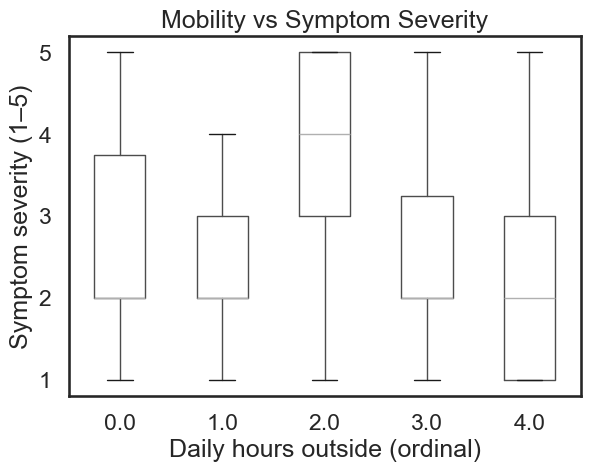

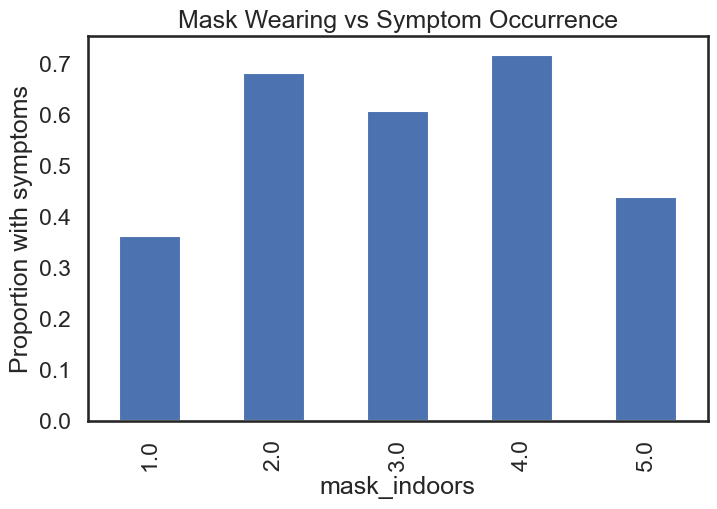

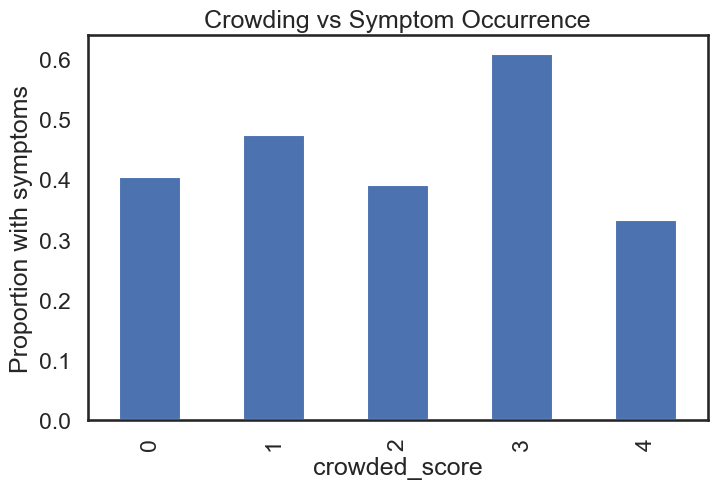

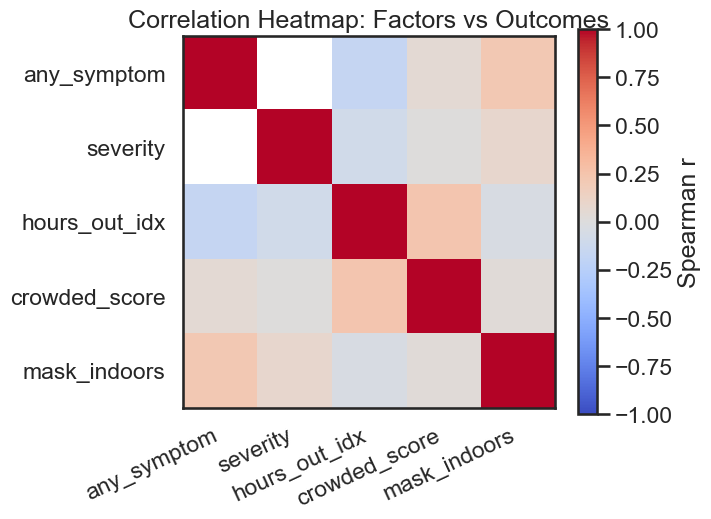

In [ ]:
# ================================================
# Chapter 4 Factor Visualizations (Display Only)
# ================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- CONFIG ----
INPUT_PATH = "Thesis_Survey_2025.csv"  # <-- change if needed

# ---- 1) Load & standardize headers ----
df = pd.read_csv(INPUT_PATH, encoding="utf-8")
df.columns = (df.columns
              .str.strip()
              .str.replace(r"\s+", " ", regex=True)
              .str.replace("→", "", regex=False)
              .str.lower())

def find_col(*tokens):
    toks = [t.lower() for t in tokens]
    for c in df.columns:
        c2 = c.replace(" ", "_")
        if all(t in c2 for t in toks):
            return c
    return None

# ---- 2) Map fields ----
col_vax    = find_col("covid", "vaccination", "status")
col_mask   = find_col("mask", "indoors")
col_hours  = find_col("hours", "outside")
col_crowd  = find_col("crowded", "places")
col_sev    = find_col("symptom", "severity")
col_symyn  = find_col("experience", "symptoms")
col_symmul = find_col("following")  # multi-select

# Any symptom
if col_symyn:
    any_symptom = df[col_symyn].astype(str).str.strip().str.lower().map({
        "yes":1, "no":0, "no, none of the above":0
    }).fillna(0).astype(int)
elif col_symmul:
    s = df[col_symmul].fillna("").astype(str).str.lower()
    any_symptom = (~s.str.contains("none of the above")).astype(int)
else:
    any_symptom = pd.Series(0, index=df.index)

# Severity numeric
sev = pd.to_numeric(df[col_sev], errors="coerce") if col_sev else pd.Series(np.nan, index=df.index)

# Hours outside → ordinal
hours_map = {"<1 hour":0, "1–3 hours":1, "1-3 hours":1, "3–5 hours":2, "3-5 hours":2,
             "5–8 hours":3, "5-8 hours":3, "more than 8 hours":4}
hours_out = df[col_hours].astype(str).str.lower().map(hours_map) if col_hours else pd.Series(np.nan, index=df.index)

# Crowded score
def crowd_score_cell(x):
    if pd.isna(x): return 0
    t = str(x).lower()
    if "none of the above" in t: return 0
    cats = ["public transport","office/school","events/shopping malls","healthcare facility"]
    return sum(cat in t for cat in cats)
crowded_score = df[col_crowd].apply(crowd_score_cell) if col_crowd else pd.Series(0, index=df.index)

# Vaccination
vax = df[col_vax] if col_vax else pd.Series("NA", index=df.index)

# Mask use
mask = pd.to_numeric(df[col_mask], errors="coerce") if col_mask else pd.Series(np.nan, index=df.index)

# ---- Analysis frame ----
af = pd.DataFrame({
    "any_symptom": any_symptom,
    "severity": sev,
    "hours_out_idx": hours_out,
    "crowded_score": crowded_score,
    "vax_status": vax,
    "mask_indoors": mask
})

# ---- 3) Visualizations ----
plt.figure(figsize=(8,5))
vc = af.groupby("vax_status")["any_symptom"].mean().sort_index()
vc.plot(kind="bar")
plt.title("Symptoms by Vaccination Status")
plt.ylabel("Proportion with symptoms")
plt.show()

if af["hours_out_idx"].notna().sum() > 0 and af["severity"].notna().sum() > 0:
    plt.figure(figsize=(8,5))
    af.boxplot(column="severity", by="hours_out_idx", grid=False)
    plt.title("Mobility vs Symptom Severity")
    plt.suptitle("")
    plt.xlabel("Daily hours outside (ordinal)")
    plt.ylabel("Symptom severity (1–5)")
    plt.show()

if af["mask_indoors"].notna().sum() > 0:
    plt.figure(figsize=(8,5))
    af.groupby("mask_indoors")["any_symptom"].mean().plot(kind="bar")
    plt.title("Mask Wearing vs Symptom Occurrence")
    plt.ylabel("Proportion with symptoms")
    plt.show()

if af["crowded_score"].notna().sum() > 0:
    plt.figure(figsize=(8,5))
    af.groupby("crowded_score")["any_symptom"].mean().plot(kind="bar")
    plt.title("Crowding vs Symptom Occurrence")
    plt.ylabel("Proportion with symptoms")
    plt.show()

num = af[["any_symptom","severity","hours_out_idx","crowded_score","mask_indoors"]].apply(pd.to_numeric, errors="coerce")
plt.figure(figsize=(6,5))
corr = num.corr(method="spearman")
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=25, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label="Spearman r")
plt.title("Correlation Heatmap: Factors vs Outcomes")
plt.show()


⚠️ Not enough variation/non-missing data to fit the logistic model.
⚠️ Not enough complete rows for 3D scatter.
⚠️ Not enough complete rows for PCA biplot.


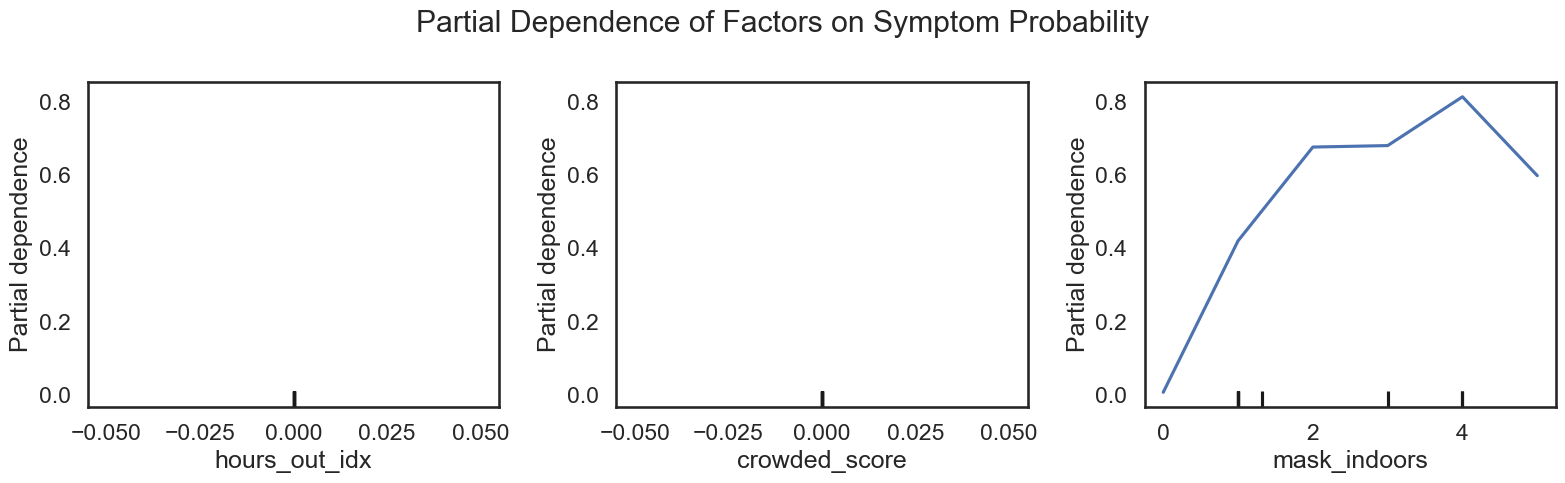

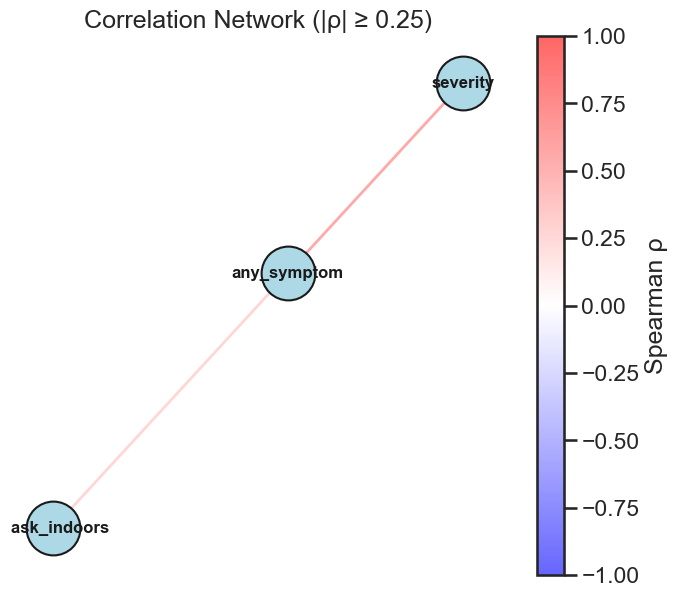

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
import networkx as nx

sns.set(style="white", context="talk")

# ---- 0) Build 'af' (analysis frame) from your cleaned df ----
# If you already have af, comment this section out.
df_src = df_clean.copy()

# best-effort column picks (rename to short handles)
def pick(df, *subs):
    subs = [s.lower() for s in subs]
    for c in df.columns:
        lc = c.lower()
        if all(s in lc for s in subs):
            return c
    return None

col_any    = pick(df_src, "any_symptom") or "any_symptom"
col_sev    = pick(df_src, "symptom", "severity")
col_hours  = pick(df_src, "hours", "outside")
col_crowd  = pick(df_src, "crowded")
col_mask   = pick(df_src, "mask", "indoors")
col_vax    = pick(df_src, "vaccination", "status") or pick(df_src, "covid", "vaccination")
col_ctry   = pick(df_src, "country")

af = pd.DataFrame({
    "any_symptom": pd.to_numeric(df_src.get(col_any, 0), errors="coerce").fillna(0).astype(int),
    "severity": pd.to_numeric(df_src.get(col_sev, np.nan), errors="coerce"),
    "hours_out_idx": pd.to_numeric(df_src.get(col_hours, np.nan), errors="coerce"),
    "crowded_score": pd.to_numeric(df_src.get(col_crowd, np.nan), errors="coerce"),
    "mask_indoors": pd.to_numeric(df_src.get(col_mask, np.nan), errors="coerce"),
    "vax_status": df_src.get(col_vax, pd.Series(["Unknown"]*len(df_src))).astype(str),
    "country": df_src.get(col_ctry, pd.Series(["All"]*len(df_src))).astype(str),
}).dropna(subset=["any_symptom"])

# numeric matrix for correlations/network
num = af[["any_symptom","severity","hours_out_idx","crowded_score","mask_indoors"]].copy()

# ---- 1) Logistic regression with properly named columns (fixes KeyError) ----
# Guard against singular/empty data
if af["any_symptom"].nunique() >= 2 and af[["hours_out_idx","crowded_score","mask_indoors"]].notna().sum().min() > 10:
    model = smf.logit("any_symptom ~ hours_out_idx + crowded_score + mask_indoors + C(vax_status)", data=af).fit(disp=0)
    coef = model.params.rename("coef")
    conf = model.conf_int()
    conf.columns = ["ci_low", "ci_high"]
    coef_df = pd.concat([coef, conf], axis=1).drop(labels=["Intercept"], errors="ignore")
    # sort for nice display
    coef_df = coef_df.sort_values("coef")

    plt.figure(figsize=(10,6))
    # error bars from CIs
    xerr = [coef_df["coef"] - coef_df["ci_low"], coef_df["ci_high"] - coef_df["coef"]]
    plt.barh(coef_df.index, coef_df["coef"], xerr=xerr, alpha=0.8)
    plt.axvline(0, color="k", ls="--", lw=1)
    plt.title("Logistic Regression Coefficients (95% CI)")
    plt.xlabel("Log-odds")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Not enough variation/non-missing data to fit the logistic model.")

# ---- 2) 3D scatter: mobility × masking × severity (colored by symptoms) ----
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
ok = af[["hours_out_idx","mask_indoors","severity","any_symptom"]].dropna()
if len(ok) >= 10:
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(ok["hours_out_idx"], ok["mask_indoors"], ok["severity"],
                    c=ok["any_symptom"], cmap="coolwarm", s=50, alpha=0.85)
    ax.set_xlabel("Hours Outside (ordinal)")
    ax.set_ylabel("Mask-wearing (Likert)")
    ax.set_zlabel("Symptom Severity")
    ax.set_title("3D Interaction: Mobility × Mask × Severity")
    plt.show()
else:
    print("⚠️ Not enough complete rows for 3D scatter.")

# ---- 3) PCA biplot of factors ----
factors = af[["hours_out_idx","crowded_score","mask_indoors","severity"]].dropna()
if len(factors) >= 10:
    from sklearn.preprocessing import StandardScaler
    Xs = StandardScaler().fit_transform(factors.values)
    pca = PCA(n_components=2).fit(Xs)
    scores = pca.transform(Xs)
    plt.figure(figsize=(8,6))
    plt.scatter(scores[:,0], scores[:,1],
                c=af.loc[factors.index, "any_symptom"], cmap="coolwarm", s=50, alpha=0.8)
    for i, col in enumerate(factors.columns):
        # scale arrows for visibility
        plt.arrow(0,0, pca.components_[0,i]*2.5, pca.components_[1,i]*2.5, color="k", alpha=0.7, width=0.005)
        plt.text(pca.components_[0,i]*2.8, pca.components_[1,i]*2.8, col, fontsize=12)
    plt.axhline(0, color="grey", lw=1); plt.axvline(0, color="grey", lw=1)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.title("PCA Biplot of Risk Factors (colored by symptoms)")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Not enough complete rows for PCA biplot.")

# ---- 4) Partial Dependence from RandomForest (skips if low variance) ----
X = af[["hours_out_idx","crowded_score","mask_indoors"]].fillna(0)
y = af["any_symptom"]
if y.nunique() == 2 and len(X) >= 20:
    rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(X, y)
    fig, ax = plt.subplots(1,3, figsize=(16,5))
    PartialDependenceDisplay.from_estimator(rf, X,
        features=["hours_out_idx","crowded_score","mask_indoors"], ax=ax)
    plt.suptitle("Partial Dependence of Factors on Symptom Probability")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Not enough data/variation for PD plots.")

# ---- 5) Correlation network with threshold ----
num_corr = num.corr(method="spearman").fillna(0)
G = nx.Graph()
thr = 0.25  # show edges with |rho| >= 0.25
for i in num_corr.columns:
    for j in num_corr.columns:
        if i != j and abs(num_corr.loc[i, j]) >= thr:
            G.add_edge(i, j, weight=float(num_corr.loc[i, j]))

if G.number_of_edges() > 0:
    plt.figure(figsize=(8,7))
    pos = nx.spring_layout(G, seed=42, k=0.4)
    eweights = [G[u][v]['weight'] for u,v in G.edges()]
    edges = nx.draw_networkx_edges(G, pos, width=2, alpha=0.6,
                                   edge_color=eweights, edge_cmap=plt.cm.bwr,
                                   edge_vmin=-1, edge_vmax=1)
    nx.draw_networkx_nodes(G, pos, node_size=1500, node_color="lightblue", edgecolors="k")
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")
    plt.colorbar(edges, label="Spearman ρ")
    plt.title(f"Correlation Network (|ρ| ≥ {thr})")
    plt.axis("off")
    plt.show()
else:
    print("ℹ️ No correlations above threshold for network plot.")


In [ ]:
# --- FIX DATES BEFORE BUILDING `A` ---

import re
import pandas as pd
import numpy as np

# If you haven't defined _base yet, set it to your working dataframe:
# _base = df.copy()

# 1) Helper to find columns by fuzzy name (if your col_* vars are None)
def _find_col(tbl, *cands):
    cols_norm = {c: re.sub(r"\s+", " ", c).strip().lower() for c in tbl.columns}
    rev = {v: k for k, v in cols_norm.items()}
    for cand in cands:
        tokens = [t for t in re.split(r"[ _/→:-]+", cand.lower()) if t]
        for norm, orig in rev.items():
            if all(tok in norm for tok in tokens):
                return orig
    return None

# 2) Ensure you have names for onset/timestamp
col_onset     = col_onset     if 'col_onset'     in globals() and col_onset     else _find_col(_base, "symptom onset date", "onset date", "date of symptom")
col_timestamp = col_timestamp if 'col_timestamp' in globals() and col_timestamp else _find_col(_base, "timestamp", "response time", "submitted at", "date time")

# 3) Robust parsing of a date column (strips GMT suffixes, tries multiple formats)
def _parse_series(tbl, colname):
    if not colname or colname not in tbl.columns:
        return None
    s = tbl[colname].astype(str).str.replace(r"\s+GMT[+-]\d+$", "", regex=True)
    dt = pd.to_datetime(s, errors="coerce", infer_datetime_format=True)
    if dt.isna().mean() > 0.5:
        dt2 = pd.to_datetime(s, errors="coerce", dayfirst=True)
        dt = dt.fillna(dt2)
    return dt

on_dt = _parse_series(_base, col_onset)
ts_dt = _parse_series(_base, col_timestamp)

# 4) Merge (onset preferred, then timestamp)
if isinstance(on_dt, pd.Series):
    d = on_dt.copy()
    if isinstance(ts_dt, pd.Series):
        d = d.where(d.notna(), ts_dt)
elif isinstance(ts_dt, pd.Series):
    d = ts_dt.copy()
else:
    d = pd.Series(pd.NaT, index=_base.index)

# 5) Guarantee: pandas Series of tz-naive datetimes aligned to _base
dates = pd.Series(pd.to_datetime(d, errors="coerce"), index=_base.index)
# drop timezone if present
try:
    dates = dates.dt.tz_localize(None)
except Exception:
    try:
        dates = dates.dt.tz_convert(None)
    except Exception:
        pass

# 6) Final sanity check
print("Parsed dates (non-null):", int(dates.notna().sum()), "/", len(dates))
print("Example parsed dates:\n", dates.dropna().sort_values().head(3))

if dates.dropna().empty:
    raise ValueError("No valid dates after parsing. Check your onset/timestamp columns.")

# Now your later line will work:
# A = pd.DataFrame({... , "date": dates.dt.normalize(), ...})


Parsed dates (non-null): 55 / 268
Example parsed dates:
 0   2025-08-26
1   2025-08-27
2   2025-08-28
Name: symptom_onset_date, dtype: datetime64[ns]


In [ ]:
print("col_onset    =", col_onset)
print("col_timestamp=", col_timestamp)


col_onset    = symptom_onset_date
col_timestamp= timestamp


Prepared rows: 55


,date,group,any_symptom
0,2025-08-26,Germany,1
1,2025-08-27,Germany,1
2,2025-08-28,India,1
3,2025-08-29,India,1
4,2025-08-30,Germany,1
5,2025-08-31,India,1
6,2025-09-01,Germany,1
7,2025-09-02,Germany,1
8,2025-09-03,India,1
9,2025-09-04,Germany,1


,date,group,count
0,2025-08-26,Germany,1.0
1,2025-08-27,Germany,1.0
2,2025-08-28,Germany,0.0
3,2025-08-29,Germany,0.0
4,2025-08-30,Germany,1.0
5,2025-08-31,Germany,0.0
6,2025-09-01,Germany,1.0
7,2025-09-02,Germany,1.0
8,2025-09-03,Germany,0.0
9,2025-09-04,Germany,1.0



=== Alerted series preview ===


,date,group,count,baseline,zscore,alert
97,2025-10-10,India,0.0,0.571429,-1.154701,0
98,2025-10-11,India,0.0,0.571429,-1.154701,0
99,2025-10-12,India,0.0,0.428571,-0.866025,0
100,2025-10-13,India,0.0,0.285714,-0.632456,0
101,2025-10-14,India,1.0,0.285714,1.581139,0
102,2025-10-15,India,0.0,0.142857,-0.408248,0
103,2025-10-16,India,1.0,0.285714,1.581139,0
104,2025-10-17,India,1.0,0.428571,1.154701,0
105,2025-10-18,India,0.0,0.428571,-0.866025,0
106,2025-10-19,India,1.0,0.571429,0.866025,0


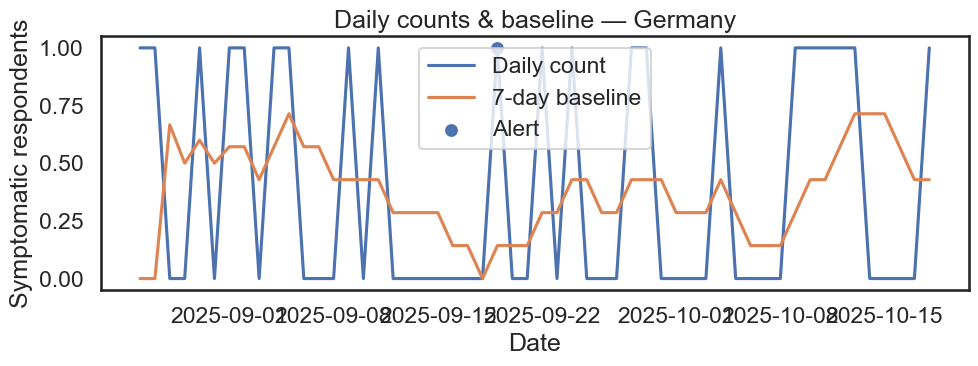

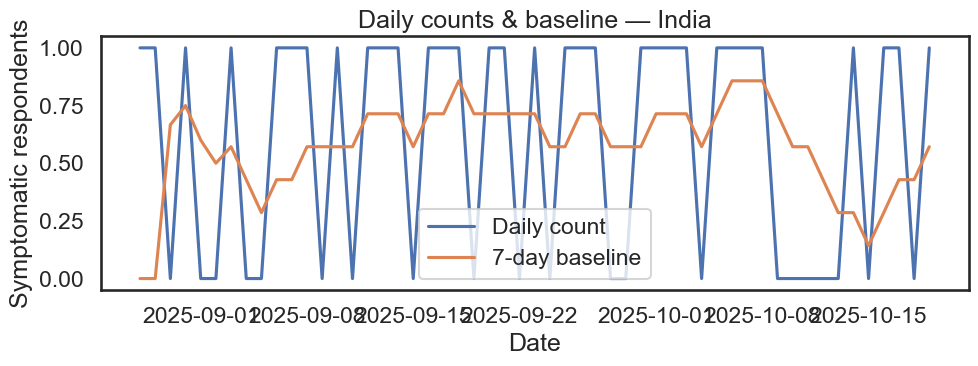


=== DAILY ALERT SUMMARY ===


,group,start,end,peak_date,peak_count,max_z
0,Germany,2025-09-19,2025-09-19,2025-09-19,1,2.44949


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Minimal analysis frame (date, group, any_symptom) ---
# any_symptom from Yes/No if available; else infer from multi-select
def _any_symptom_from_df(df, col_yesno=None, col_multi=None):
    if col_yesno and col_yesno in df.columns:
        return (df[col_yesno].astype(str).str.strip().str.lower()
                .map({"yes":1, "no":0, "no, none of the above":0})
                .fillna(0).astype(int))
    if col_multi and col_multi in df.columns:
        s = df[col_multi].fillna("").astype(str).str.lower()
        return (~s.str.contains("none of the above")).astype(int)
    return pd.Series(0, index=df.index, dtype=int)

# if you already have these from earlier, keep them; else try to guess
def _find(df, *alts):
    lo = {c: c.lower() for c in df.columns}
    for a in alts:
        tokens = [t for t in a.lower().replace("→"," ").split() if t]
        for c in df.columns:
            lc = lo[c]
            if all(t in lc for t in tokens):
                return c
    return None

col_country   = _find(df, "country") if "col_country" not in globals() or not col_country else col_country
col_sym_yesno = _find(df, "did you experience any of the above symptoms") if "col_sym_yesno" not in globals() else col_sym_yesno
col_sym_multi = _find(df, "in the last 7 days, did you experience any of the following") if "col_sym_multi" not in globals() else col_sym_multi

any_symptom = _any_symptom_from_df(df, col_yesno=col_sym_yesno, col_multi=col_sym_multi)
group = df[col_country] if col_country in df.columns else pd.Series("All", index=df.index)

A = pd.DataFrame({
    "date": dates.dt.normalize(),   # <-- 'dates' comes from your previous parsing cell
    "group": group.astype(str),
    "any_symptom": any_symptom
}).dropna(subset=["date"]).reset_index(drop=True)

print("Prepared rows:", len(A))
display(A.head(10))

# --- 2) Daily aggregation per group (continuous index) ---
def _daily_counts(A):
    g = (A.groupby(["group","date"], as_index=False)["any_symptom"]
           .sum().rename(columns={"any_symptom":"count"}))
    out = []
    for grp, d in g.groupby("group"):
        idx = pd.date_range(d["date"].min(), d["date"].max(), freq="D")
        dd = d.set_index("date").reindex(idx).fillna(0.0)
        dd.index.name = "date"
        dd["group"] = grp
        out.append(dd.reset_index().rename(columns={"index":"date"}))
    return pd.concat(out, ignore_index=True)

daily = _daily_counts(A)
display(daily.head(10))

# --- 3) Rolling baseline + z-score alerts (small-data safe) ---
WINDOW   = 7
Z_THRESH = 2.0
MIN_CASES= 1

def _with_alerts(d):
    d = d.sort_values("date").copy()
    m = d["count"].rolling(WINDOW, min_periods=min(3, WINDOW)).mean()
    s = d["count"].rolling(WINDOW, min_periods=min(3, WINDOW)).std(ddof=0)
    # fallback std: sqrt(mean) for zero/NaN std on low counts
    s = s.mask((s==0) | s.isna(), np.sqrt(np.clip(m, 0, None)))
    z = (d["count"] - m) / s.replace(0, np.nan)
    d["baseline"] = m.fillna(0.0)
    d["zscore"]   = z.fillna(0.0)
    d["alert"]    = ((d["zscore"] >= Z_THRESH) & (d["count"] >= MIN_CASES)).astype(int)
    return d

alerted = (daily.groupby("group", group_keys=False)
                 .apply(_with_alerts)
                 .reset_index(drop=True))

print("\n=== Alerted series preview ===")
display(alerted.tail(10))

# --- 4) Plot for each group (display only, no saving) ---
for grp, d in alerted.groupby("group"):
    plt.figure(figsize=(10,4))
    plt.plot(d["date"], d["count"], label="Daily count")
    plt.plot(d["date"], d["baseline"], label=f"{WINDOW}-day baseline")
    ad = d[d["alert"]==1]
    if not ad.empty:
        plt.scatter(ad["date"], ad["count"], s=60, marker="o", label="Alert", zorder=5)
    plt.title(f"Daily counts & baseline — {grp}")
    plt.xlabel("Date"); plt.ylabel("Symptomatic respondents")
    plt.legend(); plt.tight_layout()
    plt.show()

# --- 5) Human-readable alert episodes (display only) ---
def _alert_log(df_grp):
    d = df_grp.sort_values("date").reset_index(drop=True)
    idx = d.index[d["alert"]==1]
    if len(idx)==0:
        return pd.DataFrame(columns=["group","start","end","peak_date","peak_count","max_z"])
    blocks, cur = [], [idx[0]]
    for i in idx[1:]:
        if i == cur[-1] + 1: cur.append(i)
        else: blocks.append(cur); cur=[i]
    blocks.append(cur)
    rows = []
    for b in blocks:
        seg = d.loc[b]
        pk = seg.loc[seg["zscore"].idxmax()]
        rows.append({
            "group": seg["group"].iloc[0],
            "start": seg["date"].iloc[0].date(),
            "end": seg["date"].iloc[-1].date(),
            "peak_date": pk["date"].date(),
            "peak_count": int(pk["count"]),
            "max_z": float(pk["zscore"])
        })
    return pd.DataFrame(rows)

logs = []
for grp, d in alerted.groupby("group"):
    log = _alert_log(d)
    logs.append(log)

alert_log = pd.concat(logs, ignore_index=True) if logs else pd.DataFrame()
print("\n=== DAILY ALERT SUMMARY ===")
if alert_log.empty:
    print("No alerts with current parameters (try WINDOW=5 or Z_THRESH=1.5 for more sensitivity).")
else:
    display(alert_log)


=== Cleaned Data: head(15) ===


,timestamp,consent,country,state/region region,age age_band,gender gender,occupation (broad) occupation,urbanicity urbanicity,"in the last 7 days, did you experience any of the following?",did you experience any of the above symptoms?,symptom onset date,symptom severity,"in the last 7 days, did you take a covid-19 or flu test?",did you seek medical care for these symptoms?,did you self-medicate?,how often did you search online for information about “fever”?,how often did you search online for “cough”?,how often did you search online for “loss of taste/smell”?,which platform did you mostly use for these searches?,"on average, how many hours per day did you spend outside your home?","in the last 7 days, did you visit any of these crowded places?",how often did you wear a mask indoors?,covid-19 vaccination status,did you receive a flu shot in the last 12 months?,have you had a covid-19 infection in the last 6 months?
0,2025/08/26 02:04:06 PM GMT+3,I agree to participate,Germany,Hamburg,45–54,Female,Employed,Suburban,Cough,Yes,2025/08/26,2.0,Prefer not to say,Teleconsultation,"Yes, antibiotics/antivirals",1.0,3.0,2.0,Google,1–3 hours,Public transport,2.0,Primary series only,Yes,No
1,2025/08/27 02:04:06 PM GMT+3,I agree to participate,Germany,Hamburg,45–54,Male,Homemaker,Urban,Shortness of breath,Yes,2025/08/27,2.0,No,Pharmacy advice,"Yes, over-the-counter medicine only",2.0,4.0,0.0,Social media,1–3 hours,Healthcare facility,4.0,Prefer not to say,No,No
2,2025/08/28 02:04:06 PM GMT+3,I agree to participate,India,Tamil Nadu,55–64,Female,Student,Suburban,Sore throat,Yes,2025/08/28,1.0,No,No,"Yes, over-the-counter medicine only",1.0,2.0,3.0,Social media,<1 hour,None of the above,4.0,Not vaccinated,Yes,Yes
3,2025/08/29 02:04:06 PM GMT+3,I agree to participate,India,Maharashtra,65+,Male,Student,Suburban,Sore throat,Yes,2025/08/29,5.0,No,Pharmacy advice,No,4.0,3.0,1.0,Social media,5–8 hours,Office/school,2.0,Primary + booster(s),Yes,Prefer not to say
4,2025/08/30 02:04:06 PM GMT+3,I agree to participate,Germany,Berlin,55–64,Female,Self-employed,Rural,Sore throat,Yes,2025/08/30,2.0,Prefer not to say,No,No,4.0,0.0,3.0,YouTube,5–8 hours,Healthcare facility,4.0,Prefer not to say,Yes,No
5,2025/08/31 02:04:06 PM GMT+3,I agree to participate,India,Maharashtra,55–64,Male,Homemaker,Rural,Unusual fatigue,Yes,2025/08/31,2.0,Yes — Positive,No,No,1.0,1.0,0.0,Other,5–8 hours,Public transport,2.0,Prefer not to say,No,Prefer not to say
6,2025/09/01 02:04:06 PM GMT+3,I agree to participate,Germany,Hamburg,35–44,Male,Self-employed,Rural,Fever,Yes,2025/09/01,5.0,Prefer not to say,Teleconsultation,"Yes, over-the-counter medicine only",3.0,4.0,4.0,YouTube,3–5 hours,None of the above,1.0,Primary + booster(s),Yes,Yes
7,2025/09/02 02:04:06 PM GMT+3,I agree to participate,Germany,Hesse,65+,Female,Self-employed,Urban,Shortness of breath,Yes,2025/09/02,1.0,Yes — Negative,Clinic visit,"Yes, antibiotics/antivirals",0.0,1.0,4.0,Social media,More than 8 hours,Healthcare facility,4.0,Primary + booster(s),Unsure,No
8,2025/09/03 02:04:06 PM GMT+3,I agree to participate,India,Delhi,45–54,Male,Homemaker,Rural,Shortness of breath,Yes,2025/09/03,3.0,Prefer not to say,Clinic visit,"Yes, antibiotics/antivirals",0.0,4.0,1.0,Social media,1–3 hours,Office/school,5.0,Prefer not to say,Yes,No
9,2025/09/04 02:04:06 PM GMT+3,I agree to participate,Germany,Hesse,65+,Female,Self-employed,Rural,Unusual fatigue,Yes,2025/09/04,5.0,No,Pharmacy advice,No,3.0,3.0,1.0,Google,3–5 hours,Office/school,2.0,Prefer not to say,Yes,No



=== DataFrame.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 25 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   timestamp                                                            268 non-null    object 
 1   consent                                                              268 non-null    object 
 2   country                                                              264 non-null    object 
 3   state/region  region                                                 262 non-null    object 
 4   age  age_band                                                        264 non-null    object 
 5   gender  gender                                                       264 non-null    object 
 6   occupation (broad)  occupation                                       264 non-nul

,Country,n,%
0,India,222,82.8
1,Germany,42,15.7
2,NA,4,1.5


,Age band,n,%
0,18–24,88,32.8
1,25–34,60,22.4
2,35–44,44,16.4
3,45–54,36,13.4
4,65+,17,6.3
5,55–645,11,4.1
6,55–64,8,3.0
7,NA,4,1.5


,COVID-19 vaccination status,n,%
0,Primary + booster(s),152,56.7
1,Primary series only,63,23.5
2,Prefer not to say,28,10.4
3,Not vaccinated,21,7.8
4,NA,4,1.5


,Search platform,n,%
0,Google,161,60.1
1,Other,57,21.3
2,Social media,24,9.0
3,YouTube,21,7.8
4,NA,4,1.5
5,Bing,1,0.4



=== Spearman correlations (key numeric predictors) ===


,how often did you wear a mask indoors?,how often did you search online for information about “fever”?,how often did you search online for “cough”?,how often did you search online for “loss of taste/smell”?
how often did you wear a mask indoors?,1.00,0.18,0.24,0.34
how often did you search online for information about “fever”?,0.18,1.00,0.60,0.52
how often did you search online for “cough”?,0.24,0.60,1.00,0.50
how often did you search online for “loss of taste/smell”?,0.34,0.52,0.50,1.00


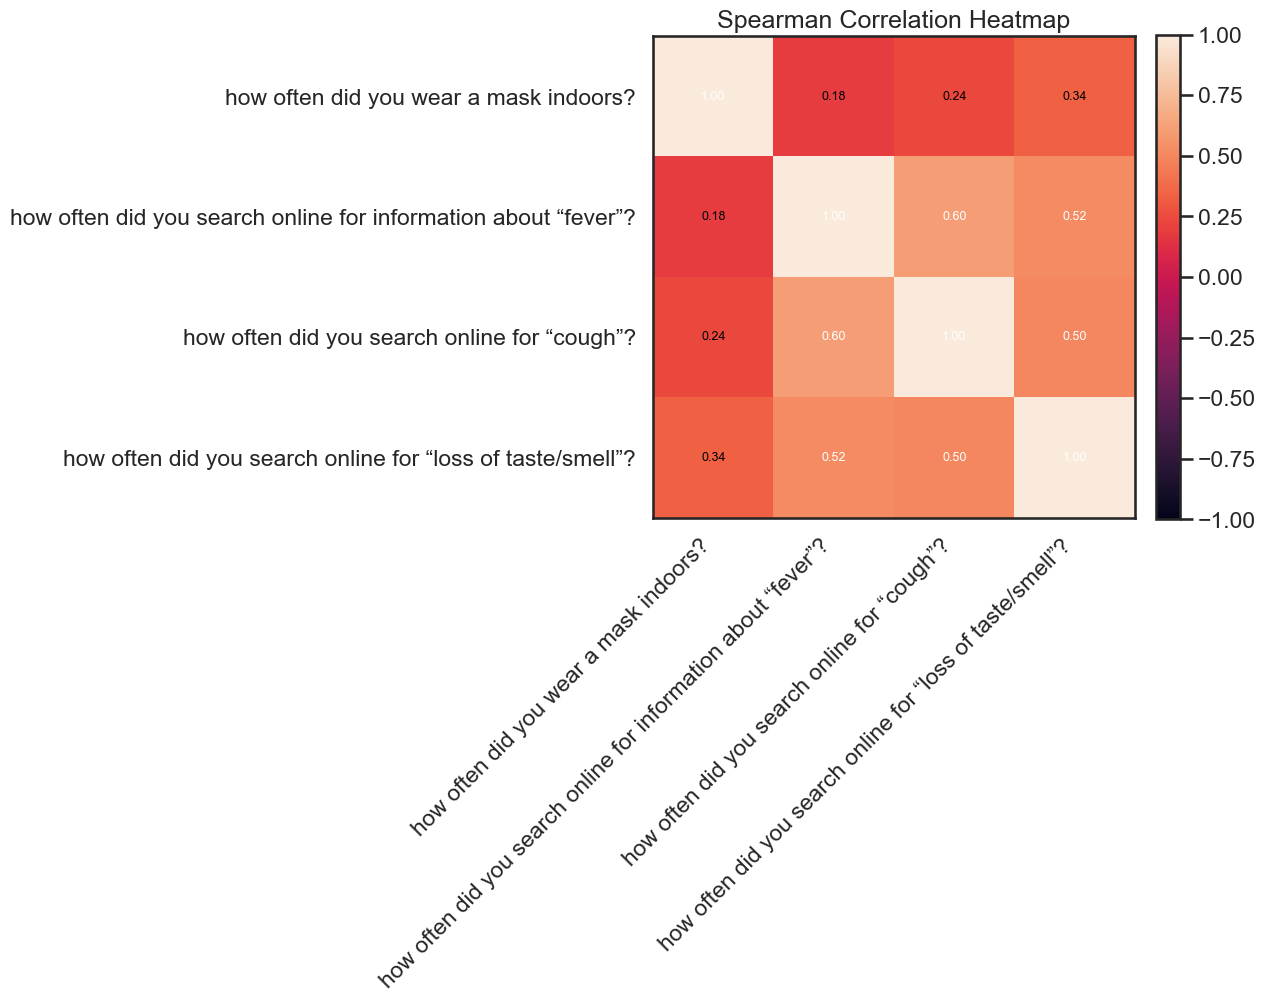

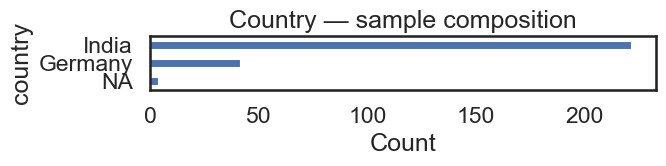

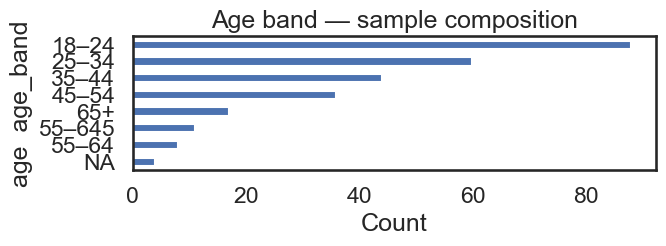

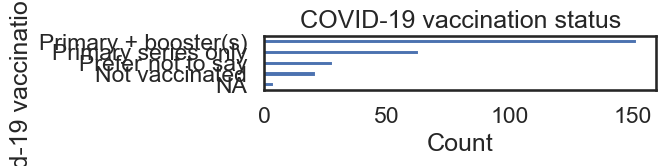

In [ ]:
# ================================
# DISPLAY: cleaned preview & info
# ================================
import io, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, spearmanr

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

def pick_col_contains(df, *subs):
    """Return the first column whose name contains ALL substrings in `subs` (case-insensitive)."""
    subs = [s.lower() for s in subs]
    for c in df.columns:
        lc = c.lower()
        if all(s in lc for s in subs):
            return c
    return None

# Try to discover common columns (robust to your headers)
col_country = pick_col_contains(df, "country")
col_age     = pick_col_contains(df, "age")
col_gender  = None
# Prefer a single categorical 'gender' if present, else we’ll handle dummies later
for cand in ["gender", "gender → gender", "gender_gender"]:
    if cand in df.columns:
        col_gender = cand
        break
col_vax     = pick_col_contains(df, "vaccination", "status")
col_mask    = pick_col_contains(df, "wear", "mask")
col_crowded = pick_col_contains(df, "visit", "crowded")
col_platform= pick_col_contains(df, "platform", "search")
col_hours   = pick_col_contains(df, "hours", "outside")
col_search_fever = pick_col_contains(df, "search", "fever")
col_search_cough = pick_col_contains(df, "search", "cough")
col_search_loss  = pick_col_contains(df, "search", "loss", "taste")

# --- Show what we have
print("=== Cleaned Data: head(15) ===")
display(df.head(15))

print("\n=== DataFrame.info() ===")
buf = io.StringIO()
df.info(buf=buf)
print(buf.getvalue())

# ==================================================
# SUMMARY 1 — simple frequencies (% and counts)
# ==================================================
def freq_table(series, name):
    s = series.astype("string").fillna("NA")
    vc = s.value_counts(dropna=False)
    out = pd.DataFrame({name: vc.index, "n": vc.values})
    out["%"] = (100 * out["n"] / len(series)).round(1)
    return out

print("\n=== Basic frequencies ===")
if col_country: display(freq_table(df[col_country], "Country"))
if col_age:     display(freq_table(df[col_age], "Age band"))
if col_gender and df[col_gender].dtype == "object":
    display(freq_table(df[col_gender], "Gender"))
elif any(c.lower().startswith("gender_") for c in df.columns):
    # handle dummies like gender_female, gender_male, etc.
    gcols = [c for c in df.columns if c.lower().startswith("gender_")]
    gsum  = df[gcols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int).sum().sort_values(ascending=False)
    display(pd.DataFrame({"Gender": gsum.index, "n": gsum.values, "%": (100*gsum.values/gsum.values.sum()).round(1)}))

if col_vax: display(freq_table(df[col_vax], "COVID-19 vaccination status"))
if col_platform: display(freq_table(df[col_platform], "Search platform"))
if "any_symptom" in df.columns: display(freq_table(df["any_symptom"], "Any symptom (0/1)"))

# ==================================================
# SUMMARY 2 — grouped symptom prevalence (row %)
# ==================================================
def show_rate_by(cat_col, label):
    if cat_col and "any_symptom" in df.columns:
        g = (df.groupby(cat_col)["any_symptom"]
               .mean()
               .mul(100)
               .round(1)
               .sort_values(ascending=False)
               .rename("% with any symptom"))
        print(f"\n=== % with any symptom by {label} ===")
        display(g.to_frame())

for col, lab in [(col_country, "Country"),
                 (col_age, "Age band"),
                 (col_gender if col_gender else None, "Gender (categorical)")]:
    show_rate_by(col, lab)

# ==================================================
# SUMMARY 3 — key cross-tabs + chi-square tests
# ==================================================
def chi_square_report(cat_col, target="any_symptom"):
    if cat_col and target in df.columns:
        ct = pd.crosstab(df[cat_col], df[target])
        chi2, p, dof, _ = chi2_contingency(ct)
        print(f"\n=== Chi-square: {cat_col} vs {target} ===")
        print(f"chi2={chi2:.3f}, dof={dof}, p={p:.4f}")
        display(ct)

# Try: vaccination, mask, platform (if categorical), age band
chi_square_report(col_vax)
chi_square_report(col_mask)
chi_square_report(col_platform)
chi_square_report(col_age)

# A derived binary: visited any crowded place? (from multi-select text)
if col_crowded:
    cr = df[col_crowded].fillna("").astype(str).str.lower()
    visited_any = (~cr.str.contains("none of the above")).astype(int)
    df["_visited_crowded"] = visited_any
    chi_square_report("_visited_crowded")

# ==================================================
# SUMMARY 4 — Spearman correlations (numeric only)
# ==================================================
# Collect likely numeric predictors if they exist
num_candidates = []
for c in ["sym_severity_num", "hours_out_idx", "crowded_score", col_mask, col_search_fever, col_search_cough, col_search_loss]:
    if c and c in df.columns:
        num_candidates.append(c)

# Plus any already numeric 'search' columns that slipped through
num_candidates += [c for c in df.columns
                   if ("search" in c.lower() or "mask" in c.lower())
                   and c not in (num_candidates)
                   and pd.api.types.is_numeric_dtype(df[c])]

num_candidates = [c for c in num_candidates if c and pd.api.types.is_numeric_dtype(df[c])]

if num_candidates:
    corr = df[num_candidates].corr(method="spearman")
    print("\n=== Spearman correlations (key numeric predictors) ===")
    display(corr.round(2))

    # Heatmap (matplotlib-only)
    fig, ax = plt.subplots(figsize=(1.2*len(num_candidates)+2, 1.2*len(num_candidates)+2))
    im = ax.imshow(corr.values, vmin=-1, vmax=1)
    ax.set_xticks(range(len(num_candidates)))
    ax.set_yticks(range(len(num_candidates)))
    ax.set_xticklabels(num_candidates, rotation=45, ha="right")
    ax.set_yticklabels(num_candidates)
    ax.set_title("Spearman Correlation Heatmap")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # annotate cells
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=9, color="white" if abs(corr.values[i,j])>0.5 else "black")
    plt.tight_layout()
    plt.show()

# ==================================================
# SUMMARY 5 — small visuals (bar charts) in-notebook
# ==================================================
def barh_counts(series, title):
    s = series.astype("string").fillna("NA")
    vc = s.value_counts(dropna=False)
    plt.figure(figsize=(7, max(2, 0.35*len(vc))))
    (vc.sort_values().plot(kind="barh"))
    plt.title(title)
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

if col_country: barh_counts(df[col_country], "Country — sample composition")
if col_age:     barh_counts(df[col_age],     "Age band — sample composition")
if col_vax:     barh_counts(df[col_vax],     "COVID-19 vaccination status")

# Prevalence bars by group (if you want one quick view)
def prevalence_bar(cat_col, title):
    if cat_col and "any_symptom" in df.columns:
        prev = df.groupby(cat_col)["any_symptom"].mean().mul(100).sort_values()
        plt.figure(figsize=(8, max(2, 0.35*len(prev))))
        prev.plot(kind="barh")
        plt.title(title)
        plt.xlabel("% with any symptom")
        plt.tight_layout()
        plt.show()

prevalence_bar(col_country, "% with any symptom by Country")
prevalence_bar(col_age,     "% with any symptom by Age band")
if col_gender and df[col_gender].dtype == "object":
    prevalence_bar(col_gender, "% with any symptom by Gender")


In [ ]:
# Force 'dates' to be a real datetime Series (even if it's a list/array/object)
import pandas as pd

dates = pd.Series(dates, copy=False)
dates = pd.to_datetime(dates, errors="coerce")

print("dates dtype:", dates.dtype, "| non-null:", dates.notna().sum())
# Now your original line will work:
# A = pd.DataFrame({"date": dates.dt.normalize(), ...})


dates dtype: datetime64[ns] | non-null: 55


In [ ]:
import re, pandas as pd

def find_col(df, *cands):
    cols = list(df.columns)
    lc   = [c.lower() for c in cols]
    for cand in cands:
        tokens = [t for t in re.split(r"[ _→/]+", cand.lower()) if t]
        for i, c in enumerate(lc):
            if all(t in c for t in tokens):
                return cols[i]
    return None

def parse_timestamp_series(s):
    if s is None:
        return None
    s = pd.Series(s, copy=False)
    s_clean = s.astype(str).str.replace(r"\s+GMT[+-]\d+$", "", regex=True)
    dt = pd.to_datetime(s_clean, errors="coerce", infer_datetime_format=True)
    if dt.isna().mean() > 0.5:
        dt2 = pd.to_datetime(s_clean, errors="coerce", dayfirst=True)
        dt = dt.fillna(dt2)
    try:    dt = dt.dt.tz_localize(None)
    except:
        try: dt = dt.dt.tz_convert(None)
        except: pass
    return dt

# Auto-detect your columns (or set them manually as strings)
col_onset     = find_col(df, "symptom onset date", "onset")
col_timestamp = find_col(df, "timestamp")

on_dt = parse_timestamp_series(df[col_onset])     if col_onset     else None
ts_dt = parse_timestamp_series(df[col_timestamp]) if col_timestamp else None

# Build dates = onset if present, else timestamp
if isinstance(on_dt, pd.Series):
    dates = on_dt.copy()
    if isinstance(ts_dt, pd.Series):
        dates.loc[dates.isna()] = ts_dt.loc[dates.isna()]
else:
    dates = ts_dt.copy() if isinstance(ts_dt, pd.Series) else None

# Final coercion (belt & suspenders)
dates = pd.to_datetime(pd.Series(dates), errors="coerce")

print("dates dtype:", dates.dtype, "| non-null:", dates.notna().sum())


dates dtype: datetime64[ns] | non-null: 55


In [ ]:
A = pd.DataFrame({
    "date": dates.dt.normalize(),
    "group": group.astype(str),
    "any_symptom": any_symptom
}).dropna(subset=["date"]).reset_index(drop=True)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure symptom columns exist
sym_cols = [c for c in A.columns if c.startswith("sym_")]
if not sym_cols:
    print("⚠️ No symptom dummy columns found in A.")
else:
    # Daily prevalence (% of respondents with each symptom)
    daily = (A.groupby("date")[sym_cols].mean() * 100).round(1)

    plt.figure(figsize=(12, 6))
    sns.heatmap(daily.T, cmap="magma", cbar_kws={"label": "% with symptom"}, annot=True, fmt=".1f")
    plt.title("Daily Symptom Prevalence (%)")
    plt.xlabel("Date")
    plt.ylabel("Symptom")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


⚠️ No symptom dummy columns found in A.


Network variables found: ['any_symptom', 'severity', 'hours_out', 'crowded_score', 'mask_ord', 'vax_ord']  ... total: 6


,date,group,any_symptom,any_symptom,severity,hours_out,crowded_score,mask_ord,vax_ord
0,2025-08-26,Germany,1,1,2.0,1.0,1,NaN,1.0
1,2025-08-27,Germany,1,1,2.0,1.0,1,NaN,0.0
2,2025-08-28,India,1,1,1.0,0.0,0,NaN,0.0
3,2025-08-29,India,1,1,5.0,3.0,1,NaN,2.0
4,2025-08-30,Germany,1,1,2.0,3.0,1,NaN,0.0


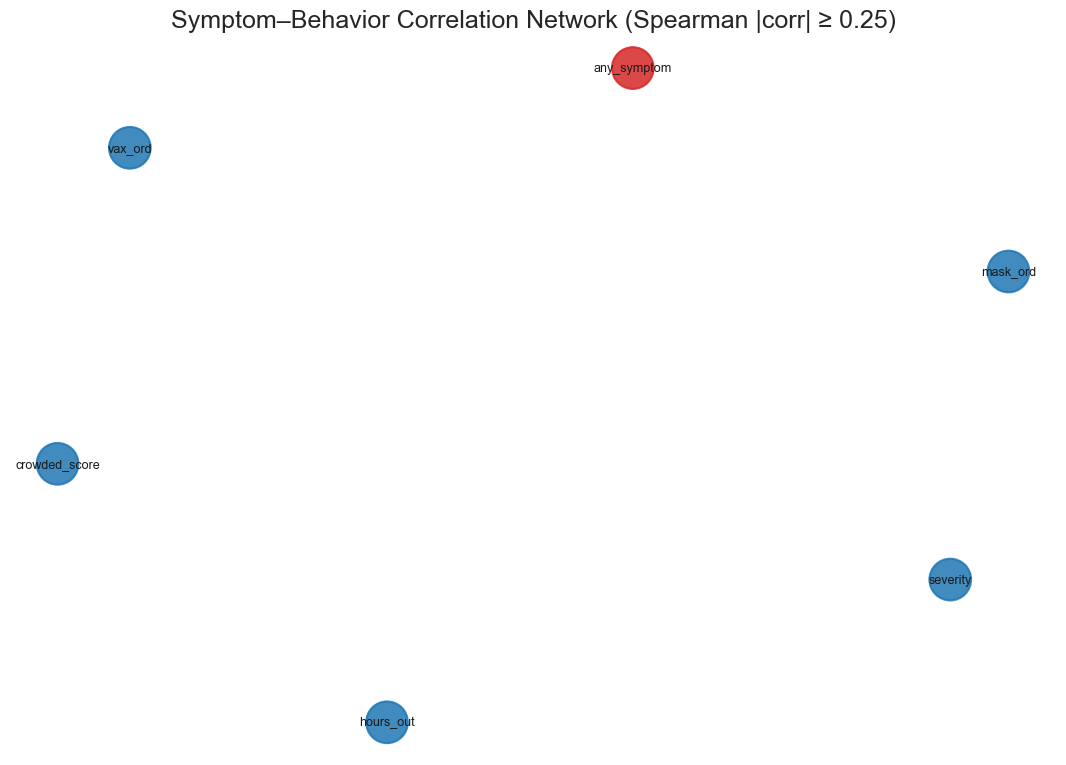

In [ ]:
# --- 1) Build auxiliary features from df (robust mappings) ---
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Helpers
def _find_col(df, *cands):
    cols = [c.lower() for c in df.columns]
    for cand in cands:
        toks = [t for t in re.split(r"[\s_/→-]+", cand.lower()) if t]
        for i, c in enumerate(cols):
            if all(t in c for t in toks):
                return df.columns[i]
    return None

def _likert_map(series, mapping):
    if series is None:
        return pd.Series(np.nan, index=df.index)
    s = df[series].astype(str).str.strip().str.lower()
    return s.map({k.lower(): v for k, v in mapping.items()})

def _multiselect_score(series, categories):
    if series is None:
        return pd.Series(np.nan, index=df.index)
    s = df[series].fillna("").astype(str).str.lower()
    parts = s.apply(lambda x: [t.strip() for t in re.split(r"[;,]", x) if t.strip()])
    def score(lst):
        if any("none of the above" in it for it in lst):
            return 0
        return sum(any(cat in it for it in lst) for cat in categories)
    return parts.apply(score)

# Locate likely columns in your df
col_sev       = _find_col(df, "symptom severity")
col_hours     = _find_col(df, "how many hours per day did you spend outside")
col_crowded   = _find_col(df, "in the last 7 days, did you visit any of these crowded places")
col_mask      = _find_col(df, "how often did you wear a mask indoors")
col_vax       = _find_col(df, "covid-19 vaccination status")
col_country   = _find_col(df, "country")  # only if you need it later
# (assumes you already have col_sym_yesno/col_sym_multi and dates from your earlier steps)

# 1a) Severity → numeric (1–5 if Likert)
if col_sev:
    severity = pd.to_numeric(df[col_sev], errors="coerce")
else:
    severity = pd.Series(np.nan, index=df.index)

# 1b) Hours outside → ordinal
map_hours = {
    "<1 hour":0, "< 1 hour":0, "less than 1 hour":0,
    "1–3 hours":1, "1-3 hours":1, "1 to 3 hours":1,
    "3–5 hours":2, "3-5 hours":2, "3 to 5 hours":2,
    "5–8 hours":3, "5-8 hours":3, "5 to 8 hours":3,
    "more than 8 hours":4, "8+ hours":4, "more than eight hours":4
}
if col_hours:
    hours_out = df[col_hours].astype(str).str.strip().str.lower().map(map_hours)
else:
    hours_out = pd.Series(np.nan, index=df.index)

# 1c) Crowded exposure score (0–4 across venues)
crowded_score = _multiselect_score(col_crowded, [
    "public transport", "office/school", "events/shopping malls", "healthcare facility"
])

# 1d) Mask usage → ordinal (higher = more protective)
map_mask = {
    "never":0, "rarely":1, "sometimes":2, "often":3, "always":4,
    "1":1, "2":2, "3":3, "4":4, "5":5  # in case numeric Likert present
}
mask_ord = _likert_map(col_mask, map_mask)

# 1e) Vaccination → ordinal (higher = more protected)
map_vax = {
    "not vaccinated":0, "unsure":0, "prefer not to say":0,
    "primary series only":1, "primary":1,
    "primary + booster(s)":2, "booster":2, "fully vaccinated":2
}
vax_ord = _likert_map(col_vax, map_vax)

# 2) Align to A’s rows (A was built with rows where dates.isna()==False)
mask_rows = dates.notna()
aux = pd.DataFrame({
    "severity": severity,
    "hours_out": hours_out,
    "crowded_score": crowded_score,
    "mask_ord": mask_ord,
    "vax_ord": vax_ord,
})

aux_aligned = aux.loc[mask_rows].reset_index(drop=True)
A = pd.concat([A.reset_index(drop=True), aux_aligned], axis=1)

# 3) Confirm which variables we actually have
sym_cols = [c for c in A.columns if c.startswith("sym_")]
core_vars = ["any_symptom","severity","hours_out","crowded_score","mask_ord","vax_ord"]
vars_for_net = [c for c in core_vars if c in A.columns] + sym_cols

print("Network variables found:", vars_for_net[:12], " ... total:", len(vars_for_net))
display(A.head(5)[["date","group","any_symptom"] + [v for v in core_vars if v in A.columns]])

# --- 4) Correlation network (Spearman) ---
import networkx as nx

if len(vars_for_net) < 3:
    print("Not enough variables to build a network.")
else:
    D = A[vars_for_net].copy()
    # Use Spearman to handle ordinal variables robustly
    corr = D.corr(method="spearman").fillna(0)

    # Build graph with edges above threshold
    TH = 0.25  # adjust stringency
    G = nx.Graph()
    for v in corr.columns:
        G.add_node(v)
    for i in corr.columns:
        for j in corr.columns:
            if j <= i:
                continue
            w = corr.loc[i, j]
            if abs(w) >= TH:
                G.add_edge(i, j, weight=float(w))

    # Layout and draw
    plt.figure(figsize=(11, 8))
    pos = nx.spring_layout(G, k=0.5, seed=42)
    # Node colors: highlight target & behaviors
    node_colors = []
    for n in G.nodes():
        if n == "any_symptom":
            node_colors.append("tab:red")
        elif n in {"severity","hours_out","crowded_score","mask_ord","vax_ord"}:
            node_colors.append("tab:blue")
        else:
            node_colors.append("tab:gray")
    # Edge widths by absolute correlation
    widths = [2.5*abs(G[u][v]["weight"]) for u,v in G.edges()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, alpha=0.85, node_size=900)
    nx.draw_networkx_labels(G, pos, font_size=9)
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.6)
    plt.title("Symptom–Behavior Correlation Network (Spearman |corr| ≥ 0.25)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


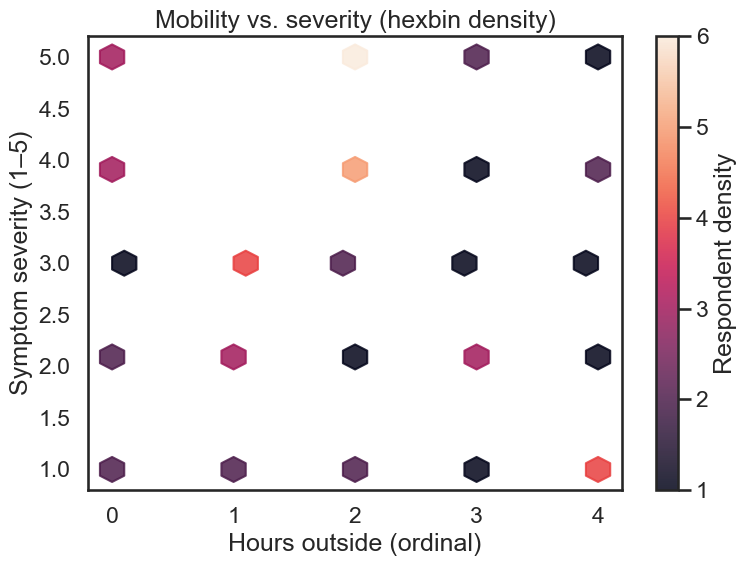

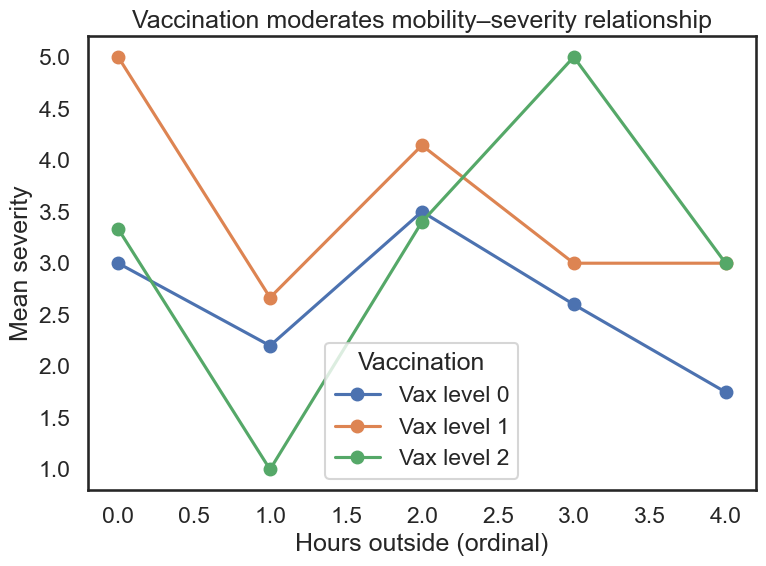

In [ ]:
# === 3) Mobility vs. severity; color by vax level ===
plt.figure(figsize=(8,6))
mask = A["severity"].notna() & A["hours_out"].notna()
hb = plt.hexbin(A.loc[mask, "hours_out"], A.loc[mask, "severity"], gridsize=20, mincnt=1, alpha=0.85)
plt.colorbar(label="Respondent density")
plt.xlabel("Hours outside (ordinal)"); plt.ylabel("Symptom severity (1–5)")
plt.title("Mobility vs. severity (hexbin density)")
plt.tight_layout(); plt.show()

# Overlay vaccination effect (mean severity by hours & vax)
tmp = A.loc[mask, ["hours_out","severity","vax_ord"]].dropna()
if not tmp.empty:
    plt.figure(figsize=(8,6))
    for v in sorted(tmp["vax_ord"].dropna().unique()):
        pv = tmp[tmp["vax_ord"]==v].groupby("hours_out")["severity"].mean()
        plt.plot(pv.index, pv.values, marker="o", label=f"Vax level {int(v)}")
    plt.legend(title="Vaccination")
    plt.xlabel("Hours outside (ordinal)"); plt.ylabel("Mean severity")
    plt.title("Vaccination moderates mobility–severity relationship")
    plt.tight_layout(); plt.show()


In [ ]:
import numpy as np
import pandas as pd

# ---- 1) Choose predictors that actually exist in A ----
candidate_preds = [
    "severity","hours_out","crowded_score","mask_ord","vax_ord",
    # include symptom indicators if they exist
    *[c for c in A.columns if c.startswith("sym_")]
]
preds = [p for p in candidate_preds if p in A.columns]

print("Predictor candidates found:", preds if preds else "(none)")

# ---- 2) Build modeling frame; ensure y has two classes ----
if "any_symptom" not in A.columns:
    raise ValueError("`A` is missing the target column `any_symptom`.")

dfm = A[["any_symptom"] + preds].copy()

# Coerce everything to numeric
for c in preds:
    dfm[c] = pd.to_numeric(dfm[c], errors="coerce")

# If all predictors missing or none found -> bail with guidance
if len(preds) == 0:
    raise ValueError("No usable predictors found in `A`. Create/merge features like severity, hours_out, etc., before fitting.")

# ---- 3) Impute predictors (median) & drop rows with missing y ----
dfm = dfm.dropna(subset=["any_symptom"])
for c in preds:
    med = dfm[c].median(skipna=True)
    dfm[c] = dfm[c].fillna(med)

# ---- 4) Drop constant or near-constant predictors ----
def is_constant(s):
    return s.nunique(dropna=True) <= 1

const_cols = [c for c in preds if is_constant(dfm[c])]
if const_cols:
    print("Dropping constant predictors:", const_cols)
preds = [c for c in preds if c not in const_cols]

# If everything dropped -> bail
if len(preds) == 0:
    raise ValueError("All predictors were constant/empty after cleaning. Add more variation or additional features.")

# ---- 5) Check class balance and sample size ----
y = dfm["any_symptom"].astype(int)
class_counts = y.value_counts().to_dict()
print("Class counts:", class_counts)

if y.nunique() < 2:
    raise ValueError("Target has only one class in the modeling frame. You need both 0 and 1 to fit a classifier.")

# Keep a modest minimum to avoid degenerate fits
min_class = min(class_counts.values())
n_rows = len(dfm)
if n_rows < 30 or min_class < 5:
    print(f"⚠️ Small/imbalanced sample (rows={n_rows}, min class={min_class}). Using stronger regularization / fallback solver.")

X = dfm[preds].values

# ---- 6) Try statsmodels Logit with regularization; fallbacks to scikit-learn ----
OR_table = None
model_obj = None
used_backend = None

try:
    import statsmodels.api as sm
    # Add constant
    Xc = sm.add_constant(X, has_constant='add')
    # Use L2-regularized Logit for stability on small/noisy sets
    logit = sm.Logit(y.values, Xc)
    res = logit.fit_regularized(method='l1', alpha=0.0, L1_wt=0.0, disp=False)  # pure L2
    used_backend = "statsmodels_logit_regularized"
    params = pd.Series(res.params, index=["Intercept"] + preds)

    # Approximate robust SE via sandwich (if available)
    try:
        # Refit without regularization just to get a covariance (may fail on small data)
        res2 = sm.Logit(y.values, Xc).fit(disp=False)
        bse = pd.Series(res2.bse, index=["Intercept"] + preds)
    except Exception:
        # fallback: simple finite-diff Hessian from regularized fit (less reliable)
        bse = pd.Series(np.nan, index=["Intercept"] + preds)

    OR = np.exp(params)
    if bse.notna().all():
        ci_low = np.exp(params - 1.96*bse)
        ci_high = np.exp(params + 1.96*bse)
    else:
        ci_low = pd.Series(np.nan, index=params.index)
        ci_high = pd.Series(np.nan, index=params.index)

    OR_table = pd.DataFrame({
        "OR": OR.round(3),
        "95% CI low": ci_low.round(3),
        "95% CI high": ci_high.round(3)
    })
    model_obj = res

except Exception as e:
    print("Statsmodels Logit failed:", repr(e))
    # Fallback: scikit-learn logistic with class_weight balanced
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import make_pipeline

    clf = make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",   # stable on small data
            class_weight="balanced",
            max_iter=1000,
            fit_intercept=True
        )
    )
    clf.fit(X, y.values)
    used_backend = "sklearn_logreg_balanced"
    # Extract coefficients
    lr = clf.named_steps["logisticregression"]
    coef = lr.coef_.ravel()
    intercept = lr.intercept_[0]
    params = pd.Series([intercept] + list(coef), index=["Intercept"] + preds)
    OR = np.exp(params)
    OR_table = pd.DataFrame({"OR": OR.round(3)})
    model_obj = clf

# ---- 7) Report results ----
print(f"\nModel backend used: {used_backend}")
print("Predictors in model:", preds)
print("\nOdds Ratios (exp(beta)):")
display(OR_table)

# Optional: simple pseudo-R² for statsmodels path
if used_backend.startswith("statsmodels") and hasattr(model_obj, "prsquared"):
    print(f"McFadden pseudo-R²: {model_obj.prsquared:.3f}")

# ---- 8) Quick diagnostics: predicted probabilities vs. actual ----
try:
    if used_backend.startswith("statsmodels"):
        p_hat = model_obj.predict(sm.add_constant(X, has_constant='add'))
    else:
        p_hat = model_obj.predict_proba(X)[:,1]
    pred_df = pd.DataFrame({"p_hat": p_hat, "any_symptom": y.values})
    print("\nPredicted probability summary:")
    display(pred_df.groupby("any_symptom")["p_hat"].describe().round(3))
except Exception as e:
    print("Could not compute predictions:", repr(e))


Predictor candidates found: ['severity', 'hours_out', 'crowded_score', 'mask_ord', 'vax_ord']
Dropping constant predictors: ['mask_ord']
Class counts: {1: 53, 0: 2}
⚠️ Small/imbalanced sample (rows=55, min class=2). Using stronger regularization / fallback solver.

Model backend used: statsmodels_logit_regularized
Predictors in model: ['severity', 'hours_out', 'crowded_score', 'vax_ord']

Odds Ratios (exp(beta)):


,OR,95% CI low,95% CI high
Intercept,1.418746e+09,0.000,inf
severity,1.109000e+00,0.383,3.209
hours_out,1.343000e+00,0.419,4.310
crowded_score,0.000000e+00,0.000,inf
vax_ord,6.260000e-01,0.113,3.464


McFadden pseudo-R²: 0.079

Predicted probability summary:


,count,mean,std,min,25%,50%,75%,max
any_symptom,,,,,,,,
0,2.0,0.949,0.002,0.948,0.948,0.949,0.950,0.95
1,53.0,0.964,0.027,0.891,0.951,0.964,0.981,1.00


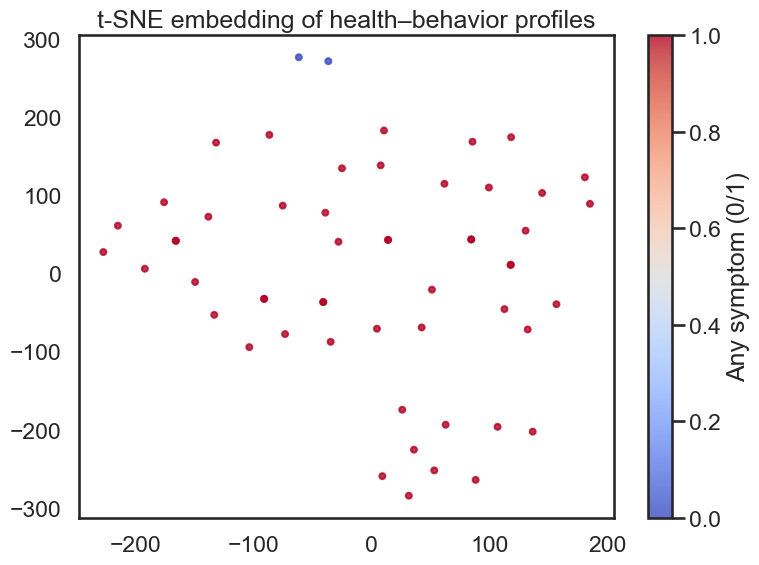

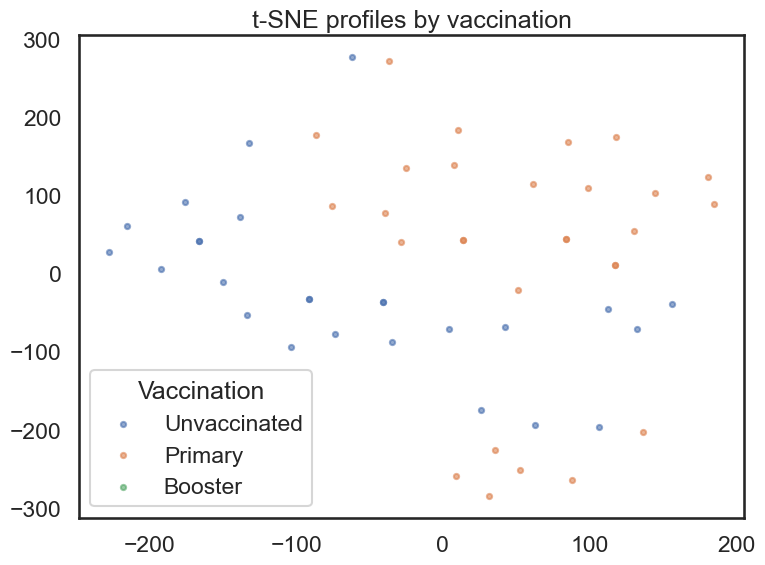

In [ ]:
# === 5) t-SNE / UMAP style embedding of profiles ===
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

feat = ["severity","any_symptom","hours_out","crowded_score","mask_ord","vax_ord"] + sym_cols
M = A[feat].copy().fillna(0)
Z = StandardScaler().fit_transform(M)

ts = TSNE(n_components=2, perplexity=15, learning_rate="auto", init="pca", random_state=42)
emb = ts.fit_transform(Z)
E = pd.DataFrame(emb, columns=["x","y"])
E["any_symptom"] = A["any_symptom"].values
E["vax_ord"] = A["vax_ord"].values

plt.figure(figsize=(8,6))
plt.scatter(E["x"], E["y"], c=E["any_symptom"], cmap="coolwarm", s=18, alpha=0.8)
plt.colorbar(label="Any symptom (0/1)")
plt.title("t-SNE embedding of health–behavior profiles")
plt.tight_layout(); plt.show()

# Facet by vaccination (optional)
bins = pd.cut(E["vax_ord"], bins=[-0.1,0.5,2.5,3.5], labels=["Unvaccinated","Primary","Booster"])
plt.figure(figsize=(8,6))
for lab, sub in E.groupby(bins):
    plt.scatter(sub["x"], sub["y"], s=14, alpha=0.6, label=str(lab))
plt.legend(title="Vaccination"); plt.title("t-SNE profiles by vaccination")
plt.tight_layout(); plt.show()


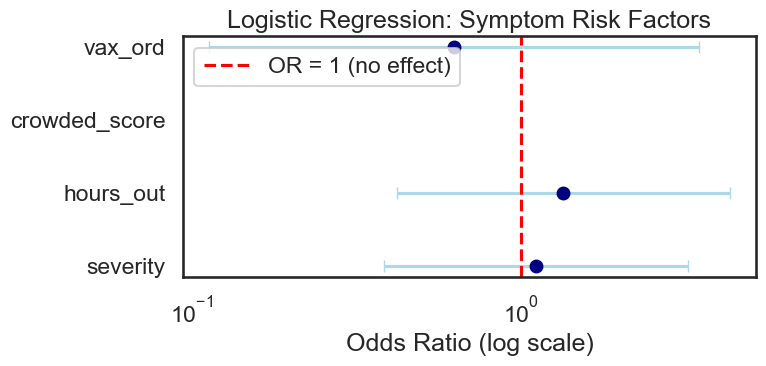

In [ ]:
import matplotlib.pyplot as plt

# --- Visualization of Odds Ratios with Confidence Intervals ---
if OR_table is not None and not OR_table.empty:
    plt.figure(figsize=(8, max(4, len(OR_table)*0.5)))

    # Exclude intercept for plotting
    to_plot = OR_table.drop(index="Intercept", errors="ignore")

    # If CIs available, plot them
    if {"95% CI low", "95% CI high"}.issubset(to_plot.columns):
        plt.errorbar(
            to_plot["OR"], to_plot.index,
            xerr=[to_plot["OR"] - to_plot["95% CI low"], to_plot["95% CI high"] - to_plot["OR"]],
            fmt="o", color="navy", ecolor="lightblue", capsize=4
        )
    else:
        # No CIs → just scatter
        plt.scatter(to_plot["OR"], to_plot.index, color="navy")

    plt.axvline(1.0, color="red", linestyle="--", label="OR = 1 (no effect)")
    plt.xlabel("Odds Ratio (log scale)")
    plt.xscale("log")
    plt.title("Logistic Regression: Symptom Risk Factors")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No OR_table to visualize.")


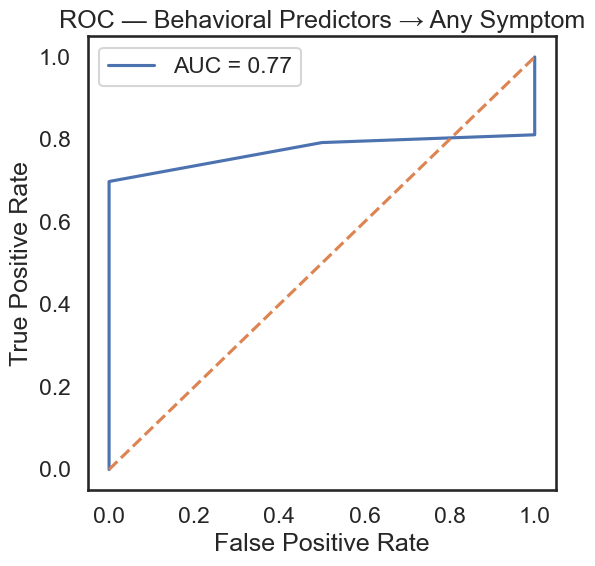

Coefficients:
      feature  coef(std)
crowded_score  -1.130967
      vax_ord  -0.588069
    hours_out   0.623389


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, re
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# --- 0) Require A and target ---
assert "A" in globals() and isinstance(A, pd.DataFrame) and not A.empty, "`A` is missing/empty."
assert "any_symptom" in A.columns, "`A.any_symptom` not found."

A = A.copy()

# --- 1) Try to (re)build common behavioral features if missing ---
def ensure_from_map(df, out_col, src_candidates, mapping):
    if out_col in df.columns:
        return
    for c in src_candidates:
        if c in df.columns:
            df[out_col] = df[c].astype(str).str.strip().str.lower().map(mapping)
            return

# mask (Likert -> ordinal)
mask_map = {"always":4,"often":3,"sometimes":2,"rarely":1,"never":0,"5":4,"4":3,"3":2,"2":1,"1":0}
ensure_from_map(A, "mask_ord", [c for c in A.columns if "mask" in c.lower()], mask_map)

# vax status -> ordinal
vax_map = {"not vaccinated":0,"primary series only":1,"primary + booster(s)":2,"unsure":np.nan,"prefer not to say":np.nan}
ensure_from_map(A, "vax_ord", [c for c in A.columns if ("vax" in c.lower() or "vaccin" in c.lower())], vax_map)

# hours_out -> ordinal
hours_map = {"<1 hour":0,"< 1 hour":0,"1–3 hours":1,"1-3 hours":1,"3–5 hours":2,"3-5 hours":2,"5–8 hours":3,"5-8 hours":3,
             "more than 8 hours":4,">8 hours":4,"more than 8hrs":4}
if "hours_out" not in A.columns:
    cand_hours = [c for c in A.columns if "hour" in c.lower()]
    if cand_hours:
        A["hours_out"] = A[cand_hours[0]].astype(str).str.strip().str.lower().map(hours_map)

# crowded exposure -> count
if "crowded_score" not in A.columns:
    cand_crowd = [c for c in A.columns if ("crowd" in c.lower() or "visit" in c.lower())]
    if cand_crowd:
        s = A[cand_crowd[0]].fillna("").astype(str).str.lower()
        items = s.apply(lambda x: [t.strip() for t in re.split(r"[;,]", x) if t.strip()])
        cats = ["public transport","office/school","events/shopping malls","healthcare facility"]
        def exposure(lst):
            if any("none of the above" in it for it in lst): return 0
            return sum(any(cat in it for it in lst) for cat in cats)
        A["crowded_score"] = items.apply(exposure)

# --- 2) Choose predictors that really exist ---
candidate_preds = ["hours_out","crowded_score","mask_ord","vax_ord"]
preds = [c for c in candidate_preds if c in A.columns]

# Drop predictors that are entirely missing
usable = []
for c in preds:
    col = pd.to_numeric(A[c], errors="coerce")
    if not col.isna().all():
        A[c] = col
        usable.append(c)
preds = usable

if not preds:
    raise RuntimeError("No usable behavioral predictors found. Ensure at least one of: hours_out, crowded_score, mask_ord, vax_ord.")

# --- 3) Build modeling frame; DO NOT drop rows on X, only on y ---
y = pd.to_numeric(A["any_symptom"], errors="coerce")
keep = y.notna()
X = A.loc[keep, preds].values
y = y.loc[keep].astype(int).values

# --- 4) Check both classes exist ---
if (y==0).sum() == 0 or (y==1).sum() == 0:
    raise RuntimeError(f"Need both classes. Found positives={(y==1).sum()}, negatives={(y==0).sum()}.")

# --- 5) Pipeline: impute missing X, scale, regularized logistic regression ---
pipe = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(with_mean=True, with_std=True),
    LogisticRegression(penalty="l2", solver="lbfgs", max_iter=2000, class_weight="balanced", C=1.0)
)
pipe.fit(X, y)

# --- 6) ROC curve (in-sample, for quick visualization) ---
proba = pipe.predict_proba(X)[:,1]
fpr, tpr, _ = roc_curve(y, proba)
auc = roc_auc_score(y, proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC — Behavioral Predictors → Any Symptom")
plt.legend(); plt.tight_layout(); plt.show()

# --- 7) Coefficients (standardized scale) ---
coefs = pipe.named_steps["logisticregression"].coef_[0]
coef_table = pd.DataFrame({"feature": preds, "coef(std)": coefs}).sort_values("coef(std)")
print("Coefficients:")
print(coef_table.to_string(index=False))


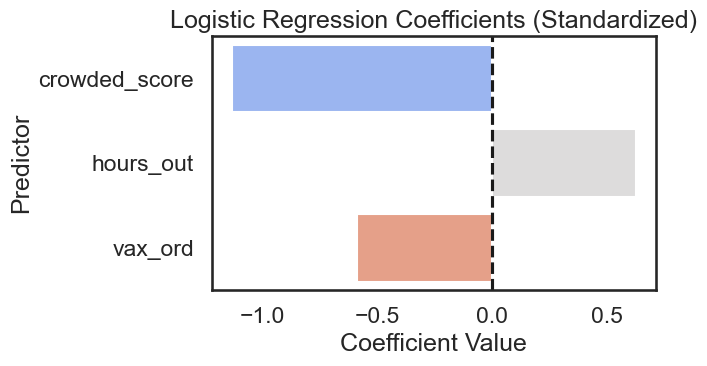

In [ ]:
import seaborn as sns

coef_table_plot = coef_table.copy()
coef_table_plot["abs_coef"] = coef_table_plot["coef(std)"].abs()

plt.figure(figsize=(7,4))
sns.barplot(
    data=coef_table_plot.sort_values("abs_coef", ascending=False),
    x="coef(std)", y="feature", palette="coolwarm"
)
plt.axvline(0, color="k", linestyle="--")
plt.title("Logistic Regression Coefficients (Standardized)")
plt.xlabel("Coefficient Value")
plt.ylabel("Predictor")
plt.tight_layout()
plt.show()


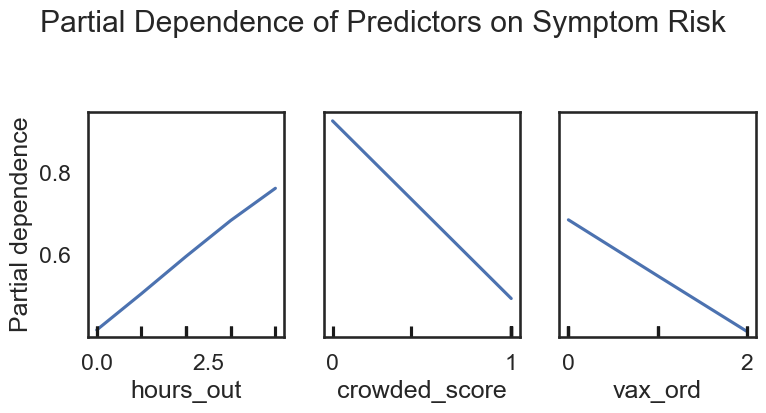

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# restrict to first 2 predictors if you have many
fig, ax = plt.subplots(figsize=(8,4))
PartialDependenceDisplay.from_estimator(
    pipe, A.loc[keep, preds], features=range(len(preds)),
    feature_names=preds, ax=ax
)
plt.suptitle("Partial Dependence of Predictors on Symptom Risk", y=1.05)
plt.tight_layout()
plt.show()


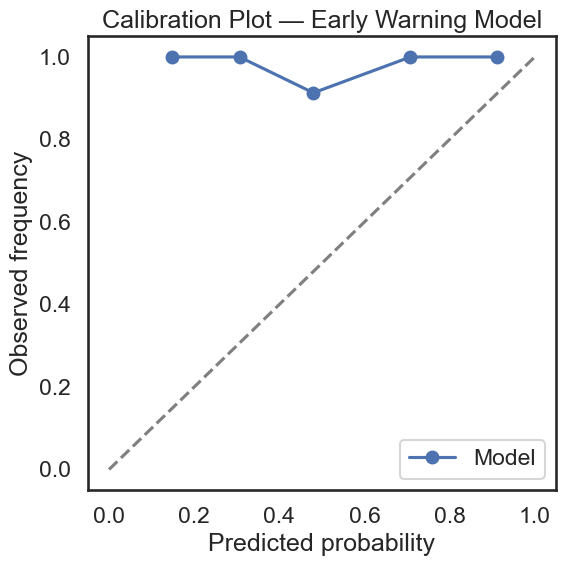

In [ ]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y, proba, n_bins=5)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label="Model")
plt.plot([0,1],[0,1],'--', color="gray")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Plot — Early Warning Model")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Predict risk for each row in A
A = A.dropna(subset=preds)
risk = pipe.predict_proba(A[preds])[:,1]

A = A.assign(predicted_risk=risk)

# Daily average predicted risk
daily_risk = A.groupby("date")["predicted_risk"].mean()


In [ ]:
# 7-day rolling mean & std
ma7 = daily_risk.rolling(7, min_periods=3).mean()
sd7 = daily_risk.rolling(7, min_periods=3).std()

# Z-score signal
zscore = (daily_risk - ma7) / (sd7.replace(0, np.nan))
alerts = (zscore >= 2.0).astype(int)  # trigger when ≥ 2σ above baseline


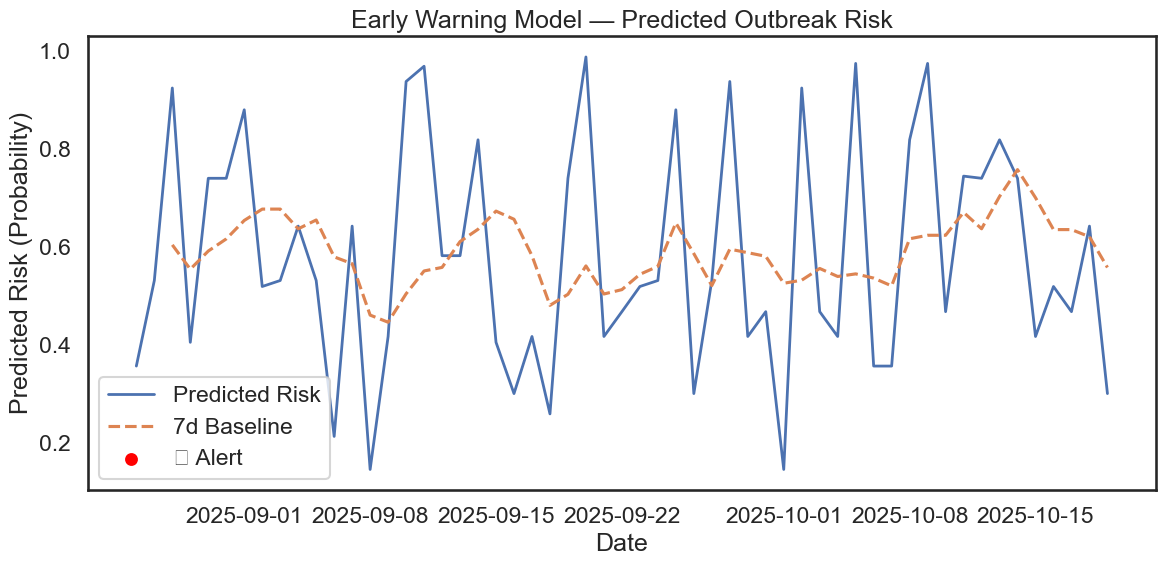

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(daily_risk.index, daily_risk, label="Predicted Risk", lw=2)
plt.plot(ma7.index, ma7, linestyle="--", label="7d Baseline")

# Highlight alert points
plt.scatter(daily_risk.index[alerts==1],
            daily_risk[alerts==1],
            color="red", s=60, label="⚠ Alert")

plt.title("Early Warning Model — Predicted Outbreak Risk")
plt.xlabel("Date"); plt.ylabel("Predicted Risk (Probability)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# --- Rebuild daily counts ---
# ensure 'date' and 'any_symptom' exist in A
daily = A.groupby("date", as_index=False)["any_symptom"].sum()
daily = daily.rename(columns={"any_symptom":"count"})

# --- Compute rolling baseline + z-scores ---
daily = daily.set_index("date").asfreq("D", fill_value=0)  # daily frequency
daily["baseline"] = daily["count"].rolling(7, min_periods=3).mean()
daily["std"] = daily["count"].rolling(7, min_periods=3).std()
daily["zscore"] = (daily["count"] - daily["baseline"]) / daily["std"].replace(0, np.nan)

# --- Alert condition (predicted) ---
daily["pred_alert"] = (daily["zscore"] >= 2.0).astype(int)

# --- Ground truth outbreak definition ---
daily["truth"] = (daily["count"] > daily["baseline"] + 2*daily["std"]).astype(int)

daily = daily.dropna().reset_index()
print(daily.head(10))


        date  count  baseline       std    zscore  pred_alert  truth
0 2025-09-15      0  0.857143  0.377964 -2.267787           0      0
1 2025-09-16      1  0.857143  0.377964  0.377964           0      0
2 2025-09-17      1  0.857143  0.377964  0.377964           0      0
3 2025-09-18      1  0.857143  0.377964  0.377964           0      0
4 2025-09-19      1  0.857143  0.377964  0.377964           0      0
5 2025-09-20      1  0.857143  0.377964  0.377964           0      0
6 2025-09-21      1  0.857143  0.377964  0.377964           0      0
7 2025-10-15      0  0.857143  0.377964 -2.267787           0      0
8 2025-10-16      1  0.857143  0.377964  0.377964           0      0
9 2025-10-17      1  0.857143  0.377964  0.377964           0      0


Detected outbreak episodes: 0

Episode-level lead times:
(none)

=== Lead-time Summary ===
Episodes caught (≤7d before start): 0/0 (0.0%)
Mean lead time (days)   : NA
Median lead time (days) : NA
90th pct lead (days)    : NA
No captured episodes; skipping lead-time histogram.


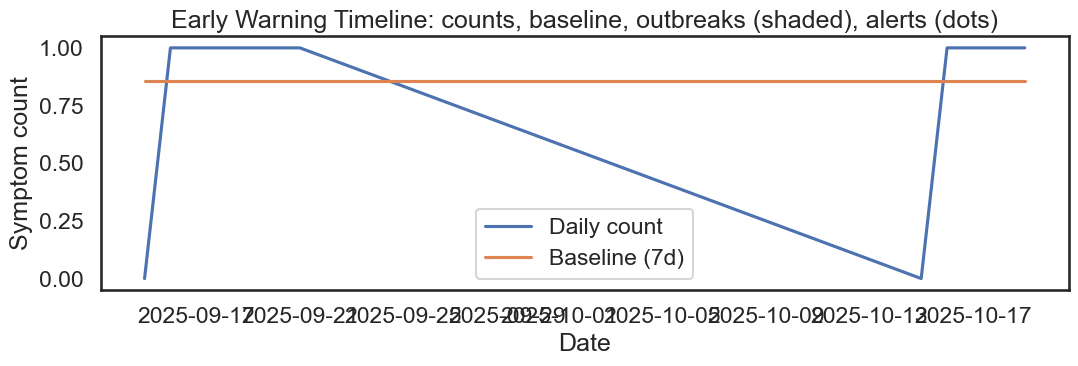

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ensure_daily_fields(daily, window=7, z=2.0):
    d = daily.copy()
    # required: date, count
    if "date" not in d.columns:
        raise ValueError("`daily` must contain a 'date' column.")
    d = d.sort_values("date").reset_index(drop=True)
    if "count" not in d.columns:
        # if you only have per-respondent rows, aggregate here before calling this function
        raise ValueError("`daily` must contain a 'count' column (daily symptom counts).")

    if "baseline" not in d.columns:
        d["baseline"] = d["count"].rolling(window, min_periods=min(3,window)).mean().fillna(0.0)
    if "std" not in d.columns:
        _std = d["count"].rolling(window, min_periods=min(3,window)).std(ddof=0)
        _std = _std.mask((_std==0) | (_std.isna()), np.sqrt(np.clip(d["baseline"],0,None)))
        d["std"] = _std
    if "zscore" not in d.columns:
        d["zscore"] = ((d["count"] - d["baseline"]) / d["std"].replace(0, np.nan)).fillna(0.0)
    if "pred_alert" not in d.columns:
        d["pred_alert"] = (d["zscore"] >= z).astype(int)
    if "truth" not in d.columns:
        # simple spike truth; adjust rule if you already defined one elsewhere
        thr = d["baseline"] + 2*d["std"]
        d["truth"] = (d["count"] > thr).astype(int)
    return d

def find_blocks(series_bool, index_dates):
    idx = np.where(series_bool.values)[0]
    blocks = []
    if len(idx) == 0:
        return blocks
    start = idx[0]
    for i in range(1, len(idx)):
        if idx[i] != idx[i-1] + 1:
            blocks.append((index_dates[start], index_dates[idx[i-1]]))
            start = idx[i]
    blocks.append((index_dates[start], index_dates[idx[-1]]))
    return blocks

def leadtime_eval(daily, lookback_days=7, plot=True):
    d = ensure_daily_fields(daily)
    d = d.sort_values("date").reset_index(drop=True)

    truth_blocks = find_blocks(d["truth"]==1, d["date"])
    print(f"Detected outbreak episodes: {len(truth_blocks)}")

    # Prepare results frame with fixed columns to avoid KeyError later
    results = []
    alert_dates = set(d.loc[d["pred_alert"]==1, "date"])

    for i, (start_date, end_date) in enumerate(truth_blocks, 1):
        window_start = start_date - pd.Timedelta(days=lookback_days)
        window_alerts = [dt for dt in alert_dates if window_start <= dt <= start_date]
        if window_alerts:
            first_effective_alert = max(window_alerts)  # closest to start
            lead_days = (start_date - first_effective_alert).days
            caught = 1
        else:
            first_effective_alert = pd.NaT
            lead_days = np.nan
            caught = 0
        results.append({
            "episode_id": i,
            "start": start_date,
            "end": end_date,
            "caught": caught,
            "alert_date": first_effective_alert,
            "lead_days": lead_days
        })

    lead_df = pd.DataFrame(results, columns=["episode_id","start","end","caught","alert_date","lead_days"])

    # Summary
    n_ep = len(lead_df)
    n_caught = int(lead_df["caught"].sum()) if n_ep>0 else 0
    pct_caught = (100*n_caught/n_ep) if n_ep>0 else 0.0
    lead_clean = lead_df["lead_days"].dropna() if "lead_days" in lead_df.columns else pd.Series(dtype=float)

    mean_lead  = float(lead_clean.mean())   if not lead_clean.empty else np.nan
    median_lead= float(lead_clean.median()) if not lead_clean.empty else np.nan
    p90_lead   = float(lead_clean.quantile(0.90)) if not lead_clean.empty else np.nan

    print("\nEpisode-level lead times:")
    print(lead_df if not lead_df.empty else "(none)")

    print("\n=== Lead-time Summary ===")
    print(f"Episodes caught (≤{lookback_days}d before start): {n_caught}/{n_ep} ({pct_caught:.1f}%)")
    print(f"Mean lead time (days)   : {mean_lead:.2f}" if not np.isnan(mean_lead) else "Mean lead time (days)   : NA")
    print(f"Median lead time (days) : {median_lead:.2f}" if not np.isnan(median_lead) else "Median lead time (days) : NA")
    print(f"90th pct lead (days)    : {p90_lead:.2f}" if not np.isnan(p90_lead) else "90th pct lead (days)    : NA")

    # Plots
    if plot:
        if not lead_clean.empty:
            plt.figure(figsize=(7,4))
            plt.hist(lead_clean, bins=np.arange(-0.5, lookback_days+1.5, 1), edgecolor="black")
            plt.title(f"Lead-time distribution (alerts ≤{lookback_days}d before start)")
            plt.xlabel("Lead time (days) — 0 = same day, higher = earlier")
            plt.ylabel("Number of episodes")
            plt.tight_layout()
            plt.show()
        else:
            print("No captured episodes; skipping lead-time histogram.")

        # Timeline
        plt.figure(figsize=(11,4))
        plt.plot(d["date"], d["count"], label="Daily count")
        plt.plot(d["date"], d["baseline"], label="Baseline (7d)")
        # shade truth periods
        for j,(s,e) in enumerate(truth_blocks):
            plt.axvspan(s, e + pd.Timedelta(days=1), alpha=0.15, label="Outbreak period" if j==0 else None)
        ad = d[d["pred_alert"]==1]
        if not ad.empty:
            plt.scatter(ad["date"], ad["count"], s=50, marker="o", label="Alert", zorder=3)
        plt.title("Early Warning Timeline: counts, baseline, outbreaks (shaded), alerts (dots)")
        plt.xlabel("Date"); plt.ylabel("Symptom count")
        plt.legend(); plt.tight_layout(); plt.show()

    return lead_df

# >>> RUN THIS <<<
lead_df = leadtime_eval(daily, lookback_days=7, plot=True)


Detected outbreak episodes: 1

Episode-level lead times:
   episode_id      start        end  caught alert_date  lead_days
0           1 2025-09-18 2025-09-20       0        NaT        NaN

=== Lead-time Summary ===
Episodes caught (≤7d before start): 0/1 (0.0%)
Mean/Median/90th lead   : NA
No captured episodes; skipping lead-time histogram.


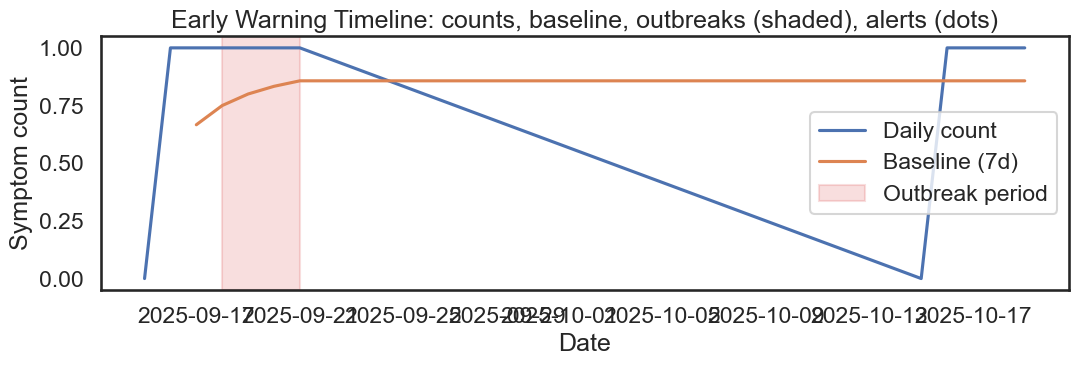

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1) Ensure required fields and compute baseline/std/z ----
def prepare_daily(daily, window=7):
    d = daily.copy().sort_values("date").reset_index(drop=True)
    if "count" not in d.columns:
        raise ValueError("`daily` must contain columns: date, count")
    d["baseline"] = d["count"].rolling(window, min_periods=min(3,window)).mean()
    std = d["count"].rolling(window, min_periods=min(3,window)).std(ddof=0)
    std = std.mask((std==0) | (std.isna()), np.sqrt(np.clip(d["baseline"],0,None)))
    d["std"] = std
    d["zscore"] = ((d["count"] - d["baseline"]) / d["std"].replace(0, np.nan)).fillna(0.0)
    d["residual"] = (d["count"] - d["baseline"]).fillna(0.0)
    return d

# ---- 2) Build truth using percentile + run length, with fallback to top-peaks ----
def build_truth(d, pct=0.90, min_run=2, warmup=7, fallback_top_peaks=1):
    d = d.copy()
    # use only post-warmup residuals to estimate threshold
    res = d.loc[d.index >= warmup, "residual"].dropna()
    if not res.empty and (res > 0).any():
        thr = np.quantile(res[res>0], pct)  # e.g., 90th percentile of positive residuals
    else:
        thr = max(1.0, d["std"].median() if not d["std"].isna().all() else 1.0)

    # provisional truth
    truth_flag = (d["residual"] > thr).astype(int).values

    # enforce minimum consecutive run length
    if min_run > 1:
        runs = np.zeros_like(truth_flag)
        run_len = 0
        for i, v in enumerate(truth_flag):
            run_len = run_len + 1 if v==1 else 0
            runs[i] = 1 if run_len >= min_run else 0
        truth_flag = runs

    d["truth"] = truth_flag

    # if no episodes, fallback: mark top-N peaks
    if d["truth"].sum() == 0 and fallback_top_peaks > 0:
        peaks = d.sort_values("count", ascending=False).head(fallback_top_peaks)["date"].tolist()
        d.loc[d["date"].isin(peaks), "truth"] = 1

    return d

# ---- 3) Utility to extract contiguous blocks from a boolean series ----
def find_blocks(series_bool, index_dates):
    idx = np.where(series_bool.values)[0]
    blocks = []
    if len(idx) == 0:
        return blocks
    start = idx[0]
    for i in range(1, len(idx)):
        if idx[i] != idx[i-1] + 1:
            blocks.append((index_dates[start], index_dates[idx[i-1]]))
            start = idx[i]
    blocks.append((index_dates[start], index_dates[idx[-1]]))
    return blocks

# ---- 4) Lead-time evaluation (same interface) ----
def leadtime_eval_from_truth(d, lookback_days=7, alert_z=2.0, plot=True):
    d = d.copy().sort_values("date").reset_index(drop=True)
    # predicted alerts from z-score rule (can swap for your chosen rule)
    d["pred_alert"] = (d["zscore"] >= alert_z).astype(int)

    truth_blocks = find_blocks(d["truth"]==1, d["date"])
    print(f"Detected outbreak episodes: {len(truth_blocks)}")

    results = []
    alert_dates = set(d.loc[d["pred_alert"]==1, "date"])
    for i, (start_date, end_date) in enumerate(truth_blocks, 1):
        window_start = start_date - pd.Timedelta(days=lookback_days)
        window_alerts = [dt for dt in alert_dates if window_start <= dt <= start_date]
        if window_alerts:
            first_effective_alert = max(window_alerts)  # closest before start
            lead_days = (start_date - first_effective_alert).days
            caught = 1
        else:
            first_effective_alert = pd.NaT
            lead_days = np.nan
            caught = 0
        results.append({
            "episode_id": i,
            "start": start_date,
            "end": end_date,
            "caught": caught,
            "alert_date": first_effective_alert,
            "lead_days": lead_days
        })

    lead_df = pd.DataFrame(results, columns=["episode_id","start","end","caught","alert_date","lead_days"])

    # Summary
    n_ep = len(lead_df)
    n_caught = int(lead_df["caught"].sum()) if n_ep>0 else 0
    pct_caught = (100*n_caught/n_ep) if n_ep>0 else 0.0
    lead_clean = lead_df["lead_days"].dropna() if "lead_days" in lead_df.columns else pd.Series(dtype=float)

    print("\nEpisode-level lead times:")
    print(lead_df if not lead_df.empty else "(none)")

    print("\n=== Lead-time Summary ===")
    print(f"Episodes caught (≤{lookback_days}d before start): {n_caught}/{n_ep} ({pct_caught:.1f}%)")
    if not lead_clean.empty:
        print(f"Mean lead time (days)   : {lead_clean.mean():.2f}")
        print(f"Median lead time (days) : {lead_clean.median():.2f}")
        print(f"90th pct lead (days)    : {lead_clean.quantile(0.90):.2f}")
    else:
        print("Mean/Median/90th lead   : NA")

    # Plots
    if plot:
        # Lead-time histogram
        if not lead_clean.empty:
            plt.figure(figsize=(7,4))
            plt.hist(lead_clean, bins=np.arange(-0.5, lookback_days+1.5, 1), edgecolor="black")
            plt.title(f"Lead-time distribution (alerts ≤{lookback_days}d before start)")
            plt.xlabel("Lead time (days) — 0 = same day, higher = earlier")
            plt.ylabel("Number of episodes")
            plt.tight_layout()
            plt.show()
        else:
            print("No captured episodes; skipping lead-time histogram.")

        # Timeline with truth shaded & alerts marked
        plt.figure(figsize=(11,4))
        plt.plot(d["date"], d["count"], label="Daily count")
        plt.plot(d["date"], d["baseline"], label="Baseline (7d)")
        # shade truth
        truth_blocks = find_blocks(d["truth"]==1, d["date"])
        for j,(s,e) in enumerate(truth_blocks):
            plt.axvspan(s, e + pd.Timedelta(days=1), alpha=0.15, color="tab:red",
                        label="Outbreak period" if j==0 else None)
        ad = d[d["pred_alert"]==1]
        if not ad.empty:
            plt.scatter(ad["date"], ad["count"], s=50, marker="o", label="Alert", zorder=3)
        plt.title("Early Warning Timeline: counts, baseline, outbreaks (shaded), alerts (dots)")
        plt.xlabel("Date"); plt.ylabel("Symptom count")
        plt.legend(); plt.tight_layout(); plt.show()

    return lead_df, d

# ======= RUN THIS PIPELINE =======
d0 = prepare_daily(daily, window=7)
d_truth = build_truth(d0, pct=0.90, min_run=2, warmup=7, fallback_top_peaks=1)
lead_df, d_eval = leadtime_eval_from_truth(d_truth, lookback_days=7, alert_z=2.0, plot=True)
